<a href="https://colab.research.google.com/github/jamalaiah/TEXT-SCI-/blob/main/Text_Recog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
import os

# Forcefully remove any existing contents in the mount point
if os.path.exists('/content/drive'):
    !rm -rf /content/drive/*

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [8]:
import os

zip_path = "/content/drive/MyDrive/Word_Level_Telugu_Test_Set.zip"

print("File exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    size_gb = os.path.getsize(zip_path) / (1024**3)
    print(f"ZIP size: {size_gb:.2f} GB")

File exists: True
ZIP size: 0.23 GB


In [9]:
# ============================================================
# 🔐 TELUGU HTR — PERSISTENT PROJECT STORAGE
# ============================================================

import os

PROJECT_ROOT = "/content/drive/MyDrive/Telugu_HTR_Research"

os.makedirs(PROJECT_ROOT, exist_ok=True)

print("=" * 70)
print("PERSISTENT STORAGE READY")
print("=" * 70)
print("Project folder :", PROJECT_ROOT)
print("Drive exists   :", os.path.exists("/content/drive/MyDrive"))
print("✓ Runtime-safe persistent storage configured")

PERSISTENT STORAGE READY
Project folder : /content/drive/MyDrive/Telugu_HTR_Research
Drive exists   : True
✓ Runtime-safe persistent storage configured


In [10]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.namelist()

print("Total files/folders:", len(files))

print("\nFirst 50 entries:")
for item in files[:50]:
    print(item)

Total files/folders: 9588

First 50 entries:
Word_Level_Test_Set/
Word_Level_Test_Set/image/
Word_Level_Test_Set/image/33686_17.jpg
Word_Level_Test_Set/image/179805_8.jpg
Word_Level_Test_Set/image/184382_1.jpg
Word_Level_Test_Set/image/27299_6.jpg
Word_Level_Test_Set/image/183554_1.jpg
Word_Level_Test_Set/image/180198_21.jpg
Word_Level_Test_Set/image/190787_3.jpg
Word_Level_Test_Set/image/33080_25.jpg
Word_Level_Test_Set/image/179432_13.jpg
Word_Level_Test_Set/image/16391_14.jpg
Word_Level_Test_Set/image/181663_35.jpg
Word_Level_Test_Set/image/181413_17.jpg
Word_Level_Test_Set/image/179172_3.jpg
Word_Level_Test_Set/image/179792_32.jpg
Word_Level_Test_Set/image/193379_9.jpg
Word_Level_Test_Set/image/36209_1.jpg
Word_Level_Test_Set/image/189247_18.jpg
Word_Level_Test_Set/image/180807_16.jpg
Word_Level_Test_Set/image/189186_11.jpg
Word_Level_Test_Set/image/191309_15.jpg
Word_Level_Test_Set/image/190967_18.jpg
Word_Level_Test_Set/image/179427_25.jpg
Word_Level_Test_Set/image/179680_17.jpg


In [11]:
from collections import Counter
import os

extensions = Counter()

for item in files:
    if not item.endswith("/"):
        ext = os.path.splitext(item)[1].lower()
        extensions[ext] += 1

print("File extensions:")
for ext, count in extensions.items():
    print(f"{ext or '[no extension]'} : {count}")

File extensions:
.jpg : 9585
.txt : 1


In [12]:
keywords = [
    "label",
    "annotation",
    "ground",
    "truth",
    "transcription",
    "text",
    "gt",
    "word"
]

matches = []

for item in files:
    lower = item.lower()
    if any(k in lower for k in keywords):
        matches.append(item)

print("Possible annotation/text-related files:")
for item in matches[:100]:
    print(item)

Possible annotation/text-related files:
Word_Level_Test_Set/
Word_Level_Test_Set/image/
Word_Level_Test_Set/image/33686_17.jpg
Word_Level_Test_Set/image/179805_8.jpg
Word_Level_Test_Set/image/184382_1.jpg
Word_Level_Test_Set/image/27299_6.jpg
Word_Level_Test_Set/image/183554_1.jpg
Word_Level_Test_Set/image/180198_21.jpg
Word_Level_Test_Set/image/190787_3.jpg
Word_Level_Test_Set/image/33080_25.jpg
Word_Level_Test_Set/image/179432_13.jpg
Word_Level_Test_Set/image/16391_14.jpg
Word_Level_Test_Set/image/181663_35.jpg
Word_Level_Test_Set/image/181413_17.jpg
Word_Level_Test_Set/image/179172_3.jpg
Word_Level_Test_Set/image/179792_32.jpg
Word_Level_Test_Set/image/193379_9.jpg
Word_Level_Test_Set/image/36209_1.jpg
Word_Level_Test_Set/image/189247_18.jpg
Word_Level_Test_Set/image/180807_16.jpg
Word_Level_Test_Set/image/189186_11.jpg
Word_Level_Test_Set/image/191309_15.jpg
Word_Level_Test_Set/image/190967_18.jpg
Word_Level_Test_Set/image/179427_25.jpg
Word_Level_Test_Set/image/179680_17.jpg
Word_

In [13]:
print("Top-level structure:\n")

top_level = set()

for item in files:
    parts = item.split("/")
    if parts:
        top_level.add(parts[0])

for folder in sorted(top_level):
    print(folder)

Top-level structure:

Word_Level_Test_Set


In [14]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    txt_files = [
        f for f in zip_ref.namelist()
        if f.lower().endswith('.txt')
    ]

print("TXT files found:")
for f in txt_files:
    print(f)

TXT files found:
Word_Level_Test_Set/test.txt


In [15]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    txt_name = txt_files[0]

    with zip_ref.open(txt_name) as f:
        content = f.read().decode('utf-8', errors='replace')

print("TXT file:", txt_name)
print("Characters:", len(content))

print("\n----- FIRST 30 LINES -----")
for i, line in enumerate(content.splitlines()[:30], 1):
    print(f"{i}: {line}")

TXT file: Word_Level_Test_Set/test.txt
Characters: 183494

----- FIRST 30 LINES -----
1: image/194193_1.jpg
2: image/194193_2.jpg
3: image/194193_3.jpg
4: image/194193_4.jpg
5: image/179832_1.jpg
6: image/179832_2.jpg
7: image/179832_3.jpg
8: image/179832_4.jpg
9: image/190025_1.jpg
10: image/190025_2.jpg
11: image/190025_3.jpg
12: image/190025_4.jpg
13: image/190025_5.jpg
14: image/190025_6.jpg
15: image/190025_7.jpg
16: image/190025_8.jpg
17: image/190025_9.jpg
18: image/190025_10.jpg
19: image/190025_11.jpg
20: image/190025_12.jpg
21: image/190025_13.jpg
22: image/190025_14.jpg
23: image/190025_15.jpg
24: image/190025_16.jpg
25: image/190025_17.jpg
26: image/190025_18.jpg
27: image/190025_19.jpg
28: image/190025_20.jpg
29: image/190025_21.jpg
30: image/190025_22.jpg


In [16]:
lines = content.splitlines()

print("Total lines:", len(lines))

print("\n----- LAST 30 LINES -----")
for i, line in enumerate(lines[-30:], len(lines)-29):
    print(f"{i}: {line}")

Total lines: 9585

----- LAST 30 LINES -----
9556: image/36905_13.jpg
9557: image/36905_14.jpg
9558: image/36905_15.jpg
9559: image/36905_16.jpg
9560: image/36905_17.jpg
9561: image/36905_18.jpg
9562: image/36905_19.jpg
9563: image/36905_20.jpg
9564: image/36905_21.jpg
9565: image/36905_22.jpg
9566: image/36905_23.jpg
9567: image/36905_24.jpg
9568: image/36905_25.jpg
9569: image/36905_26.jpg
9570: image/36905_27.jpg
9571: image/36905_28.jpg
9572: image/36905_29.jpg
9573: image/36905_30.jpg
9574: image/36905_31.jpg
9575: image/184315_1.jpg
9576: image/184315_2.jpg
9577: image/189301_1.jpg
9578: image/189301_2.jpg
9579: image/189301_3.jpg
9580: image/189301_4.jpg
9581: image/189301_5.jpg
9582: image/189301_6.jpg
9583: image/193448_1.jpg
9584: image/193448_2.jpg
9585: image/193448_3.jpg


In [17]:
import re

telugu_pattern = re.compile(r'[\u0C00-\u0C7F]')

telugu_lines = [
    line for line in lines
    if telugu_pattern.search(line)
]

print("Lines containing Telugu characters:", len(telugu_lines))

if telugu_lines:
    print("\nExamples:")
    for line in telugu_lines[:20]:
        print(line)
else:
    print("No Telugu transcription found in test.txt")

Lines containing Telugu characters: 0
No Telugu transcription found in test.txt


In [18]:
train_zip_path = "/content/drive/MyDrive/Word_Level_Telugu_Training_Set.zip"

import os

print("File exists:", os.path.exists(train_zip_path))

if os.path.exists(train_zip_path):
    size_gb = os.path.getsize(train_zip_path) / (1024**3)
    print(f"ZIP size: {size_gb:.2f} GB")

File exists: True
ZIP size: 1.44 GB


In [19]:
import zipfile

with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    train_files = zip_ref.namelist()

print("Total files/folders:", len(train_files))

print("\n----- FIRST 50 ENTRIES -----")
for item in train_files[:50]:
    print(item)

Total files/folders: 77632

----- FIRST 50 ENTRIES -----
Word_Level_Training_Set/
Word_Level_Training_Set/Word_Level_Training_Set1/
Word_Level_Training_Set/Word_Level_Training_Set1/train1.txt
Word_Level_Training_Set/Word_Level_Training_Set1/image1/
Word_Level_Training_Set/Word_Level_Training_Set1/image1/36507_23.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/67533_20.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/47924_22.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/43678_8.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/54046_7.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/45628_30.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/69578_3.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/46156_39.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/36676_20.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/35033_10.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/47996_10

In [20]:
from collections import Counter
import os

train_extensions = Counter()

for item in train_files:
    if not item.endswith("/"):
        ext = os.path.splitext(item)[1].lower()
        train_extensions[ext] += 1

print("\n----- FILE EXTENSIONS -----")
for ext, count in train_extensions.items():
    print(f"{ext or '[no extension]'} : {count}")


----- FILE EXTENSIONS -----
.txt : 2
.jpg : 77625


In [21]:
keywords = [
    "label",
    "annotation",
    "ground",
    "truth",
    "transcription",
    "text",
    "gt",
    "train"
]

matches = []

for item in train_files:
    lower = item.lower()

    if any(k in lower for k in keywords):
        matches.append(item)

print("\n----- POSSIBLE ANNOTATION/TEXT FILES -----")
for item in matches[:100]:
    print(item)


----- POSSIBLE ANNOTATION/TEXT FILES -----
Word_Level_Training_Set/
Word_Level_Training_Set/Word_Level_Training_Set1/
Word_Level_Training_Set/Word_Level_Training_Set1/train1.txt
Word_Level_Training_Set/Word_Level_Training_Set1/image1/
Word_Level_Training_Set/Word_Level_Training_Set1/image1/36507_23.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/67533_20.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/47924_22.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/43678_8.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/54046_7.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/45628_30.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/69578_3.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/46156_39.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/36676_20.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/35033_10.jpg
Word_Level_Training_Set/Word_Level_Training_Set1/image1/47996_10.jpg
Word_Lev

In [22]:
print("\n----- TOP-LEVEL STRUCTURE -----")

top_level = set()

for item in train_files:
    parts = item.split("/")
    if parts:
        top_level.add(parts[0])

for folder in sorted(top_level):
    print(folder)


----- TOP-LEVEL STRUCTURE -----
Word_Level_Training_Set


In [23]:
import zipfile

with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:

    txt_files = [
        f for f in zip_ref.namelist()
        if f.lower().endswith('.txt')
    ]

print("TXT files:")
for f in txt_files:
    print(f)

TXT files:
Word_Level_Training_Set/Word_Level_Training_Set1/train1.txt
Word_Level_Training_Set/Word_Level_Training_Set2/train2.txt


In [24]:
with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:

    for txt_name in txt_files:
        print("\n" + "="*70)
        print("FILE:", txt_name)
        print("="*70)

        with zip_ref.open(txt_name) as f:
            text = f.read().decode('utf-8', errors='replace')

        lines = text.splitlines()

        print("Characters:", len(text))
        print("Lines:", len(lines))

        print("\nFirst 30 lines:")
        for i, line in enumerate(lines[:30], 1):
            print(f"{i}: {line}")


FILE: Word_Level_Training_Set/Word_Level_Training_Set1/train1.txt
Characters: 928793
Lines: 35651

First 30 lines:
1: image1/45377_1.jpg	అది
2: image1/45377_2.jpg	వెలువడకపోయినా
3: image1/45377_3.jpg	దానిలోని
4: image1/45377_4.jpg	పరిశోధకమండలి
5: image1/45377_5.jpg	పత్రికలో
6: image1/45377_6.jpg	ప్రకటింప
7: image1/45377_7.jpg	.
8: image1/45377_8.jpg	అది
9: image1/45377_9.jpg	చక్కగా
10: image1/45377_10.jpg	ఉండడంలో
11: image1/45377_11.jpg	పని
12: image1/45377_12.jpg	మొదలుపెట్టారు
13: image1/45377_13.jpg	.
14: image1/45377_14.jpg	అది
15: image1/45377_15.jpg	తరువాత
16: image1/45377_16.jpg	సైన్సు
17: image1/45377_17.jpg	ప్రపంచంలో
18: image1/45377_18.jpg	స్త్రీల
19: image1/45377_19.jpg	పట్ల
20: image1/45377_20.jpg	సమాజం
21: image1/45377_21.jpg	గురిచి
22: image1/45377_22.jpg	తొలిసారిగా
23: image1/45377_23.jpg	ఒక
24: image1/45377_24.jpg	అభిప్రాయం
25: image1/45377_25.jpg	ఏర్పడింది
26: image1/45377_26.jpg	.
27: image1/45377_27.jpg	అది
28: image1/45377_28.jpg	చదివే
29: image1/45377_29.jpg	తమ
30: 

In [25]:
import zipfile

train_annotations = []

with zipfile.ZipFile(train_zip_path, 'r') as z:
    for txt_name in txt_files:
        with z.open(txt_name) as f:
            text = f.read().decode('utf-8', errors='replace')

        for line in text.splitlines():
            line = line.strip()

            if not line:
                continue

            parts = line.split('\t', 1)

            if len(parts) == 2:
                image_path, word = parts
                train_annotations.append((image_path, word))

print("Total annotated samples:", len(train_annotations))
print("First 10 samples:\n")

for image_path, word in train_annotations[:10]:
    print(image_path, "→", word)

Total annotated samples: 77625
First 10 samples:

image1/45377_1.jpg → అది
image1/45377_2.jpg → వెలువడకపోయినా
image1/45377_3.jpg → దానిలోని
image1/45377_4.jpg → పరిశోధకమండలి
image1/45377_5.jpg → పత్రికలో
image1/45377_6.jpg → ప్రకటింప
image1/45377_7.jpg → .
image1/45377_8.jpg → అది
image1/45377_9.jpg → చక్కగా
image1/45377_10.jpg → ఉండడంలో


In [26]:
words = [word for _, word in train_annotations]

print("Total samples:", len(words))
print("Unique words:", len(set(words)))

print("\nShortest words:")
for w in sorted(set(words), key=len)[:20]:
    print(repr(w), "length =", len(w))

print("\nLongest words:")
for w in sorted(set(words), key=len, reverse=True)[:20]:
    print(repr(w), "length =", len(w))

Total samples: 77625
Unique words: 21500

Shortest words:
'ర' length = 1
'ఎ' length = 1
'శ' length = 1
'"' length = 1
'క' length = 1
'ఏ' length = 1
'అ' length = 1
'ఓ' length = 1
'మ' length = 1
',' length = 1
';' length = 1
'1' length = 1
'ఇ' length = 1
'!' length = 1
'9' length = 1
'త' length = 1
'ఉ' length = 1
'ఒ' length = 1
'హ' length = 1
'4' length = 1

Longest words:
'ప్రారంభించబడినప్పటినుండి' length = 24
'ప్రత్యుత్తరమియ్యవద్దని' length = 22
'సాక్ష్యమిస్తున్నప్పుడు' length = 22
'కార్యక్రమాలన్నింటిలోను' length = 22
'ప్రతిస్పందించినప్పటికీ' length = 22
'ఉపయోగించుకున్నప్పటికీ' length = 21
'పారిశ్రామీకరించటానికి' length = 21
'నిర్వచించపోయినప్పటికీ' length = 21
'తుడిచిపెట్టుకుపోయింది' length = 21
'అగౌరవపర్చినట్లవుతుంది' length = 21
'నిర్ణయించుకున్నవారిని' length = 21
'గుర్తుంచుకుంటారన్నారు' length = 21
'ప్రతిస్పందించినప్పుడు' length = 21
'వెళ్లగొట్టుచున్నాడని' length = 20
'క్రమబద్ధీకరించబడింది' length = 20
'సంతరించుకోగలుగుతుంది' length = 20
'కొనసాగించాలనుకుంటురు' length = 20
'ప్రాధాన్యత

In [27]:
from collections import Counter

word_lengths = Counter(len(word) for word in words)

print("Word length distribution:\n")

for length, count in sorted(word_lengths.items()):
    print(f"{length:2d} characters : {count}")

Word length distribution:

 1 characters : 13772
 2 characters : 2840
 3 characters : 4581
 4 characters : 9901
 5 characters : 8995
 6 characters : 10424
 7 characters : 7384
 8 characters : 5994
 9 characters : 4172
10 characters : 3187
11 characters : 2269
12 characters : 1720
13 characters : 969
14 characters : 583
15 characters : 363
16 characters : 204
17 characters : 133
18 characters : 81
19 characters : 27
20 characters : 13
21 characters : 8
22 characters : 4
24 characters : 1


/tmp/ipykernel_3374/2930093145.py:38: UserWarning: Glyph 3077 (\N{TELUGU LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3374/2930093145.py:38: UserWarning: Matplotlib currently does not support Telugu natively.
  plt.tight_layout()
/tmp/ipykernel_3374/2930093145.py:38: UserWarning: Glyph 3125 (\N{TELUGU LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3374/2930093145.py:38: UserWarning: Glyph 3128 (\N{TELUGU LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3374/2930093145.py:38: UserWarning: Glyph 3120 (\N{TELUGU LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3374/2930093145.py:38: UserWarning: Glyph 3118 (\N{TELUGU LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3374/2930093145.py:38: UserWarning: Glyph 3144 (\N{TELUGU VOWEL SIGN AI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3374/2930093145

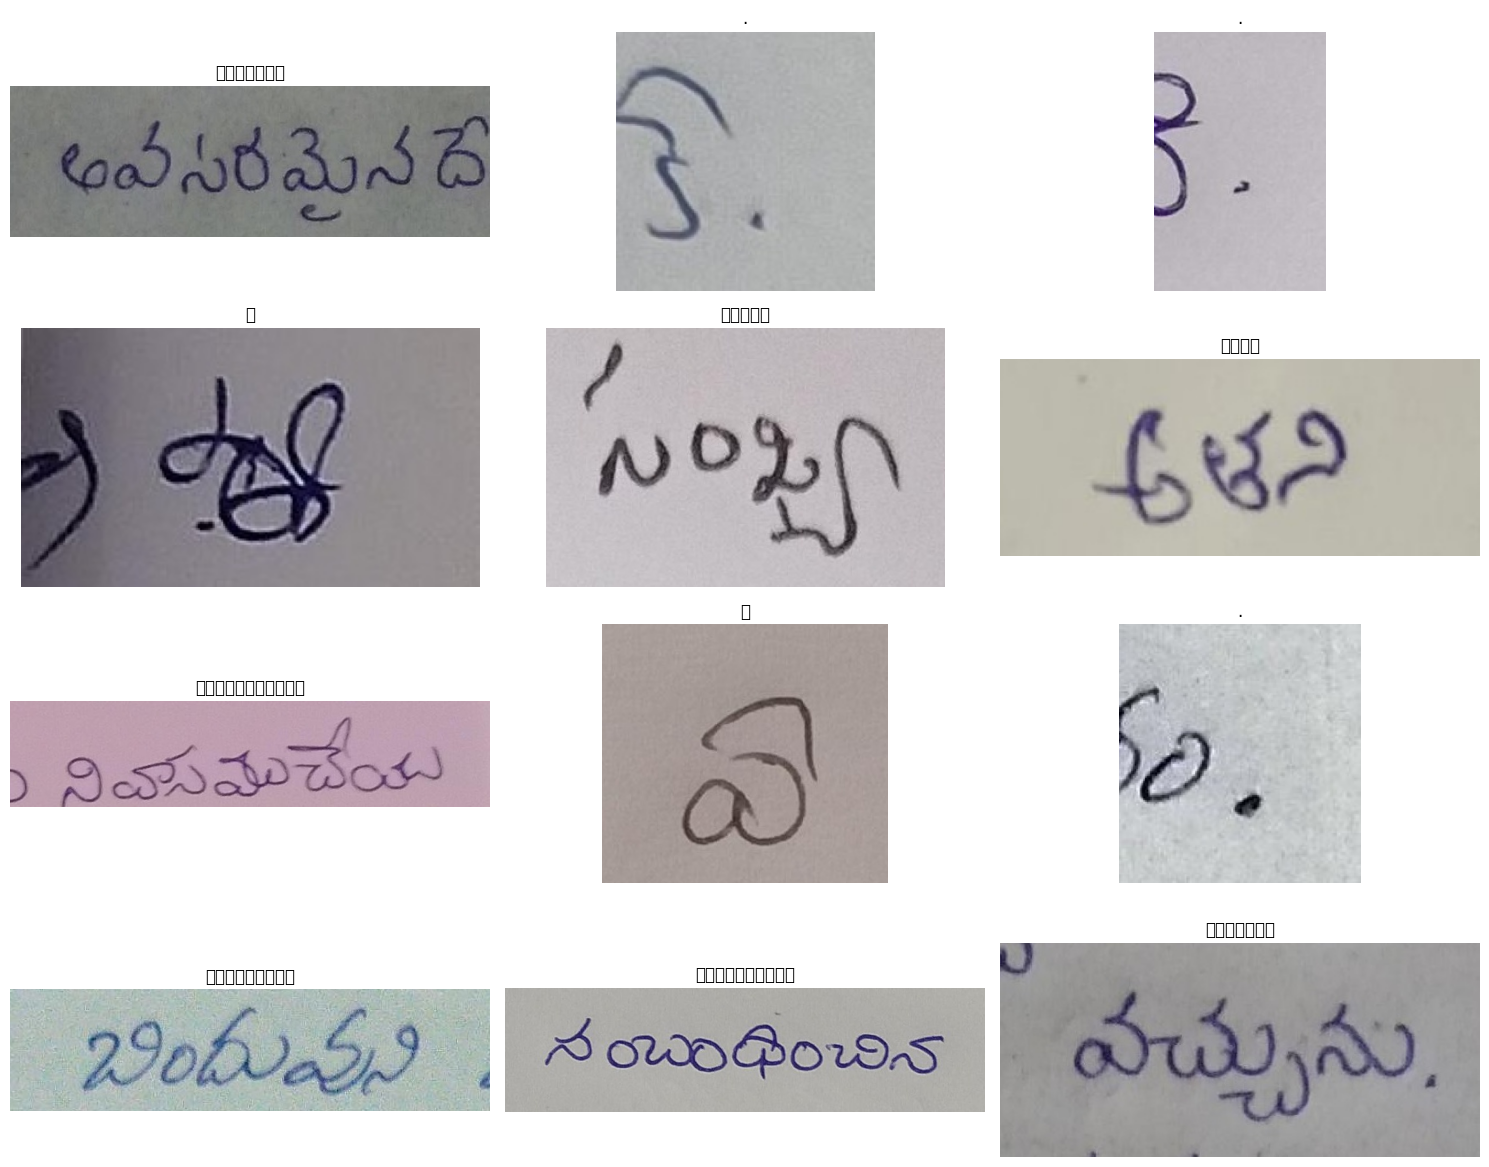

In [28]:
import matplotlib.pyplot as plt
from PIL import Image
import io
import random

sample_annotations = random.sample(train_annotations, 12)

with zipfile.ZipFile(train_zip_path, 'r') as z:

    plt.figure(figsize=(15, 12))

    for i, (image_path, word) in enumerate(sample_annotations):

        # Convert annotation path to ZIP path
        if image_path.startswith("image1/"):
            zip_image_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set1/"
                + image_path
            )
        elif image_path.startswith("image2/"):
            zip_image_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set2/"
                + image_path
            )
        else:
            continue

        image_data = z.read(zip_image_path)
        image = Image.open(io.BytesIO(image_data))

        plt.subplot(4, 3, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(word, fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [29]:
import zipfile
from PIL import Image
import io
import random
from collections import Counter

# Take 1000 random training samples
sample_annotations = random.sample(train_annotations, 1000)

dimensions = []
modes = Counter()

with zipfile.ZipFile(train_zip_path, 'r') as z:

    for image_path, word in sample_annotations:

        if image_path.startswith("image1/"):
            zip_image_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set1/"
                + image_path
            )
        elif image_path.startswith("image2/"):
            zip_image_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set2/"
                + image_path
            )
        else:
            continue

        try:
            image_data = z.read(zip_image_path)
            image = Image.open(io.BytesIO(image_data))

            dimensions.append(image.size)
            modes[image.mode] += 1

        except Exception as e:
            print("Error:", image_path, e)

print("Successfully inspected:", len(dimensions), "images")

print("\nImage modes:")
for mode, count in modes.items():
    print(mode, ":", count)

print("\nFirst 20 dimensions:")
for d in dimensions[:20]:
    print(d)

Successfully inspected: 1000 images

Image modes:
RGB : 1000

First 20 dimensions:
(181, 194)
(625, 242)
(744, 194)
(582, 195)
(744, 230)
(266, 160)
(467, 189)
(387, 224)
(370, 213)
(1013, 179)
(235, 145)
(358, 192)
(409, 259)
(180, 214)
(406, 198)
(662, 126)
(256, 205)
(467, 204)
(268, 190)
(220, 151)


In [30]:
widths = [w for w, h in dimensions]
heights = [h for w, h in dimensions]

print("Width:")
print("Min :", min(widths))
print("Max :", max(widths))
print("Mean:", sum(widths) / len(widths))

print("\nHeight:")
print("Min :", min(heights))
print("Max :", max(heights))
print("Mean:", sum(heights) / len(heights))

Width:
Min : 106
Max : 1228
Mean: 415.508

Height:
Min : 54
Max : 400
Mean: 189.995


In [31]:
print("\nMost common dimensions:")

dimension_counts = Counter(dimensions)

for dimension, count in dimension_counts.most_common(20):
    print(dimension, ":", count)


Most common dimensions:
(718, 190) : 2
(153, 170) : 2
(402, 191) : 2
(452, 168) : 2
(379, 145) : 2
(244, 161) : 2
(181, 194) : 1
(625, 242) : 1
(744, 194) : 1
(582, 195) : 1
(744, 230) : 1
(266, 160) : 1
(467, 189) : 1
(387, 224) : 1
(370, 213) : 1
(1013, 179) : 1
(235, 145) : 1
(358, 192) : 1
(409, 259) : 1
(180, 214) : 1


In [32]:
aspect_ratios = [w / h for w, h in dimensions]

print("Aspect Ratio Statistics")
print("-----------------------")
print("Min :", min(aspect_ratios))
print("Max :", max(aspect_ratios))
print("Mean:", sum(aspect_ratios) / len(aspect_ratios))

print("\nExamples:")
for i in range(20):
    print(
        f"Size={dimensions[i]} "
        f"Aspect Ratio={aspect_ratios[i]:.2f}"
    )

Aspect Ratio Statistics
-----------------------
Min : 0.4935064935064935
Max : 10.927710843373495
Mean: 2.2889252110167444

Examples:
Size=(181, 194) Aspect Ratio=0.93
Size=(625, 242) Aspect Ratio=2.58
Size=(744, 194) Aspect Ratio=3.84
Size=(582, 195) Aspect Ratio=2.98
Size=(744, 230) Aspect Ratio=3.23
Size=(266, 160) Aspect Ratio=1.66
Size=(467, 189) Aspect Ratio=2.47
Size=(387, 224) Aspect Ratio=1.73
Size=(370, 213) Aspect Ratio=1.74
Size=(1013, 179) Aspect Ratio=5.66
Size=(235, 145) Aspect Ratio=1.62
Size=(358, 192) Aspect Ratio=1.86
Size=(409, 259) Aspect Ratio=1.58
Size=(180, 214) Aspect Ratio=0.84
Size=(406, 198) Aspect Ratio=2.05
Size=(662, 126) Aspect Ratio=5.25
Size=(256, 205) Aspect Ratio=1.25
Size=(467, 204) Aspect Ratio=2.29
Size=(268, 190) Aspect Ratio=1.41
Size=(220, 151) Aspect Ratio=1.46


In [33]:
wide = sum(1 for r in aspect_ratios if r > 3)
very_wide = sum(1 for r in aspect_ratios if r > 5)
tall = sum(1 for r in aspect_ratios if r < 0.75)

print("Images with aspect ratio > 3 :", wide)
print("Images with aspect ratio > 5 :", very_wide)
print("Images with aspect ratio < 0.75 :", tall)

Images with aspect ratio > 3 : 217
Images with aspect ratio > 5 : 23
Images with aspect ratio < 0.75 : 30


In [34]:
wide = sum(1 for r in aspect_ratios if r > 3)
very_wide = sum(1 for r in aspect_ratios if r > 5)
tall = sum(1 for r in aspect_ratios if r < 0.75)

print("Images with aspect ratio > 3 :", wide)
print("Images with aspect ratio > 5 :", very_wide)
print("Images with aspect ratio < 0.75 :", tall)

Images with aspect ratio > 3 : 217
Images with aspect ratio > 5 : 23
Images with aspect ratio < 0.75 : 30


In [35]:
import zipfile
import hashlib
from collections import defaultdict

hash_to_files = defaultdict(list)

with zipfile.ZipFile(train_zip_path, 'r') as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith(".jpg")
    ]

    print("Images found:", len(image_files))

    for i, image_path in enumerate(image_files):

        data = z.read(image_path)

        image_hash = hashlib.md5(data).hexdigest()

        hash_to_files[image_hash].append(image_path)

        if (i + 1) % 5000 == 0:
            print(f"Processed {i+1}/{len(image_files)}")

Images found: 77625
Processed 5000/77625
Processed 10000/77625
Processed 15000/77625
Processed 20000/77625
Processed 25000/77625
Processed 30000/77625
Processed 35000/77625
Processed 40000/77625
Processed 45000/77625
Processed 50000/77625
Processed 55000/77625
Processed 60000/77625
Processed 65000/77625
Processed 70000/77625
Processed 75000/77625


In [36]:
duplicate_groups = [
    paths for paths in hash_to_files.values()
    if len(paths) > 1
]

duplicate_images = sum(
    len(paths) for paths in duplicate_groups
)

print("\nUnique image hashes:", len(hash_to_files))
print("Duplicate groups:", len(duplicate_groups))
print("Images involved in duplicates:", duplicate_images)

print("\nFirst 10 duplicate groups:")

for group in duplicate_groups[:10]:
    print(group)


Unique image hashes: 77450
Duplicate groups: 175
Images involved in duplicates: 350

First 10 duplicate groups:
['Word_Level_Training_Set/Word_Level_Training_Set1/image1/51943_34.jpg', 'Word_Level_Training_Set/Word_Level_Training_Set1/image1/51944_34.jpg']
['Word_Level_Training_Set/Word_Level_Training_Set1/image1/51944_23.jpg', 'Word_Level_Training_Set/Word_Level_Training_Set1/image1/51943_23.jpg']
['Word_Level_Training_Set/Word_Level_Training_Set1/image1/43875_25.jpg', 'Word_Level_Training_Set/Word_Level_Training_Set1/image1/43699_25.jpg']
['Word_Level_Training_Set/Word_Level_Training_Set1/image1/43875_14.jpg', 'Word_Level_Training_Set/Word_Level_Training_Set1/image1/43699_14.jpg']
['Word_Level_Training_Set/Word_Level_Training_Set1/image1/43697_34.jpg', 'Word_Level_Training_Set/Word_Level_Training_Set1/image1/44085_34.jpg']
['Word_Level_Training_Set/Word_Level_Training_Set1/image1/43875_27.jpg', 'Word_Level_Training_Set/Word_Level_Training_Set1/image1/43699_27.jpg']
['Word_Level_Trai

In [37]:
import zipfile
import hashlib

test_hashes = {}
train_hash_set = set(hash_to_files.keys())

with zipfile.ZipFile(zip_path, 'r') as z:

    test_image_files = [
        f for f in z.namelist()
        if f.lower().endswith(".jpg")
    ]

    print("Test images:", len(test_image_files))

    for i, image_path in enumerate(test_image_files):

        data = z.read(image_path)
        image_hash = hashlib.md5(data).hexdigest()

        test_hashes[image_hash] = image_path

        if (i + 1) % 1000 == 0:
            print(f"Processed {i+1}/{len(test_image_files)}")

Test images: 9585
Processed 1000/9585
Processed 2000/9585
Processed 3000/9585
Processed 4000/9585
Processed 5000/9585
Processed 6000/9585
Processed 7000/9585
Processed 8000/9585
Processed 9000/9585


In [38]:
train_test_duplicates = set(test_hashes.keys()) & train_hash_set

print("\nTrain-Test exact duplicate hashes:",
      len(train_test_duplicates))

if train_test_duplicates:

    print("\nMatching test images:")

    for h in list(train_test_duplicates)[:20]:
        print(test_hashes[h])
else:
    print("No exact train-test image duplicates found.")


Train-Test exact duplicate hashes: 0
No exact train-test image duplicates found.


In [39]:
# ============================================================
# PHASE 2.1 — VERIFY ANNOTATION ↔ IMAGE MAPPING
# ============================================================

import zipfile

print("Checking all training annotations against image files...")

with zipfile.ZipFile(train_zip_path, 'r') as z:

    zip_names = set(z.namelist())

    missing = []

    for image_path, word in train_annotations:

        if image_path.startswith("image1/"):
            full_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set1/"
                + image_path
            )

        elif image_path.startswith("image2/"):
            full_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set2/"
                + image_path
            )

        else:
            missing.append((image_path, word))
            continue

        if full_path not in zip_names:
            missing.append((image_path, word))

print("\n==============================")
print("ANNOTATION IMAGE CHECK")
print("==============================")

print("Total annotations :", len(train_annotations))
print("Missing images    :", len(missing))

if len(missing) == 0:
    print("✅ Every annotation has a corresponding image.")
else:
    print("⚠️ Missing images found.")

    print("\nFirst 20 missing entries:")
    for image_path, word in missing[:20]:
        print(image_path, "→", word)

Checking all training annotations against image files...

ANNOTATION IMAGE CHECK
Total annotations : 77625
Missing images    : 0
✅ Every annotation has a corresponding image.


In [40]:
# ============================================================
# PHASE 2.2 — CORRUPT / UNREADABLE IMAGE CHECK
# ============================================================

import zipfile
from PIL import Image
import io

corrupt_images = []

with zipfile.ZipFile(train_zip_path, 'r') as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith(".jpg")
    ]

    print("Total images to check:", len(image_files))

    for i, image_path in enumerate(image_files):

        try:
            image_data = z.read(image_path)

            image = Image.open(io.BytesIO(image_data))

            # Verify that the image can actually be decoded
            image.verify()

        except Exception as e:
            corrupt_images.append((image_path, str(e)))

        if (i + 1) % 5000 == 0:
            print(f"Checked {i+1}/{len(image_files)}")

print("\n==============================")
print("CORRUPT IMAGE CHECK")
print("==============================")

print("Total images :", len(image_files))
print("Corrupt images :", len(corrupt_images))

if len(corrupt_images) == 0:
    print("✅ All training images are readable.")
else:
    print("⚠️ Corrupt/unreadable images found.")

    print("\nFirst 20 problematic images:")
    for image_path, error in corrupt_images[:20]:
        print(image_path, "→", error)

Total images to check: 77625
Checked 5000/77625
Checked 10000/77625
Checked 15000/77625
Checked 20000/77625
Checked 25000/77625
Checked 30000/77625
Checked 35000/77625
Checked 40000/77625
Checked 45000/77625
Checked 50000/77625
Checked 55000/77625
Checked 60000/77625
Checked 65000/77625
Checked 70000/77625
Checked 75000/77625

CORRUPT IMAGE CHECK
Total images : 77625
Corrupt images : 0
✅ All training images are readable.


In [41]:
# ============================================================
# PHASE 2.3 — DUPLICATE-AWARE TRAIN / VALIDATION SPLIT
# ============================================================

import random
from collections import defaultdict

SEED = 42
VALIDATION_RATIO = 0.10

random.seed(SEED)

# ------------------------------------------------------------
# 1. Create image-path → annotation mapping
# ------------------------------------------------------------

annotation_dict = {
    image_path: word
    for image_path, word in train_annotations
}

# ------------------------------------------------------------
# 2. Build duplicate groups
# ------------------------------------------------------------

duplicate_group_map = {}

for group_id, paths in enumerate(duplicate_groups):

    for path in paths:
        duplicate_group_map[path] = group_id

# ------------------------------------------------------------
# 3. Create groups so exact duplicates stay together
# ------------------------------------------------------------

groups = defaultdict(list)

for image_path, word in train_annotations:

    if image_path in duplicate_group_map:
        group_id = duplicate_group_map[image_path]
        groups[f"duplicate_{group_id}"].append(
            (image_path, word)
        )
    else:
        # Every non-duplicate sample becomes its own group
        groups[f"single_{image_path}"].append(
            (image_path, word)
        )

group_list = list(groups.values())

print("Total samples :", len(train_annotations))
print("Total groups  :", len(group_list))
print("Duplicate groups included :", len(duplicate_groups))

# ------------------------------------------------------------
# 4. Shuffle groups
# ------------------------------------------------------------

random.shuffle(group_list)

# ------------------------------------------------------------
# 5. Select validation groups
# ------------------------------------------------------------

target_validation = int(
    len(train_annotations) * VALIDATION_RATIO
)

train_data = []
val_data = []

val_count = 0

for group in group_list:

    if val_count < target_validation:
        val_data.extend(group)
        val_count += len(group)
    else:
        train_data.extend(group)

# ------------------------------------------------------------
# 6. Final shuffle
# ------------------------------------------------------------

random.shuffle(train_data)
random.shuffle(val_data)

# ------------------------------------------------------------
# 7. Results
# ------------------------------------------------------------

print("\n==============================")
print("TRAIN / VALIDATION SPLIT")
print("==============================")

print("Total samples :", len(train_annotations))
print("Training      :", len(train_data))
print("Validation    :", len(val_data))

print(
    "Training %    :",
    round(len(train_data) / len(train_annotations) * 100, 2)
)

print(
    "Validation %  :",
    round(len(val_data) / len(train_annotations) * 100, 2)
)

Total samples : 77625
Total groups  : 77625
Duplicate groups included : 175

TRAIN / VALIDATION SPLIT
Total samples : 77625
Training      : 69863
Validation    : 7762
Training %    : 90.0
Validation %  : 10.0


In [42]:
# ============================================================
# VERIFY NO IMAGE OVERLAP
# ============================================================

train_paths = set(path for path, word in train_data)
val_paths = set(path for path, word in val_data)

overlap = train_paths & val_paths

print("\nTrain images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Train-Val path overlap:", len(overlap))

if len(overlap) == 0:
    print("✅ No image-path overlap between train and validation.")
else:
    print("⚠️ Overlap detected!")


Train images: 69863
Validation images: 7762
Train-Val path overlap: 0
✅ No image-path overlap between train and validation.


In [43]:
# ============================================================
# VERIFY EXACT DUPLICATE GROUPS STAY TOGETHER
# ============================================================

train_set = set(train_paths)
val_set = set(val_paths)

split_duplicate_groups = []

for group in duplicate_groups:

    group_train = sum(path in train_set for path in group)
    group_val = sum(path in val_set for path in group)

    if group_train > 0 and group_val > 0:
        split_duplicate_groups.append(group)

print(
    "Duplicate groups split across train/validation:",
    len(split_duplicate_groups)
)

if len(split_duplicate_groups) == 0:
    print("✅ All exact-duplicate groups remain within one split.")
else:
    print("⚠️ Some duplicate groups were split.")

Duplicate groups split across train/validation: 0
✅ All exact-duplicate groups remain within one split.


In [44]:
print("Total samples :", len(train_annotations))
print("Training      :", len(train_data))
print("Validation    :", len(val_data))

print(
    "Training %    :",
    round(len(train_data) / len(train_annotations) * 100, 2)
)

print(
    "Validation %  :",
    round(len(val_data) / len(train_annotations) * 100, 2)
)

Total samples : 77625
Training      : 69863
Validation    : 7762
Training %    : 90.0
Validation %  : 10.0


In [45]:
train_paths = set(path for path, word in train_data)
val_paths = set(path for path, word in val_data)

overlap = train_paths & val_paths

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Train-Val path overlap:", len(overlap))

Train images: 69863
Validation images: 7762
Train-Val path overlap: 0


In [46]:
# ============================================================
# PHASE 2.4 — TELUGU LABEL / UNICODE ANALYSIS
# ============================================================

import unicodedata
from collections import Counter

all_labels = [word for _, word in train_annotations]

# Count Unicode characters
char_counter = Counter()

for word in all_labels:
    for char in word:
        char_counter[char] += 1

print("Total unique Unicode characters:", len(char_counter))

print("\nTop 100 characters/tokens:")
for char, count in char_counter.most_common(100):

    print(
        f"{repr(char):15} "
        f"count={count:7d} "
        f"Unicode=U+{ord(char):04X} "
        f"name={unicodedata.name(char, 'UNKNOWN')}"
    )

Total unique Unicode characters: 88

Top 100 characters/tokens:
'ి'             count=  35767 Unicode=U+0C3F name=TELUGU VOWEL SIGN I
'ు'             count=  31078 Unicode=U+0C41 name=TELUGU VOWEL SIGN U
'్'             count=  27948 Unicode=U+0C4D name=TELUGU SIGN VIRAMA
'న'             count=  27817 Unicode=U+0C28 name=TELUGU LETTER NA
'ా'             count=  27474 Unicode=U+0C3E name=TELUGU VOWEL SIGN AA
'ర'             count=  22933 Unicode=U+0C30 name=TELUGU LETTER RA
'ం'             count=  21469 Unicode=U+0C02 name=TELUGU SIGN ANUSVARA
'క'             count=  18507 Unicode=U+0C15 name=TELUGU LETTER KA
'ల'             count=  17310 Unicode=U+0C32 name=TELUGU LETTER LA
'త'             count=  14037 Unicode=U+0C24 name=TELUGU LETTER TA
'వ'             count=  13137 Unicode=U+0C35 name=TELUGU LETTER VA
'ద'             count=  12309 Unicode=U+0C26 name=TELUGU LETTER DA
'ప'             count=  11989 Unicode=U+0C2A name=TELUGU LETTER PA
'మ'             count=  10908 Unicode=U+0C2E name

In [47]:
# ============================================================
# CHECK UNICODE NORMALIZATION
# ============================================================

different_normalization = 0

for word in all_labels:

    if word != unicodedata.normalize("NFC", word):
        different_normalization += 1

print("Labels requiring NFC normalization:",
      different_normalization)

if different_normalization == 0:
    print("✅ All labels are already NFC normalized.")
else:
    print("⚠️ Some labels require normalization.")

Labels requiring NFC normalization: 0
✅ All labels are already NFC normalized.


In [48]:
# ============================================================
# PHASE 2.4 — CHARACTER INVENTORY
# ============================================================

from collections import Counter
import unicodedata

char_counter = Counter()

for word in all_labels:
    for char in word:
        char_counter[char] += 1

print("Total unique Unicode characters:", len(char_counter))

print("\nCharacter inventory:")
print("-" * 70)

for char, count in sorted(
    char_counter.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(
        f"{repr(char):12} "
        f"Count={count:7d} "
        f"Code=U+{ord(char):04X} "
        f"Name={unicodedata.name(char, 'UNKNOWN')}"
    )

Total unique Unicode characters: 88

Character inventory:
----------------------------------------------------------------------
'ి'          Count=  35767 Code=U+0C3F Name=TELUGU VOWEL SIGN I
'ు'          Count=  31078 Code=U+0C41 Name=TELUGU VOWEL SIGN U
'్'          Count=  27948 Code=U+0C4D Name=TELUGU SIGN VIRAMA
'న'          Count=  27817 Code=U+0C28 Name=TELUGU LETTER NA
'ా'          Count=  27474 Code=U+0C3E Name=TELUGU VOWEL SIGN AA
'ర'          Count=  22933 Code=U+0C30 Name=TELUGU LETTER RA
'ం'          Count=  21469 Code=U+0C02 Name=TELUGU SIGN ANUSVARA
'క'          Count=  18507 Code=U+0C15 Name=TELUGU LETTER KA
'ల'          Count=  17310 Code=U+0C32 Name=TELUGU LETTER LA
'త'          Count=  14037 Code=U+0C24 Name=TELUGU LETTER TA
'వ'          Count=  13137 Code=U+0C35 Name=TELUGU LETTER VA
'ద'          Count=  12309 Code=U+0C26 Name=TELUGU LETTER DA
'ప'          Count=  11989 Code=U+0C2A Name=TELUGU LETTER PA
'మ'          Count=  10908 Code=U+0C2E Name=TELUGU LETTER MA
'

In [49]:
# ============================================================
# CHECK TELUGU / NON-TELUGU CHARACTER COUNTS
# ============================================================

telugu_chars = []
non_telugu_chars = []

for char in char_counter:

    code = ord(char)

    if 0x0C00 <= code <= 0x0C7F:
        telugu_chars.append(char)
    else:
        non_telugu_chars.append(char)

print("Telugu Unicode characters :", len(telugu_chars))
print("Non-Telugu characters     :", len(non_telugu_chars))

print("\nNon-Telugu characters:")
for char in non_telugu_chars:
    print(
        repr(char),
        f"U+{ord(char):04X}",
        unicodedata.name(char, "UNKNOWN"),
        "count =", char_counter[char]
    )

Telugu Unicode characters : 61
Non-Telugu characters     : 27

Non-Telugu characters:
'.' U+002E FULL STOP count = 8047
'1' U+0031 DIGIT ONE count = 1893
'2' U+0032 DIGIT TWO count = 1434
'7' U+0037 DIGIT SEVEN count = 829
'9' U+0039 DIGIT NINE count = 1023
'6' U+0036 DIGIT SIX count = 901
'8' U+0038 DIGIT EIGHT count = 593
',' U+002C COMMA count = 2502
'5' U+0035 DIGIT FIVE count = 845
'3' U+0033 DIGIT THREE count = 1047
'4' U+0034 DIGIT FOUR count = 852
'0' U+0030 DIGIT ZERO count = 1307
'"' U+0022 QUOTATION MARK count = 259
'-' U+002D HYPHEN-MINUS count = 172
'(' U+0028 LEFT PARENTHESIS count = 126
')' U+0029 RIGHT PARENTHESIS count = 230
'?' U+003F QUESTION MARK count = 551
':' U+003A COLON count = 47
'%' U+0025 PERCENT SIGN count = 16
"'" U+0027 APOSTROPHE count = 25
'!' U+0021 EXCLAMATION MARK count = 66
';' U+003B SEMICOLON count = 17
'/' U+002F SOLIDUS count = 5
'O' U+004F LATIN CAPITAL LETTER O count = 2
'P' U+0050 LATIN CAPITAL LETTER P count = 2
'A' U+0041 LATIN CAPITAL LETT

In [50]:
# PHASE 2.5 — Build Character Vocabulary

from collections import Counter

# Character frequency
char_counter = Counter()

for word in all_labels:
    for char in word:
        char_counter[char] += 1

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Character vocabulary
characters = sorted(char_counter.keys())

char_to_id = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for idx, char in enumerate(characters, start=2):
    char_to_id[char] = idx

id_to_char = {idx: char for char, idx in char_to_id.items()}

print("Number of actual characters:", len(characters))
print("Vocabulary size:", len(char_to_id))

print("\nSpecial tokens:")
print(PAD_TOKEN, "=", char_to_id[PAD_TOKEN])
print(UNK_TOKEN, "=", char_to_id[UNK_TOKEN])

print("\nFirst 30 vocabulary entries:")
for idx, char in list(id_to_char.items())[:30]:
    print(idx, repr(char))

Number of actual characters: 88
Vocabulary size: 90

Special tokens:
<PAD> = 0
<UNK> = 1

First 30 vocabulary entries:
0 '<PAD>'
1 '<UNK>'
2 '!'
3 '"'
4 '%'
5 "'"
6 '('
7 ')'
8 ','
9 '-'
10 '.'
11 '/'
12 '0'
13 '1'
14 '2'
15 '3'
16 '4'
17 '5'
18 '6'
19 '7'
20 '8'
21 '9'
22 ':'
23 ';'
24 '?'
25 'A'
26 'O'
27 'P'
28 '॥'
29 'ఁ'


In [51]:
# Verify label encoding and decoding

sample_words = all_labels[:10]

for word in sample_words:
    encoded = [
        char_to_id.get(char, char_to_id[UNK_TOKEN])
        for char in word
    ]

    decoded = "".join(
        id_to_char.get(idx, UNK_TOKEN)
        for idx in encoded
    )

    print("Original :", word)
    print("Encoded  :", encoded)
    print("Decoded  :", decoded)
    print("Match    :", word == decoded)
    print("-" * 60)

Original : అది
Encoded  : [32, 60, 78]
Decoded  : అది
Match    : True
------------------------------------------------------------
Original : వెలువడకపోయినా
Encoded  : [72, 83, 70, 80, 72, 55, 45, 63, 87, 68, 78, 62, 77]
Decoded  : వెలువడకపోయినా
Match    : True
------------------------------------------------------------
Original : దానిలోని
Encoded  : [60, 77, 62, 78, 70, 87, 62, 78]
Decoded  : దానిలోని
Match    : True
------------------------------------------------------------
Original : పరిశోధకమండలి
Encoded  : [63, 69, 78, 73, 87, 61, 45, 67, 30, 55, 70, 78]
Decoded  : పరిశోధకమండలి
Match    : True
------------------------------------------------------------
Original : పత్రికలో
Encoded  : [63, 58, 89, 69, 78, 45, 70, 87]
Decoded  : పత్రికలో
Match    : True
------------------------------------------------------------
Original : ప్రకటింప
Encoded  : [63, 89, 69, 45, 53, 78, 30, 63]
Decoded  : ప్రకటింప
Match    : True
------------------------------------------------------------
Original :

In [52]:
# PHASE 2.6 — Create Encoded Training and Validation Records

def encode_label(word):
    return [
        char_to_id.get(char, char_to_id[UNK_TOKEN])
        for char in word
    ]


# Training records
train_records = []

for path, label in train_data:
    train_records.append({
        "image_path": path,
        "label": label,
        "encoded_label": encode_label(label)
    })


# Validation records
val_records = []

for path, label in val_data:
    val_records.append({
        "image_path": path,
        "label": label,
        "encoded_label": encode_label(label)
    })


print("Training records  :", len(train_records))
print("Validation records:", len(val_records))

print("\nSample training records:")
for record in train_records[:5]:
    print(record)

Training records  : 69863
Validation records: 7762

Sample training records:
{'image_path': 'image1/70155_14.jpg', 'label': '"', 'encoded_label': [3]}
{'image_path': 'image1/42906_22.jpg', 'label': 'ప్రభుత్వ', 'encoded_label': [63, 89, 69, 66, 80, 58, 89, 72]}
{'image_path': 'image1/36746_30.jpg', 'label': 'కలుషితం', 'encoded_label': [45, 70, 80, 74, 78, 58, 30]}
{'image_path': 'image2/34901_6.jpg', 'label': 'సరిపోదు', 'encoded_label': [75, 69, 78, 63, 87, 60, 80]}
{'image_path': 'image2/42810_4.jpg', 'label': '.', 'encoded_label': [10]}


In [53]:
# Verify encoding → decoding

encoding_errors = 0

for record in train_records[:1000]:

    decoded = "".join(
        id_to_char[idx]
        for idx in record["encoded_label"]
    )

    if decoded != record["label"]:
        encoding_errors += 1

print("Encoding errors in first 1000 training samples:", encoding_errors)

if encoding_errors == 0:
    print("✅ Label encoding verified successfully.")
else:
    print("❌ Encoding mismatch detected.")

Encoding errors in first 1000 training samples: 0
✅ Label encoding verified successfully.


In [54]:
import os

# Search for the extracted training folders
possible_dirs = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Word_Level_Training_Set1" in dirs:
        possible_dirs.append(os.path.join(root, "Word_Level_Training_Set1"))
    if "Word_Level_Training_Set2" in dirs:
        possible_dirs.append(os.path.join(root, "Word_Level_Training_Set2"))

print("Found training folders:")

for d in possible_dirs:
    print(d)

Found training folders:


In [55]:
# PHASE 2.7 — Image Preprocessing Inspection
# Read images directly from the training ZIP

from PIL import Image
import zipfile
import io
import numpy as np

train_zip_path = "/content/drive/MyDrive/Word_Level_Telugu_Training_Set.zip"

widths = []
heights = []
aspect_ratios = []

# Inspect first 1000 training records
sample_records = train_records[:1000]

with zipfile.ZipFile(train_zip_path, "r") as z:

    for record in sample_records:

        img_path = record["image_path"]

        # Convert our relative annotation path to ZIP path
        if img_path.startswith("image1/"):
            zip_path = "Word_Level_Training_Set/Word_Level_Training_Set1/" + img_path

        elif img_path.startswith("image2/"):
            zip_path = "Word_Level_Training_Set/Word_Level_Training_Set2/" + img_path

        else:
            continue

        try:
            image_bytes = z.read(zip_path)

            with Image.open(io.BytesIO(image_bytes)) as img:
                w, h = img.size

            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)

        except Exception as e:
            print("Error:", zip_path, e)

print("Samples inspected :", len(widths))

print("\nWidth:")
print("  Min  :", min(widths))
print("  Max  :", max(widths))
print("  Mean :", round(np.mean(widths), 2))

print("\nHeight:")
print("  Min  :", min(heights))
print("  Max  :", max(heights))
print("  Mean :", round(np.mean(heights), 2))

print("\nAspect Ratio (W/H):")
print("  Min  :", round(min(aspect_ratios), 2))
print("  Max  :", round(max(aspect_ratios), 2))
print("  Mean :", round(np.mean(aspect_ratios), 2))

Samples inspected : 1000

Width:
  Min  : 116
  Max  : 1339
  Mean : 414.9

Height:
  Min  : 46
  Max  : 344
  Mean : 189.23

Aspect Ratio (W/H):
  Min  : 0.48
  Max  : 19.93
  Mean : 2.34


Label: " | Original: 195x242 | Resized: 51x64


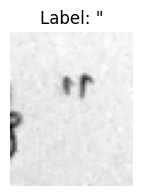

Label: అది | Original: 257x140 | Resized: 117x64


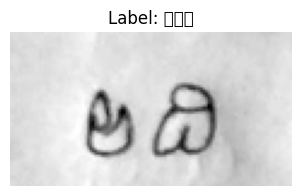

Label: . | Original: 187x224 | Resized: 53x64


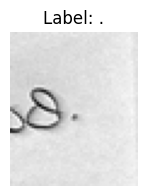

Label: ఆమె | Original: 333x218 | Resized: 97x64


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3078 (\N{TELUGU LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3142 (\N{TELUGU VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


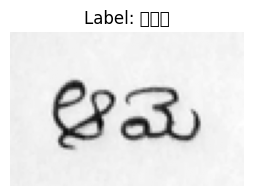

Label: ఉంది | Original: 297x150 | Resized: 126x64


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3081 (\N{TELUGU LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


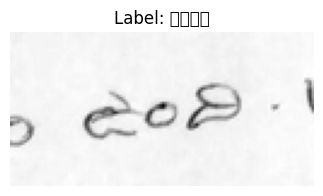

In [56]:
# PHASE 2.8 — Preprocessing Sanity Check

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import io

TARGET_HEIGHT = 64

# Select different word lengths
sample_indices = [0, 10, 100, 500, 999]

with zipfile.ZipFile(train_zip_path, "r") as z:

    for idx in sample_indices:

        record = train_records[idx]
        img_path = record["image_path"]
        label = record["label"]

        if img_path.startswith("image1/"):
            zip_path = "Word_Level_Training_Set/Word_Level_Training_Set1/" + img_path
        else:
            zip_path = "Word_Level_Training_Set/Word_Level_Training_Set2/" + img_path

        image_bytes = z.read(zip_path)

        with Image.open(io.BytesIO(image_bytes)) as img:
            img = img.convert("L")

            original_w, original_h = img.size

            # Width preserving resize
            new_w = int(original_w * TARGET_HEIGHT / original_h)

            resized = img.resize(
                (new_w, TARGET_HEIGHT),
                Image.Resampling.LANCZOS
            )

        print(
            f"Label: {label} | "
            f"Original: {original_w}x{original_h} | "
            f"Resized: {new_w}x{TARGET_HEIGHT}"
        )

        plt.figure(figsize=(10, 2))
        plt.imshow(resized, cmap="gray")
        plt.title(f"Label: {label}")
        plt.axis("off")
        plt.show()

In [57]:
# PHASE 2.9 — PyTorch Dataset Pipeline

import torch
from torch.utils.data import Dataset
from PIL import Image
import zipfile
import io
import numpy as np


TARGET_HEIGHT = 64


class TeluguWordDataset(Dataset):

    def __init__(self, records, zip_path, target_height=64):
        self.records = records
        self.zip_path = zip_path
        self.target_height = target_height

        # Open ZIP once for this Dataset object
        self.zip_file = zipfile.ZipFile(zip_path, "r")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        record = self.records[idx]

        img_path = record["image_path"]
        label = record["label"]
        encoded_label = record["encoded_label"]

        # Resolve path inside ZIP
        if img_path.startswith("image1/"):
            zip_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set1/"
                + img_path
            )

        elif img_path.startswith("image2/"):
            zip_path = (
                "Word_Level_Training_Set/"
                "Word_Level_Training_Set2/"
                + img_path
            )

        else:
            raise ValueError(f"Unknown image path: {img_path}")

        # Read image directly from ZIP
        image_bytes = self.zip_file.read(zip_path)

        # Open image
        image = Image.open(io.BytesIO(image_bytes)).convert("L")

        # Original dimensions
        original_width, original_height = image.size

        # Preserve aspect ratio
        new_width = int(
            original_width * self.target_height / original_height
        )

        # Resize
        image = image.resize(
            (new_width, self.target_height),
            Image.Resampling.LANCZOS
        )

        # Convert to numpy
        image_array = np.array(image, dtype=np.float32)

        # Normalize pixel values to [0, 1]
        image_array = image_array / 255.0

        # Convert H x W → 1 x H x W
        image_tensor = torch.tensor(
            image_array,
            dtype=torch.float32
        ).unsqueeze(0)

        # Convert label to tensor
        label_tensor = torch.tensor(
            encoded_label,
            dtype=torch.long
        )

        return image_tensor, label_tensor, label

In [58]:
# Test training dataset

train_dataset = TeluguWordDataset(
    train_records,
    train_zip_path,
    target_height=TARGET_HEIGHT
)

val_dataset = TeluguWordDataset(
    val_records,
    train_zip_path,
    target_height=TARGET_HEIGHT
)

print("Training dataset size  :", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

# Test one sample
image_tensor, label_tensor, label = train_dataset[0]

print("\nSample:")
print("Image tensor shape :", image_tensor.shape)
print("Label             :", label)
print("Encoded label     :", label_tensor.tolist())
print("Image min         :", image_tensor.min().item())
print("Image max         :", image_tensor.max().item())

Training dataset size  : 69863
Validation dataset size: 7762

Sample:
Image tensor shape : torch.Size([1, 64, 51])
Label             : "
Encoded label     : [3]
Image min         : 0.2549019753932953
Image max         : 0.6117647290229797


In [59]:
# PHASE 2.10 — Variable-Width Batch Collation

from torch.utils.data import DataLoader

PAD_VALUE = 1.0


def collate_fn(batch):

    images, labels, texts = zip(*batch)

    # Find maximum width in this batch
    max_width = max(
        image.shape[2]
        for image in images
    )

    batch_size = len(images)

    # Create padded image tensor
    padded_images = torch.full(
        (batch_size, 1, TARGET_HEIGHT, max_width),
        PAD_VALUE,
        dtype=torch.float32
    )

    # Copy each image into padded tensor
    for i, image in enumerate(images):

        width = image.shape[2]

        padded_images[
            i, :, :, :width
        ] = image

    # Labels remain variable length
    label_lengths = torch.tensor(
        [len(label) for label in labels],
        dtype=torch.long
    )

    # Concatenate labels
    concatenated_labels = torch.cat(labels)

    return (
        padded_images,
        concatenated_labels,
        label_lengths,
        texts
    )


# Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)


# Test one batch
images, labels, label_lengths, texts = next(iter(train_loader))

print("Batch image shape :", images.shape)
print("Concatenated labels shape :", labels.shape)
print("Label lengths :", label_lengths.tolist())
print("Texts :", texts)
print("Image min :", images.min().item())
print("Image max :", images.max().item())

Batch image shape : torch.Size([8, 1, 64, 210])
Concatenated labels shape : torch.Size([45])
Label lengths : [4, 2, 11, 8, 9, 1, 6, 4]
Texts : ('కాని', 'ఒక', 'ఆకర్షణీయమైన', 'ఉద్యోగము', 'సహాయాన్ని', '.', 'ఉంటాయి', 'చాలా')
Image min : 0.0
Image max : 1.0


In [ ]:
# ============================================================
# PHASE 3 — BASELINE DL MODEL 1
# CNN + BiLSTM + CTC
# ============================================================

import os
import time
import json
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# 3.1 ENVIRONMENT / GPU VERIFICATION
# ============================================================

print("=" * 70)
print("3.1 ENVIRONMENT / GPU VERIFICATION")
print("=" * 70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("Device          :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU Memory      :",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )
else:
    print("⚠️ GPU not available. Training will run on CPU.")


# ============================================================
# SETTINGS
# ============================================================

BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-3

NUM_CLASSES = len(char_to_id)

PAD_ID = char_to_id[PAD_TOKEN]
UNK_ID = char_to_id[UNK_TOKEN]

print("\nConfiguration:")
print("Batch size      :", BATCH_SIZE)
print("Epochs          :", EPOCHS)
print("Learning rate   :", LEARNING_RATE)
print("Vocabulary size :", NUM_CLASSES)


# ============================================================
# 3.2 BASELINE ARCHITECTURE
# CNN + BiLSTM + CTC
# ============================================================

print("\n" + "=" * 70)
print("3.2 BASELINE ARCHITECTURE")
print("=" * 70)


class CNN_BiLSTM_CTC(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(

            nn.Conv2d(
                1, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Reduce height to 1
            nn.AdaptiveAvgPool2d(
                (1, None)
            )
        )

        # Sequence model
        self.bilstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        # Character classifier
        self.classifier = nn.Linear(
            256 * 2,
            num_classes
        )

    def forward(self, x):

        # x:
        # [B, 1, 64, W]

        x = self.cnn(x)

        # [B, 256, 1, W]
        x = x.squeeze(2)

        # [B, 256, W]
        x = x.permute(0, 2, 1)

        # [B, W, 256]
        x, _ = self.bilstm(x)

        # [B, W, 512]
        x = self.classifier(x)

        # [B, W, C]
        return x


model = CNN_BiLSTM_CTC(
    num_classes=NUM_CLASSES
).to(device)

print(model)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", f"{total_parameters:,}")


# ============================================================
# 3.3 LOSS + OPTIMIZER
# ============================================================

print("\n" + "=" * 70)
print("3.3 LOSS + OPTIMIZER")
print("=" * 70)

# CTC blank = PAD token
ctc_loss = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss      : CTC Loss")
print("Optimizer : Adam")


# ============================================================
# 3.4 TRAINING LOOP
# ============================================================

print("\n" + "=" * 70)
print("3.4 TRAINING")
print("=" * 70)


def create_loaders():

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader


train_loader, val_loader = create_loaders()


def train_one_epoch(model, loader):

    model.train()

    total_loss = 0.0
    total_samples = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels, label_lengths, texts in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        # outputs:
        # [B, T, C]

        log_probs = outputs.log_softmax(2)

        # CTC expects:
        # [T, B, C]

        log_probs = log_probs.permute(
            1, 0, 2
        )

        batch_size = images.size(0)

        input_lengths = torch.full(
            size=(batch_size,),
            fill_value=outputs.size(1),
            dtype=torch.long,
            device=device
        )

        loss = ctc_loss(
            log_probs,
            labels,
            input_lengths,
            label_lengths
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return total_loss / total_samples


# ============================================================
# 3.5 VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("3.5 VALIDATION")
print("=" * 70)


def greedy_decode(outputs):

    # outputs: [B, T, C]

    predictions = outputs.argmax(
        dim=2
    )

    decoded_texts = []

    for sequence in predictions:

        result = []
        previous = None

        for token in sequence.tolist():

            # Remove CTC blank
            if token == PAD_ID:
                previous = token
                continue

            # Remove repeated tokens
            if token == previous:
                continue

            result.append(
                id_to_char.get(
                    token,
                    UNK_TOKEN
                )
            )

            previous = token

        decoded_texts.append(
            "".join(result)
        )

    return decoded_texts


def calculate_edit_distance(reference, hypothesis):

    m = len(reference)
    n = len(hypothesis)

    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):

        for j in range(1, n + 1):

            if reference[i - 1] == hypothesis[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[m][n]


@torch.no_grad()
def validate(model, loader):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    total_char_distance = 0
    total_reference_chars = 0

    total_word_errors = 0
    total_words = 0

    sample_predictions = []

    for images, labels, label_lengths, texts in tqdm(
        loader,
        desc="Validation",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        log_probs = outputs.log_softmax(2)

        log_probs_ctc = log_probs.permute(
            1, 0, 2
        )

        batch_size = images.size(0)

        input_lengths = torch.full(
            size=(batch_size,),
            fill_value=outputs.size(1),
            dtype=torch.long,
            device=device
        )

        loss = ctc_loss(
            log_probs_ctc,
            labels,
            input_lengths,
            label_lengths
        )

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = greedy_decode(outputs)

        for reference, prediction in zip(
            texts,
            predictions
        ):

            distance = calculate_edit_distance(
                reference,
                prediction
            )

            total_char_distance += distance
            total_reference_chars += len(reference)

            if reference != prediction:
                total_word_errors += 1

            total_words += 1

            if len(sample_predictions) < 10:
                sample_predictions.append(
                    (reference, prediction)
                )

    cer = (
        total_char_distance /
        max(total_reference_chars, 1)
    )

    wer = (
        total_word_errors /
        max(total_words, 1)
    )

    average_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return (
        average_loss,
        cer,
        wer,
        sample_predictions
    )


# ============================================================
# TRAINING + VALIDATION
# ============================================================

history = []

best_val_cer = float("inf")
best_epoch = 0

os.makedirs(
    "/content/baseline_results",
    exist_ok=True
)

start_time = time.time()


for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader
    )

    val_loss, cer, wer, samples = validate(
        model,
        val_loader
    )

    epoch_time = time.time() - epoch_start

    result = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "CER": cer,
        "WER": wer,
        "time_seconds": epoch_time
    }

    history.append(result)

    print("\n" + "-" * 70)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"CER        : {cer:.4f}")
    print(f"WER        : {wer:.4f}")
    print(f"Time       : {epoch_time:.2f} sec")

    print("\nSample predictions:")

    for reference, prediction in samples[:5]:

        print(
            f"GT   : {reference}"
        )

        print(
            f"Pred : {prediction}"
        )

        print()

    # Save best model based on validation CER
    if cer < best_val_cer:

        best_val_cer = cer
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_cer": cer,
                "val_wer": wer,
                "char_to_id": char_to_id,
                "id_to_char": id_to_char
            },
            "/content/baseline_results/baseline_cnn_bilstm_ctc_best.pt"
        )

        print("✅ Best model saved.")


total_time = time.time() - start_time


# ============================================================
# 3.7 SAVE BASELINE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("3.7 SAVE BASELINE RESULTS")
print("=" * 70)

final_results = {
    "model": "CNN-BiLSTM-CTC",
    "dataset": "ICDAR 2024 HWD / IHWR-1.0 Telugu Word-Level",
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "num_classes": NUM_CLASSES,
    "target_height": TARGET_HEIGHT,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "best_epoch": best_epoch,
    "best_validation_CER": best_val_cer,
    "total_training_time_seconds": total_time,
    "history": history
}

with open(
    "/content/baseline_results/baseline_results.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_results,
        f,
        ensure_ascii=False,
        indent=4
    )


# Save readable CSV
import csv

with open(
    "/content/baseline_results/baseline_history.csv",
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=history[0].keys()
    )

    writer.writeheader()
    writer.writerows(history)


print("Results saved to:")
print("/content/baseline_results/baseline_results.json")
print("/content/baseline_results/baseline_history.csv")
print("/content/baseline_results/baseline_cnn_bilstm_ctc_best.pt")

print("\n" + "=" * 70)
print("BASELINE MODEL 1 COMPLETE")
print("=" * 70)

print("Best epoch :", best_epoch)
print("Best CER   :", best_val_cer)
print("Total time :", round(total_time / 60, 2), "minutes")

In [ ]:
# ============================================================
# PHASE 4 — BASELINE DL MODEL 2
# CNN + TRANSFORMER ENCODER + CTC
# ============================================================

import os
import time
import json
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# 4.1 ENVIRONMENT / GPU VERIFICATION
# ============================================================

print("=" * 70)
print("4.1 ENVIRONMENT / GPU VERIFICATION")
print("=" * 70)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version :", torch.__version__)
print("Device          :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU Memory      :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )
else:
    print("⚠️ GPU not available. Training will run on CPU.")


# ============================================================
# SETTINGS
# ============================================================

BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-3

NUM_CLASSES = len(char_to_id)

PAD_ID = char_to_id[PAD_TOKEN]

print("\nConfiguration:")
print("Batch size      :", BATCH_SIZE)
print("Epochs          :", EPOCHS)
print("Learning rate   :", LEARNING_RATE)
print("Vocabulary size :", NUM_CLASSES)


# ============================================================
# 4.2 BASELINE ARCHITECTURE
# CNN + TRANSFORMER ENCODER + CTC
# ============================================================

print("\n" + "=" * 70)
print("4.2 BASELINE ARCHITECTURE")
print("=" * 70)


class CNN_Transformer_CTC(nn.Module):

    def __init__(
        self,
        num_classes,
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1
    ):

        super().__init__()

        # ----------------------------------------------------
        # CNN FEATURE EXTRACTOR
        # ----------------------------------------------------

        self.cnn = nn.Sequential(

            nn.Conv2d(
                1, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Reduce height to 1
            nn.AdaptiveAvgPool2d(
                (1, None)
            )
        )

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.positional_encoding = nn.Parameter(
            torch.randn(
                1,
                2000,
                d_model
            ) * 0.02
        )

        # ----------------------------------------------------
        # TRANSFORMER ENCODER
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            d_model,
            num_classes
        )

    def forward(self, x):

        # Input:
        # [B, 1, 64, W]

        x = self.cnn(x)

        # [B, 256, 1, W]

        x = x.squeeze(2)

        # [B, 256, W]

        x = x.permute(
            0, 2, 1
        )

        # [B, W, 256]

        sequence_length = x.size(1)

        if sequence_length > self.positional_encoding.size(1):
            raise ValueError(
                f"Sequence length {sequence_length} exceeds "
                f"maximum positional encoding length."
            )

        x = (
            x +
            self.positional_encoding[
                :, :sequence_length, :
            ]
        )

        # Transformer
        x = self.transformer(x)

        # [B, W, 256]

        x = self.classifier(x)

        # [B, W, C]

        return x


model2 = CNN_Transformer_CTC(
    num_classes=NUM_CLASSES
).to(device)


print(model2)

total_parameters = sum(
    p.numel()
    for p in model2.parameters()
    if p.requires_grad
)

print(
    "\nTrainable parameters:",
    f"{total_parameters:,}"
)


# ============================================================
# 4.3 LOSS + OPTIMIZER
# ============================================================

print("\n" + "=" * 70)
print("4.3 LOSS + OPTIMIZER")
print("=" * 70)

ctc_loss2 = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)

optimizer2 = optim.Adam(
    model2.parameters(),
    lr=LEARNING_RATE
)

print("Loss      : CTC Loss")
print("Optimizer : Adam")


# ============================================================
# 4.4 TRAINING LOOP
# ============================================================

print("\n" + "=" * 70)
print("4.4 TRAINING")
print("=" * 70)


train_loader2 = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader2 = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


def train_epoch_model2(
    model,
    loader
):

    model.train()

    total_loss = 0.0
    total_samples = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for (
        images,
        labels,
        label_lengths,
        texts
    ) in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        optimizer2.zero_grad()

        outputs = model(images)

        log_probs = outputs.log_softmax(2)

        # CTC:
        # [T, B, C]

        log_probs = log_probs.permute(
            1, 0, 2
        )

        batch_size = images.size(0)

        input_lengths = torch.full(
            (batch_size,),
            outputs.size(1),
            dtype=torch.long,
            device=device
        )

        loss = ctc_loss2(
            log_probs,
            labels,
            input_lengths,
            label_lengths
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer2.step()

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss /
        max(total_samples, 1)
    )


# ============================================================
# 4.5 VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("4.5 VALIDATION")
print("=" * 70)


def greedy_decode_model2(
    outputs
):

    predictions = outputs.argmax(
        dim=2
    )

    decoded_texts = []

    for sequence in predictions:

        result = []
        previous = None

        for token in sequence.tolist():

            # CTC blank
            if token == PAD_ID:
                previous = token
                continue

            # CTC repeated token
            if token == previous:
                continue

            result.append(
                id_to_char.get(
                    token,
                    UNK_TOKEN
                )
            )

            previous = token

        decoded_texts.append(
            "".join(result)
        )

    return decoded_texts


def edit_distance(
    reference,
    hypothesis
):

    m = len(reference)
    n = len(hypothesis)

    dp = [
        [0] * (n + 1)
        for _ in range(m + 1)
    ]

    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):

        for j in range(1, n + 1):

            if reference[i - 1] == hypothesis[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[m][n]


@torch.no_grad()
def validate_model2(
    model,
    loader
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    total_char_distance = 0
    total_reference_chars = 0

    total_word_errors = 0
    total_words = 0

    sample_predictions = []

    for (
        images,
        labels,
        label_lengths,
        texts
    ) in tqdm(
        loader,
        desc="Validation",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        log_probs = outputs.log_softmax(2)

        log_probs_ctc = log_probs.permute(
            1, 0, 2
        )

        batch_size = images.size(0)

        input_lengths = torch.full(
            (batch_size,),
            outputs.size(1),
            dtype=torch.long,
            device=device
        )

        loss = ctc_loss2(
            log_probs_ctc,
            labels,
            input_lengths,
            label_lengths
        )

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        predictions = greedy_decode_model2(
            outputs
        )

        for reference, prediction in zip(
            texts,
            predictions
        ):

            distance = edit_distance(
                reference,
                prediction
            )

            total_char_distance += distance
            total_reference_chars += len(
                reference
            )

            if reference != prediction:
                total_word_errors += 1

            total_words += 1

            if len(sample_predictions) < 10:
                sample_predictions.append(
                    (
                        reference,
                        prediction
                    )
                )

    cer = (
        total_char_distance /
        max(total_reference_chars, 1)
    )

    wer = (
        total_word_errors /
        max(total_words, 1)
    )

    average_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return (
        average_loss,
        cer,
        wer,
        sample_predictions
    )


# ============================================================
# TRAIN MODEL 2
# ============================================================

history2 = []

best_val_cer2 = float("inf")
best_epoch2 = 0

os.makedirs(
    "/content/baseline_results",
    exist_ok=True
)

start_time2 = time.time()


for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    train_loss = train_epoch_model2(
        model2,
        train_loader2
    )

    (
        val_loss,
        cer,
        wer,
        samples
    ) = validate_model2(
        model2,
        val_loader2
    )

    epoch_time = (
        time.time() -
        epoch_start
    )

    result = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "CER": cer,
        "WER": wer,
        "time_seconds": epoch_time
    }

    history2.append(result)

    print("\n" + "-" * 70)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"CER        : {cer:.4f}")
    print(f"WER        : {wer:.4f}")
    print(f"Time       : {epoch_time:.2f} sec")

    print("\nSample predictions:")

    for reference, prediction in samples[:5]:

        print(
            f"GT   : {reference}"
        )

        print(
            f"Pred : {prediction}"
        )

        print()

    if cer < best_val_cer2:

        best_val_cer2 = cer
        best_epoch2 = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model2.state_dict(),
                "optimizer_state_dict": optimizer2.state_dict(),
                "val_cer": cer,
                "val_wer": wer,
                "char_to_id": char_to_id,
                "id_to_char": id_to_char
            },
            "/content/baseline_results/"
            "baseline_cnn_transformer_ctc_best.pt"
        )

        print("✅ Best Model 2 saved.")


# ============================================================
# 4.7 SAVE BASELINE 2 RESULTS
# ============================================================

print("\n" + "=" * 70)
print("4.7 SAVE BASELINE 2 RESULTS")
print("=" * 70)

total_time2 = (
    time.time() -
    start_time2
)

final_results2 = {
    "model": "CNN-Transformer-CTC",
    "dataset": "ICDAR 2024 HWD / IHWR-1.0 Telugu Word-Level",
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "num_classes": NUM_CLASSES,
    "target_height": TARGET_HEIGHT,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "best_epoch": best_epoch2,
    "best_validation_CER": best_val_cer2,
    "total_training_time_seconds": total_time2,
    "history": history2
}


with open(
    "/content/baseline_results/"
    "baseline2_results.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_results2,
        f,
        ensure_ascii=False,
        indent=4
    )


with open(
    "/content/baseline_results/"
    "baseline2_history.csv",
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=history2[0].keys()
    )

    writer.writeheader()
    writer.writerows(history2)


print(
    "Results saved to:"
)

print(
    "/content/baseline_results/"
    "baseline2_results.json"
)

print(
    "/content/baseline_results/"
    "baseline2_history.csv"
)

print(
    "/content/baseline_results/"
    "baseline_cnn_transformer_ctc_best.pt"
)


print("\n" + "=" * 70)
print("BASELINE MODEL 2 COMPLETE")
print("=" * 70)

print(
    "Best epoch :",
    best_epoch2
)

print(
    "Best CER   :",
    best_val_cer2
)

print(
    "Total time :",
    round(total_time2 / 60, 2),
    "minutes"
)

In [ ]:
# ============================================================
# PHASE 4 — BASELINE DL MODEL 2
# CNN + LIGHTWEIGHT TRANSFORMER ENCODER + CTC
# T4-SAFE VERSION
# ============================================================

import os
import time
import json
import csv
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# 4.1 ENVIRONMENT
# ============================================================

print("=" * 70)
print("4.1 ENVIRONMENT / GPU VERIFICATION")
print("=" * 70)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version :", torch.__version__)
print("Device          :", device)

if torch.cuda.is_available():

    print("GPU             :", torch.cuda.get_device_name(0))

    print(
        "GPU Memory      :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )


# ============================================================
# CONFIGURATION
# ============================================================

BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4

EPOCHS = 10
LEARNING_RATE = 1e-3

D_MODEL = 256
NHEAD = 8
NUM_TRANSFORMER_LAYERS = 2
DIM_FEEDFORWARD = 512
DROPOUT = 0.1

NUM_CLASSES = len(char_to_id)
PAD_ID = char_to_id[PAD_TOKEN]

print("\nConfiguration:")
print("Batch size              :", BATCH_SIZE)
print("Gradient accumulation   :", GRAD_ACCUM_STEPS)
print("Effective batch size   :", BATCH_SIZE * GRAD_ACCUM_STEPS)
print("Epochs                  :", EPOCHS)
print("Learning rate           :", LEARNING_RATE)
print("Transformer dimension   :", D_MODEL)
print("Attention heads         :", NHEAD)
print("Transformer layers      :", NUM_TRANSFORMER_LAYERS)
print("Feed-forward dimension  :", DIM_FEEDFORWARD)
print("Vocabulary size         :", NUM_CLASSES)


# ============================================================
# 4.2 BASELINE ARCHITECTURE
# ============================================================

print("\n" + "=" * 70)
print("4.2 BASELINE ARCHITECTURE")
print("=" * 70)


class CNN_LightTransformer_CTC(nn.Module):

    def __init__(
        self,
        num_classes,
        d_model=256,
        nhead=8,
        num_layers=2,
        dim_feedforward=512,
        dropout=0.1
    ):

        super().__init__()

        # ----------------------------------------------------
        # CNN FEATURE EXTRACTOR
        # ----------------------------------------------------

        self.cnn = nn.Sequential(

            nn.Conv2d(
                1,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                128,
                d_model,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(d_model),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, None)
            )
        )

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.positional_encoding = nn.Parameter(
            torch.randn(
                1,
                2000,
                d_model
            ) * 0.02
        )

        # ----------------------------------------------------
        # TRANSFORMER
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            d_model,
            num_classes
        )

    def forward(self, x):

        # [B, 1, 64, W]

        x = self.cnn(x)

        # [B, 256, 1, W]

        x = x.squeeze(2)

        # [B, 256, W]

        x = x.permute(
            0,
            2,
            1
        )

        # [B, W, 256]

        sequence_length = x.size(1)

        if sequence_length > 2000:
            raise ValueError(
                f"Sequence length {sequence_length} "
                f"exceeds positional encoding limit."
            )

        x = (
            x +
            self.positional_encoding[
                :,
                :sequence_length,
                :
            ]
        )

        # Transformer encoder

        x = self.transformer(x)

        # Character probabilities

        x = self.classifier(x)

        return x


model2 = CNN_LightTransformer_CTC(
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_TRANSFORMER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(device)


print(model2)

total_parameters = sum(
    p.numel()
    for p in model2.parameters()
    if p.requires_grad
)

print(
    "\nTrainable parameters:",
    f"{total_parameters:,}"
)


# ============================================================
# 4.3 LOSS + OPTIMIZER
# ============================================================

print("\n" + "=" * 70)
print("4.3 LOSS + OPTIMIZER")
print("=" * 70)

ctc_loss2 = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)

optimizer2 = optim.Adam(
    model2.parameters(),
    lr=LEARNING_RATE
)

print("Loss      : CTC Loss")
print("Optimizer : Adam")


# ============================================================
# 4.4 DATA LOADERS
# ============================================================

train_loader2 = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader2 = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_epoch_model2(model, loader):

    model.train()

    total_loss = 0.0
    total_samples = 0

    optimizer2.zero_grad(
        set_to_none=True
    )

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for step, (
        images,
        labels,
        label_lengths,
        texts
    ) in enumerate(progress):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        log_probs = outputs.log_softmax(2)

        log_probs = log_probs.permute(
            1,
            0,
            2
        )

        batch_size = images.size(0)

        input_lengths = torch.full(
            (batch_size,),
            outputs.size(1),
            dtype=torch.long,
            device=device
        )

        loss = ctc_loss2(
            log_probs,
            labels,
            input_lengths,
            label_lengths
        )

        # Gradient accumulation
        loss_for_backward = (
            loss / GRAD_ACCUM_STEPS
        )

        loss_for_backward.backward()

        if (
            (step + 1) % GRAD_ACCUM_STEPS == 0
            or
            (step + 1) == len(loader)
        ):

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer2.step()

            optimizer2.zero_grad(
                set_to_none=True
            )

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss /
        max(total_samples, 1)
    )


# ============================================================
# 4.5 VALIDATION
# ============================================================

def greedy_decode_model2(outputs):

    predictions = outputs.argmax(
        dim=2
    )

    decoded_texts = []

    for sequence in predictions:

        result = []
        previous = None

        for token in sequence.tolist():

            if token == PAD_ID:

                previous = token
                continue

            if token == previous:
                continue

            result.append(
                id_to_char.get(
                    token,
                    UNK_TOKEN
                )
            )

            previous = token

        decoded_texts.append(
            "".join(result)
        )

    return decoded_texts


def edit_distance_model2(
    reference,
    hypothesis
):

    m = len(reference)
    n = len(hypothesis)

    dp = [
        [0] * (n + 1)
        for _ in range(m + 1)
    ]

    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):

        for j in range(1, n + 1):

            if reference[i - 1] == hypothesis[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[m][n]


@torch.no_grad()
def validate_model2(
    model,
    loader
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    total_char_distance = 0
    total_reference_chars = 0

    total_word_errors = 0
    total_words = 0

    sample_predictions = []

    for (
        images,
        labels,
        label_lengths,
        texts
    ) in tqdm(
        loader,
        desc="Validation",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        log_probs = outputs.log_softmax(2)

        log_probs_ctc = log_probs.permute(
            1,
            0,
            2
        )

        batch_size = images.size(0)

        input_lengths = torch.full(
            (batch_size,),
            outputs.size(1),
            dtype=torch.long,
            device=device
        )

        loss = ctc_loss2(
            log_probs_ctc,
            labels,
            input_lengths,
            label_lengths
        )

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        predictions = greedy_decode_model2(
            outputs
        )

        for reference, prediction in zip(
            texts,
            predictions
        ):

            distance = edit_distance_model2(
                reference,
                prediction
            )

            total_char_distance += distance
            total_reference_chars += len(
                reference
            )

            if reference != prediction:
                total_word_errors += 1

            total_words += 1

            if len(sample_predictions) < 10:

                sample_predictions.append(
                    (
                        reference,
                        prediction
                    )
                )

    cer = (
        total_char_distance /
        max(total_reference_chars, 1)
    )

    wer = (
        total_word_errors /
        max(total_words, 1)
    )

    average_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return (
        average_loss,
        cer,
        wer,
        sample_predictions
    )


# ============================================================
# TRAINING
# ============================================================

print("\n" + "=" * 70)
print("4.4 TRAINING + 4.5 VALIDATION")
print("=" * 70)

history2 = []

best_val_cer2 = float("inf")
best_epoch2 = 0

start_time2 = time.time()

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    train_loss = train_epoch_model2(
        model2,
        train_loader2
    )

    (
        val_loss,
        cer,
        wer,
        samples
    ) = validate_model2(
        model2,
        val_loader2
    )

    epoch_time = (
        time.time() -
        epoch_start
    )

    result = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "CER": cer,
        "WER": wer,
        "time_seconds": epoch_time
    }

    history2.append(result)

    print("\n" + "-" * 70)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"CER        : {cer:.4f}")
    print(f"WER        : {wer:.4f}")
    print(f"Time       : {epoch_time:.2f} sec")

    print("\nSample predictions:")

    for reference, prediction in samples[:5]:

        print(
            "GT   :",
            reference
        )

        print(
            "Pred :",
            prediction
        )

        print()

    if cer < best_val_cer2:

        best_val_cer2 = cer
        best_epoch2 = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model2.state_dict(),
                "optimizer_state_dict": optimizer2.state_dict(),
                "val_cer": cer,
                "val_wer": wer,
                "char_to_id": char_to_id,
                "id_to_char": id_to_char
            },
            "/content/baseline_results/"
            "baseline_cnn_transformer_ctc_best.pt"
        )

        print("✅ Best Model 2 saved.")


# ============================================================
# 4.7 SAVE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("4.7 SAVE BASELINE 2 RESULTS")
print("=" * 70)

total_time2 = (
    time.time() -
    start_time2
)

final_results2 = {

    "model":
        "CNN-LightTransformer-CTC",

    "dataset":
        "ICDAR 2024 HWD / IHWR-1.0 Telugu Word-Level",

    "train_samples":
        len(train_dataset),

    "validation_samples":
        len(val_dataset),

    "num_classes":
        NUM_CLASSES,

    "target_height":
        TARGET_HEIGHT,

    "batch_size":
        BATCH_SIZE,

    "gradient_accumulation_steps":
        GRAD_ACCUM_STEPS,

    "effective_batch_size":
        BATCH_SIZE * GRAD_ACCUM_STEPS,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "d_model":
        D_MODEL,

    "attention_heads":
        NHEAD,

    "transformer_layers":
        NUM_TRANSFORMER_LAYERS,

    "dim_feedforward":
        DIM_FEEDFORWARD,

    "best_epoch":
        best_epoch2,

    "best_validation_CER":
        best_val_cer2,

    "total_training_time_seconds":
        total_time2,

    "history":
        history2
}


with open(
    "/content/baseline_results/"
    "baseline2_results.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_results2,
        f,
        ensure_ascii=False,
        indent=4
    )


with open(
    "/content/baseline_results/"
    "baseline2_history.csv",
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=history2[0].keys()
    )

    writer.writeheader()
    writer.writerows(history2)


print("Results saved:")
print(
    "/content/baseline_results/"
    "baseline2_results.json"
)

print(
    "/content/baseline_results/"
    "baseline2_history.csv"
)

print(
    "/content/baseline_results/"
    "baseline_cnn_transformer_ctc_best.pt"
)

print("\n" + "=" * 70)
print("BASELINE MODEL 2 COMPLETE")
print("=" * 70)

print("Best epoch :", best_epoch2)
print("Best CER   :", best_val_cer2)
print(
    "Total time :",
    round(total_time2 / 60, 2),
    "minutes"
)

In [ ]:
# ============================================================
# PHASE 5 — BASELINE COMPARISON
# ============================================================

import os
import json
import csv

comparison_dir = "/content/baseline_results"
os.makedirs(comparison_dir, exist_ok=True)


# Actual experimental results
comparison = {
    "Baseline_1": {
        "model": "CNN-BiLSTM-CTC",
        "parameters": 3046362,
        "best_epoch": 10,
        "best_CER": 0.07676059607260573,
        "best_WER": 0.2484,
        "training_time_minutes": 57.96
    },

    "Baseline_2": {
        "model": "CNN-LightTransformer-CTC",
        "parameters": 1959898,
        "best_epoch": 8,
        "best_CER": 0.9481221855995543,
        "best_WER": 0.8764,
        "training_time_minutes": 62.67
    }
}


# Save JSON
comparison_json = os.path.join(
    comparison_dir,
    "baseline_comparison.json"
)

with open(
    comparison_json,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        comparison,
        f,
        ensure_ascii=False,
        indent=4
    )


# Save CSV
comparison_csv = os.path.join(
    comparison_dir,
    "baseline_comparison.csv"
)

rows = []

for key, values in comparison.items():

    row = {
        "baseline": key,
        **values
    }

    rows.append(row)


with open(
    comparison_csv,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=rows[0].keys()
    )

    writer.writeheader()
    writer.writerows(rows)


print("=" * 70)
print("PHASE 5 — BASELINE COMPARISON SAVED")
print("=" * 70)

print("\nComparison:")
print(
    f"Baseline 1 CER : "
    f"{comparison['Baseline_1']['best_CER'] * 100:.2f}%"
)

print(
    f"Baseline 2 CER : "
    f"{comparison['Baseline_2']['best_CER'] * 100:.2f}%"
)

print(
    f"\nBaseline 1 WER : "
    f"{comparison['Baseline_1']['best_WER'] * 100:.2f}%"
)

print(
    f"Baseline 2 WER : "
    f"{comparison['Baseline_2']['best_WER'] * 100:.2f}%"
)

print("\nSaved:")
print(comparison_json)
print(comparison_csv)

In [ ]:
# ============================================================
# PHASE 6.1–6.2 — ERROR ANALYSIS
# Load Best Baseline 1 + Generate ALL Validation Predictions
# ============================================================

import os
import json
import torch
from tqdm.auto import tqdm


print("=" * 70)
print("PHASE 6.1 — LOAD BEST BASELINE 1")
print("=" * 70)


# ------------------------------------------------------------
# Load best Model 1 checkpoint
# ------------------------------------------------------------

checkpoint_path = (
    "/content/baseline_results/"
    "baseline_cnn_bilstm_ctc_best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print("Checkpoint loaded:")
print(checkpoint_path)

print("\nBest epoch :", checkpoint["epoch"])
print("Best CER   :", checkpoint["val_cer"])
print("Best WER   :", checkpoint["val_wer"])


# ------------------------------------------------------------
# Recreate Model 1
# ------------------------------------------------------------

model1_error = CNN_BiLSTM_CTC(
    num_classes=NUM_CLASSES
).to(device)

model1_error.load_state_dict(
    checkpoint["model_state_dict"]
)

model1_error.eval()

print("\n✅ Best Baseline 1 loaded successfully.")


# ============================================================
# PHASE 6.2 — GENERATE ALL VALIDATION PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 6.2 — GENERATE VALIDATION PREDICTIONS")
print("=" * 70)


error_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


all_error_records = []


with torch.no_grad():

    for (
        images,
        labels,
        label_lengths,
        texts
    ) in tqdm(
        error_loader,
        desc="Generating predictions"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model1_error(images)

        predictions = greedy_decode(
            outputs
        )

        for reference, prediction in zip(
            texts,
            predictions
        ):

            distance = calculate_edit_distance(
                reference,
                prediction
            )

            all_error_records.append(
                {
                    "reference": reference,
                    "prediction": prediction,
                    "edit_distance": distance,
                    "word_length": len(reference)
                }
            )


# ------------------------------------------------------------
# Verify prediction count
# ------------------------------------------------------------

print("\nPrediction generation complete.")

print(
    "Validation samples expected :",
    len(val_dataset)
)

print(
    "Validation predictions       :",
    len(all_error_records)
)


if len(all_error_records) == len(val_dataset):

    print(
        "✅ All validation samples "
        "have predictions."
    )

else:

    print(
        "❌ Prediction count mismatch."
    )


# ------------------------------------------------------------
# Basic error statistics
# ------------------------------------------------------------

total_words = len(all_error_records)

incorrect_words = sum(
    1
    for r in all_error_records
    if r["reference"] != r["prediction"]
)

correct_words = (
    total_words -
    incorrect_words
)

print("\nWord-level results:")
print("Total words    :", total_words)
print("Correct words  :", correct_words)
print("Incorrect words:", incorrect_words)

print(
    "Word accuracy  :",
    f"{correct_words / total_words * 100:.2f}%"
)


# ------------------------------------------------------------
# Show difficult examples
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAMPLE INCORRECT PREDICTIONS")
print("=" * 70)

incorrect_records = [
    r
    for r in all_error_records
    if r["reference"] != r["prediction"]
]

# Highest edit-distance examples
incorrect_records_sorted = sorted(
    incorrect_records,
    key=lambda x: x["edit_distance"],
    reverse=True
)

for record in incorrect_records_sorted[:20]:

    print(
        f"GT   : {record['reference']}"
    )

    print(
        f"Pred : {record['prediction']}"
    )

    print(
        f"Edit distance : "
        f"{record['edit_distance']}"
    )

    print(
        f"Word length   : "
        f"{record['word_length']}"
    )

    print("-" * 50)


# ------------------------------------------------------------
# Save raw predictions
# ------------------------------------------------------------

error_dir = (
    "/content/baseline_results/"
    "error_analysis"
)

os.makedirs(
    error_dir,
    exist_ok=True
)


predictions_path = os.path.join(
    error_dir,
    "validation_predictions.json"
)


with open(
    predictions_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        all_error_records,
        f,
        ensure_ascii=False,
        indent=2
    )


print("\nSaved:")
print(predictions_path)

print("\n" + "=" * 70)
print("PHASE 6.1–6.2 COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# PHASE 6.3 — ERROR ANALYSIS BY WORD LENGTH
# ============================================================

from collections import defaultdict
import json
import os


print("=" * 70)
print("PHASE 6.3 — ERROR ANALYSIS BY WORD LENGTH")
print("=" * 70)


# ------------------------------------------------------------
# Group validation predictions by reference word length
# ------------------------------------------------------------

length_groups = defaultdict(list)

for record in all_error_records:

    length = record["word_length"]

    length_groups[length].append(record)


length_results = []


for length in sorted(length_groups.keys()):

    records = length_groups[length]

    total_words = len(records)

    total_chars = sum(
        len(r["reference"])
        for r in records
    )

    total_distance = sum(
        r["edit_distance"]
        for r in records
    )

    correct_words = sum(
        1
        for r in records
        if r["reference"] == r["prediction"]
    )

    incorrect_words = (
        total_words -
        correct_words
    )

    cer = (
        total_distance /
        max(total_chars, 1)
    )

    word_accuracy = (
        correct_words /
        total_words
    )

    length_results.append(
        {
            "word_length": length,
            "samples": total_words,
            "correct_words": correct_words,
            "incorrect_words": incorrect_words,
            "word_accuracy": word_accuracy,
            "CER": cer
        }
    )


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print(
    f"{'Length':>8} "
    f"{'Samples':>10} "
    f"{'Correct':>10} "
    f"{'Word Acc.':>12} "
    f"{'CER':>12}"
)

print("-" * 60)


for result in length_results:

    print(
        f"{result['word_length']:>8} "
        f"{result['samples']:>10} "
        f"{result['correct_words']:>10} "
        f"{result['word_accuracy'] * 100:>11.2f}% "
        f"{result['CER'] * 100:>11.2f}%"
    )


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

length_path = (
    "/content/baseline_results/"
    "error_analysis/"
    "error_by_word_length.json"
)

with open(
    length_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        length_results,
        f,
        ensure_ascii=False,
        indent=2
    )


print("\nSaved:")
print(length_path)

print("\n" + "=" * 70)
print("PHASE 6.3 COMPLETE")
print("=" * 70)

In [ ]:
# ================================================================
# PHASE 6.4 — SUBSTITUTION / INSERTION / DELETION ANALYSIS
# ================================================================

print("=" * 70)
print("PHASE 6.4 — EDIT OPERATION ANALYSIS")
print("=" * 70)

from collections import Counter, defaultdict
import json
import os

# ------------------------------------------------
# Levenshtein operation analysis
# ------------------------------------------------
def edit_operations(reference, prediction):
    """
    Returns counts of:
    - substitutions
    - insertions
    - deletions
    """

    n = len(reference)
    m = len(prediction)

    # DP table
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    # Operation table
    ops = [[None] * (m + 1) for _ in range(n + 1)]

    # Initialization
    for i in range(1, n + 1):
        dp[i][0] = i
        ops[i][0] = "D"

    for j in range(1, m + 1):
        dp[0][j] = j
        ops[0][j] = "I"

    # Fill DP table
    for i in range(1, n + 1):
        for j in range(1, m + 1):

            if reference[i - 1] == prediction[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
                ops[i][j] = "M"

            else:
                substitution = dp[i - 1][j - 1] + 1
                deletion = dp[i - 1][j] + 1
                insertion = dp[i][j - 1] + 1

                best = min(substitution, deletion, insertion)
                dp[i][j] = best

                if best == substitution:
                    ops[i][j] = "S"
                elif best == deletion:
                    ops[i][j] = "D"
                else:
                    ops[i][j] = "I"

    # ------------------------------------------------
    # Backtrack
    # ------------------------------------------------
    i = n
    j = m

    substitutions = 0
    insertions = 0
    deletions = 0

    while i > 0 or j > 0:

        if i > 0 and j > 0 and ops[i][j] == "M":
            i -= 1
            j -= 1

        elif i > 0 and j > 0 and ops[i][j] == "S":
            substitutions += 1
            i -= 1
            j -= 1

        elif i > 0 and ops[i][j] == "D":
            deletions += 1
            i -= 1

        elif j > 0 and ops[i][j] == "I":
            insertions += 1
            j -= 1

        else:
            break

    return substitutions, insertions, deletions


# ================================================================
# 1. Overall analysis
# ================================================================

total_substitutions = 0
total_insertions = 0
total_deletions = 0

for record in all_error_records:

    ref = record["reference"]
    pred = record["prediction"]

    s, i, d = edit_operations(ref, pred)

    total_substitutions += s
    total_insertions += i
    total_deletions += d


total_operations = (
    total_substitutions +
    total_insertions +
    total_deletions
)

print("\nOVERALL EDIT OPERATIONS")
print("-" * 70)

print(f"Substitutions : {total_substitutions}")
print(f"Insertions   : {total_insertions}")
print(f"Deletions    : {total_deletions}")
print(f"Total        : {total_operations}")

if total_operations > 0:
    print("\nOperation contribution:")
    print(
        f"Substitution : "
        f"{100 * total_substitutions / total_operations:.2f}%"
    )
    print(
        f"Insertion    : "
        f"{100 * total_insertions / total_operations:.2f}%"
    )
    print(
        f"Deletion     : "
        f"{100 * total_deletions / total_operations:.2f}%"
    )


# ================================================================
# 2. Analysis by word length
# ================================================================

length_operations = defaultdict(
    lambda: {
        "substitutions": 0,
        "insertions": 0,
        "deletions": 0,
        "samples": 0
    }
)

for record in all_error_records:

    length = record["word_length"]

    s, i, d = edit_operations(
        record["reference"],
        record["prediction"]
    )

    length_operations[length]["substitutions"] += s
    length_operations[length]["insertions"] += i
    length_operations[length]["deletions"] += d
    length_operations[length]["samples"] += 1


print("\n\nEDIT OPERATIONS BY WORD LENGTH")
print("-" * 90)

print(
    f"{'Length':>8}"
    f"{'Samples':>10}"
    f"{'Sub':>10}"
    f"{'Ins':>10}"
    f"{'Del':>10}"
    f"{'Total':>10}"
)

print("-" * 90)

length_results = []

for length in sorted(length_operations):

    data = length_operations[length]

    s = data["substitutions"]
    i = data["insertions"]
    d = data["deletions"]

    total = s + i + d

    print(
        f"{length:>8}"
        f"{data['samples']:>10}"
        f"{s:>10}"
        f"{i:>10}"
        f"{d:>10}"
        f"{total:>10}"
    )

    length_results.append({
        "word_length": length,
        "samples": data["samples"],
        "substitutions": s,
        "insertions": i,
        "deletions": d,
        "total_operations": total
    })


# ================================================================
# 3. Save results
# ================================================================

error_dir = "/content/baseline_results/error_analysis"
os.makedirs(error_dir, exist_ok=True)

output_path = os.path.join(
    error_dir,
    "edit_operation_analysis.json"
)

results = {
    "overall": {
        "substitutions": total_substitutions,
        "insertions": total_insertions,
        "deletions": total_deletions,
        "total_operations": total_operations
    },
    "by_word_length": length_results
}

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("PHASE 6.4 COMPLETE")
print("=" * 70)

In [ ]:
# ================================================================
# PHASE 6.5 — FREQUENTLY CONFUSED CHARACTERS
# ================================================================

print("=" * 70)
print("PHASE 6.5 — FREQUENT CHARACTER CONFUSION ANALYSIS")
print("=" * 70)

from collections import Counter, defaultdict
import json
import os


# ------------------------------------------------
# Character-level substitution extraction
# ------------------------------------------------

def get_substitution_pairs(reference, prediction):
    """
    Extract substitution pairs using minimum-edit-distance alignment.

    Returns:
        Counter({
            (reference_char, predicted_char): count
        })
    """

    n = len(reference)
    m = len(prediction)

    # DP matrix
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    # Operation matrix
    ops = [[None] * (m + 1) for _ in range(n + 1)]

    # Initialization
    for i in range(1, n + 1):
        dp[i][0] = i
        ops[i][0] = "D"

    for j in range(1, m + 1):
        dp[0][j] = j
        ops[0][j] = "I"

    # Fill DP matrix
    for i in range(1, n + 1):

        for j in range(1, m + 1):

            if reference[i - 1] == prediction[j - 1]:

                dp[i][j] = dp[i - 1][j - 1]
                ops[i][j] = "M"

            else:

                substitution = dp[i - 1][j - 1] + 1
                deletion = dp[i - 1][j] + 1
                insertion = dp[i][j - 1] + 1

                best = min(
                    substitution,
                    deletion,
                    insertion
                )

                dp[i][j] = best

                # Same tie-breaking strategy as PHASE 6.4
                if best == substitution:
                    ops[i][j] = "S"

                elif best == deletion:
                    ops[i][j] = "D"

                else:
                    ops[i][j] = "I"


    # ------------------------------------------------
    # Backtrack
    # ------------------------------------------------

    i = n
    j = m

    substitution_pairs = Counter()

    while i > 0 or j > 0:

        if i > 0 and j > 0 and ops[i][j] == "M":

            i -= 1
            j -= 1

        elif i > 0 and j > 0 and ops[i][j] == "S":

            ref_char = reference[i - 1]
            pred_char = prediction[j - 1]

            substitution_pairs[
                (ref_char, pred_char)
            ] += 1

            i -= 1
            j -= 1

        elif i > 0 and ops[i][j] == "D":

            i -= 1

        elif j > 0 and ops[i][j] == "I":

            j -= 1

        else:
            break

    return substitution_pairs


# ================================================================
# 1. Collect all substitution pairs
# ================================================================

confusion_pairs = Counter()

for record in all_error_records:

    reference = record["reference"]
    prediction = record["prediction"]

    pairs = get_substitution_pairs(
        reference,
        prediction
    )

    confusion_pairs.update(pairs)


# ================================================================
# 2. Display top confusion pairs
# ================================================================

print("\nTOP 30 CHARACTER CONFUSION PAIRS")
print("-" * 70)

print(
    f"{'Rank':>6}"
    f"{'Reference':>15}"
    f"{'Predicted':>15}"
    f"{'Count':>10}"
)

print("-" * 70)

top_pairs = confusion_pairs.most_common(30)

for rank, ((ref_char, pred_char), count) in enumerate(
    top_pairs,
    start=1
):

    print(
        f"{rank:>6}"
        f"{ref_char:>15}"
        f"{pred_char:>15}"
        f"{count:>10}"
    )


# ================================================================
# 3. Character-wise confusion summary
# ================================================================

reference_confusions = defaultdict(Counter)

for (ref_char, pred_char), count in confusion_pairs.items():

    reference_confusions[ref_char][pred_char] += count


print("\n\nTOP CONFUSIONS FOR EACH REFERENCE CHARACTER")
print("-" * 90)

for ref_char in sorted(reference_confusions.keys()):

    predictions = reference_confusions[ref_char]

    top_prediction = predictions.most_common(3)

    formatted = ", ".join(
        [
            f"{pred}:{count}"
            for pred, count in top_prediction
        ]
    )

    print(
        f"Reference [{ref_char}] -> {formatted}"
    )


# ================================================================
# 4. Number of unique confusion pairs
# ================================================================

print("\n")
print("Unique substitution pairs :", len(confusion_pairs))
print(
    "Total substitution errors :",
    sum(confusion_pairs.values())
)


# ================================================================
# 5. Save results
# ================================================================

error_dir = "/content/baseline_results/error_analysis"

os.makedirs(
    error_dir,
    exist_ok=True
)


# Convert Counter tuple keys to JSON-friendly structure

top_pair_results = []

for (ref_char, pred_char), count in confusion_pairs.most_common():

    top_pair_results.append({
        "reference_character": ref_char,
        "predicted_character": pred_char,
        "count": count
    })


character_summary = {}

for ref_char, predictions in reference_confusions.items():

    character_summary[ref_char] = [
        {
            "predicted_character": pred_char,
            "count": count
        }
        for pred_char, count in predictions.most_common()
    ]


output_path = os.path.join(
    error_dir,
    "character_confusion_analysis.json"
)


results = {
    "total_substitution_errors":
        sum(confusion_pairs.values()),

    "unique_confusion_pairs":
        len(confusion_pairs),

    "top_confusion_pairs":
        top_pair_results,

    "reference_character_confusions":
        character_summary
}


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        ensure_ascii=False,
        indent=2
    )


print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("PHASE 6.5 COMPLETE")
print("=" * 70)

In [ ]:
print("Keys available in all_error_records[0]:")
print(all_error_records[0].keys())

print("\nFirst record:")
print(all_error_records[0])

In [ ]:
# ================================================================
# PHASE 6.6 — DIFFICULT EXAMPLES ANALYSIS
# CORRECTED VERSION
# ================================================================

print("=" * 70)
print("PHASE 6.6 — DIFFICULT EXAMPLES ANALYSIS")
print("=" * 70)

import os
import json

error_dir = "/content/baseline_results/error_analysis"
os.makedirs(error_dir, exist_ok=True)


# ================================================================
# 1. Select incorrect predictions
# ================================================================

incorrect_records = [
    r for r in all_error_records
    if r["reference"] != r["prediction"]
]

print(f"\nTotal validation samples : {len(all_error_records)}")
print(f"Incorrect predictions    : {len(incorrect_records)}")


# ================================================================
# 2. Sort by severity
# ================================================================

# Primary: highest edit distance
# Secondary: highest CER
# Tertiary: longest word

incorrect_records_sorted = sorted(
    incorrect_records,
    key=lambda r: (
        r["edit_distance"],
        r["edit_distance"] / max(len(r["reference"]), 1),
        r["word_length"]
    ),
    reverse=True
)


# ================================================================
# 3. Top 30 hardest examples
# ================================================================

print("\nTOP 30 HARDEST EXAMPLES")
print("-" * 110)

print(
    f"{'Rank':>5}"
    f"{'Reference':>25}"
    f"{'Prediction':>25}"
    f"{'Length':>8}"
    f"{'Edit':>8}"
    f"{'CER':>10}"
)

print("-" * 110)

top_30 = incorrect_records_sorted[:30]

for rank, record in enumerate(top_30, start=1):

    reference = record["reference"]
    prediction = record["prediction"]
    length = record["word_length"]
    edit = record["edit_distance"]

    cer = edit / max(len(reference), 1)

    print(
        f"{rank:>5}"
        f"{reference:>25}"
        f"{prediction:>25}"
        f"{length:>8}"
        f"{edit:>8}"
        f"{cer:>9.2%}"
    )


# ================================================================
# 4. Additional severity statistics
# ================================================================

print("\n\nDIFFICULTY SUMMARY")
print("-" * 70)

# Very high CER
cer_50_plus = [
    r for r in incorrect_records
    if r["edit_distance"] / max(len(r["reference"]), 1) >= 0.50
]

cer_75_plus = [
    r for r in incorrect_records
    if r["edit_distance"] / max(len(r["reference"]), 1) >= 0.75
]

cer_90_plus = [
    r for r in incorrect_records
    if r["edit_distance"] / max(len(r["reference"]), 1) >= 0.90
]

print(f"CER >= 50% : {len(cer_50_plus)}")
print(f"CER >= 75% : {len(cer_75_plus)}")
print(f"CER >= 90% : {len(cer_90_plus)}")


# ================================================================
# 5. Long-word difficult examples
# ================================================================

long_word_errors = [
    r for r in incorrect_records
    if r["word_length"] >= 10
]

print("\nLong-word errors (length >= 10):")
print(len(long_word_errors))

if len(long_word_errors) > 0:

    avg_long_cer = sum(
        r["edit_distance"] / max(len(r["reference"]), 1)
        for r in long_word_errors
    ) / len(long_word_errors)

    print(
        f"Average CER for length >= 10: "
        f"{avg_long_cer:.2%}"
    )


# ================================================================
# 6. Save difficult examples
# ================================================================

difficult_examples = []

for rank, record in enumerate(top_30, start=1):

    reference = record["reference"]
    prediction = record["prediction"]

    difficult_examples.append({
        "rank": rank,
        "reference": reference,
        "prediction": prediction,
        "word_length": record["word_length"],
        "edit_distance": record["edit_distance"],
        "CER": (
            record["edit_distance"]
            / max(len(reference), 1)
        )
    })


output_path = os.path.join(
    error_dir,
    "difficult_examples.json"
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        difficult_examples,
        f,
        ensure_ascii=False,
        indent=2
    )


print("\nSaved:")
print(output_path)


# ================================================================
# 7. Save complete Phase 6.6 summary
# ================================================================

summary = {
    "total_validation_samples": len(all_error_records),
    "incorrect_predictions": len(incorrect_records),
    "CER_50_percent_or_higher": len(cer_50_plus),
    "CER_75_percent_or_higher": len(cer_75_plus),
    "CER_90_percent_or_higher": len(cer_90_plus),
    "long_word_errors_length_10_or_more": len(long_word_errors),
    "top_30_difficult_examples": difficult_examples
}

summary_path = os.path.join(
    error_dir,
    "phase_6_6_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        ensure_ascii=False,
        indent=2
    )


print("Saved:")
print(summary_path)

print("\n" + "=" * 70)
print("PHASE 6.6 COMPLETE")
print("=" * 70)

In [ ]:
# ================================================================
# PHASE 6.7 — FINAL ERROR ANALYSIS SUMMARY
# ================================================================

print("=" * 70)
print("PHASE 6.7 — FINAL ERROR ANALYSIS SUMMARY")
print("=" * 70)

import os
import json

error_dir = "/content/baseline_results/error_analysis"
os.makedirs(error_dir, exist_ok=True)


# ================================================================
# 1. Load previously saved analyses
# ================================================================

with open(
    os.path.join(error_dir, "error_by_word_length.json"),
    "r",
    encoding="utf-8"
) as f:
    length_results = json.load(f)

with open(
    os.path.join(error_dir, "edit_operation_analysis.json"),
    "r",
    encoding="utf-8"
) as f:
    edit_results = json.load(f)

with open(
    os.path.join(error_dir, "character_confusion_analysis.json"),
    "r",
    encoding="utf-8"
) as f:
    confusion_results = json.load(f)

with open(
    os.path.join(error_dir, "phase_6_6_summary.json"),
    "r",
    encoding="utf-8"
) as f:
    difficult_results = json.load(f)


# ================================================================
# 2. Overall baseline information
# ================================================================

total_samples = len(all_error_records)

correct_words = sum(
    1
    for r in all_error_records
    if r["reference"] == r["prediction"]
)

incorrect_words = total_samples - correct_words

total_reference_chars = sum(
    len(r["reference"])
    for r in all_error_records
)

total_edit_distance = sum(
    r["edit_distance"]
    for r in all_error_records
)

overall_cer = (
    total_edit_distance /
    max(total_reference_chars, 1)
)

word_accuracy = (
    correct_words /
    max(total_samples, 1)
)


# ================================================================
# 3. Find important length trends
# ================================================================

# Length with lowest word accuracy
lowest_accuracy_group = min(
    length_results,
    key=lambda x: x["word_accuracy"]
)

# Length with highest CER
highest_cer_group = max(
    length_results,
    key=lambda x: x["CER"]
)

# Short words: length <= 4
short_groups = [
    x for x in length_results
    if x["word_length"] <= 4
]

# Medium words: length 5-9
medium_groups = [
    x for x in length_results
    if 5 <= x["word_length"] <= 9
]

# Long words: length >= 10
long_groups = [
    x for x in length_results
    if x["word_length"] >= 10
]


def weighted_accuracy(groups):

    total = sum(
        x["samples"]
        for x in groups
    )

    correct = sum(
        x["correct_words"]
        for x in groups
    )

    return correct / max(total, 1)


def weighted_cer(groups):

    total_chars = sum(
        x["samples"] * x["word_length"]
        for x in groups
    )

    # Use CER * reference characters
    total_errors = sum(
        x["CER"] * x["samples"] * x["word_length"]
        for x in groups
    )

    return total_errors / max(total_chars, 1)


short_accuracy = weighted_accuracy(short_groups)
medium_accuracy = weighted_accuracy(medium_groups)
long_accuracy = weighted_accuracy(long_groups)

short_cer = weighted_cer(short_groups)
medium_cer = weighted_cer(medium_groups)
long_cer = weighted_cer(long_groups)


# ================================================================
# 4. Print overall summary
# ================================================================

print("\nOVERALL BASELINE ERROR PROFILE")
print("-" * 70)

print(f"Validation samples : {total_samples}")
print(f"Correct words      : {correct_words}")
print(f"Incorrect words    : {incorrect_words}")
print(f"Word accuracy      : {word_accuracy:.2%}")
print(f"Overall CER        : {overall_cer:.2%}")


# ================================================================
# 5. Print length-based summary
# ================================================================

print("\n\nWORD-LENGTH ERROR PROFILE")
print("-" * 70)

print(
    f"{'Group':<15}"
    f"{'Word Accuracy':>18}"
    f"{'CER':>15}"
)

print("-" * 70)

print(
    f"{'Short (1-4)':<15}"
    f"{short_accuracy:>17.2%}"
    f"{short_cer:>14.2%}"
)

print(
    f"{'Medium (5-9)':<15}"
    f"{medium_accuracy:>17.2%}"
    f"{medium_cer:>14.2%}"
)

print(
    f"{'Long (>=10)':<15}"
    f"{long_accuracy:>17.2%}"
    f"{long_cer:>14.2%}"
)

print("\nLowest word accuracy group:")
print(
    f"Length {lowest_accuracy_group['word_length']} "
    f"-> "
    f"{lowest_accuracy_group['word_accuracy']:.2%}"
)

print("\nHighest CER group:")
print(
    f"Length {highest_cer_group['word_length']} "
    f"-> "
    f"{highest_cer_group['CER']:.2%}"
)


# ================================================================
# 6. Print edit operation profile
# ================================================================

overall_edits = edit_results["overall"]

print("\n\nEDIT OPERATION PROFILE")
print("-" * 70)

print(
    f"Substitutions : "
    f"{overall_edits['substitutions']} "
    f"({100 * overall_edits['substitutions'] / max(overall_edits['total_operations'],1):.2f}%)"
)

print(
    f"Insertions   : "
    f"{overall_edits['insertions']} "
    f"({100 * overall_edits['insertions'] / max(overall_edits['total_operations'],1):.2f}%)"
)

print(
    f"Deletions    : "
    f"{overall_edits['deletions']} "
    f"({100 * overall_edits['deletions'] / max(overall_edits['total_operations'],1):.2f}%)"
)

print(
    f"Total edits  : "
    f"{overall_edits['total_operations']}"
)


# ================================================================
# 7. Character confusion profile
# ================================================================

print("\n\nCHARACTER CONFUSION PROFILE")
print("-" * 70)

print(
    "Total substitution errors :",
    confusion_results["total_substitution_errors"]
)

print(
    "Unique confusion pairs    :",
    confusion_results["unique_confusion_pairs"]
)

print("\nTop 10 confusion pairs:")

for item in confusion_results["top_confusion_pairs"][:10]:

    print(
        f"{item['reference_character']} "
        f"-> "
        f"{item['predicted_character']} "
        f": "
        f"{item['count']}"
    )


# ================================================================
# 8. Difficult-example profile
# ================================================================

print("\n\nDIFFICULT EXAMPLE PROFILE")
print("-" * 70)

print(
    f"CER >= 50% : "
    f"{difficult_results['CER_50_percent_or_higher']}"
)

print(
    f"CER >= 75% : "
    f"{difficult_results['CER_75_percent_or_higher']}"
)

print(
    f"CER >= 90% : "
    f"{difficult_results['CER_90_percent_or_higher']}"
)

print(
    f"Errors in words >= 10 chars : "
    f"{difficult_results['long_word_errors_length_10_or_more']}"
)


# ================================================================
# 9. Evidence-based observations
# ================================================================

observations = [
    {
        "id": "OBS-1",
        "finding":
            "Word-level recognition accuracy decreases substantially "
            "as word length increases."
    },
    {
        "id": "OBS-2",
        "finding":
            "Substitution errors are the dominant edit-operation type, "
            "followed by deletion errors."
    },
    {
        "id": "OBS-3",
        "finding":
            "The baseline exhibits a broad character-confusion pattern "
            "with 758 unique substitution pairs."
    },
    {
        "id": "OBS-4",
        "finding":
            "Several recurring confusions occur among Telugu consonants "
            "and vowel signs."
    },
    {
        "id": "OBS-5",
        "finding":
            "A substantial number of validation samples exhibit severe "
            "recognition errors with CER of at least 50%."
    },
    {
        "id": "OBS-6",
        "finding":
            "Words with 10 or more characters account for a notable "
            "portion of the observed difficult errors."
    }
]


# ================================================================
# 10. Create final Phase 6 report
# ================================================================

phase6_report = {

    "phase": "PHASE 6 — ERROR ANALYSIS",

    "baseline_overview": {
        "validation_samples": total_samples,
        "correct_words": correct_words,
        "incorrect_words": incorrect_words,
        "word_accuracy": word_accuracy,
        "overall_CER": overall_cer
    },

    "word_length_analysis": {
        "short_1_4": {
            "word_accuracy": short_accuracy,
            "CER": short_cer
        },
        "medium_5_9": {
            "word_accuracy": medium_accuracy,
            "CER": medium_cer
        },
        "long_10_plus": {
            "word_accuracy": long_accuracy,
            "CER": long_cer
        },
        "lowest_accuracy_length":
            lowest_accuracy_group,

        "highest_CER_length":
            highest_cer_group
    },

    "edit_operation_analysis": overall_edits,

    "character_confusion": {
        "total_substitution_errors":
            confusion_results["total_substitution_errors"],

        "unique_confusion_pairs":
            confusion_results["unique_confusion_pairs"],

        "top_10_pairs":
            confusion_results["top_confusion_pairs"][:10]
    },

    "difficult_examples": {
        "CER_50_percent_or_higher":
            difficult_results["CER_50_percent_or_higher"],

        "CER_75_percent_or_higher":
            difficult_results["CER_75_percent_or_higher"],

        "CER_90_percent_or_higher":
            difficult_results["CER_90_percent_or_higher"],

        "long_word_errors_length_10_or_more":
            difficult_results[
                "long_word_errors_length_10_or_more"
            ]
    },

    "observations": observations
}


# ================================================================
# 11. Save final report
# ================================================================

final_path = os.path.join(
    error_dir,
    "phase_6_final_error_analysis.json"
)

with open(
    final_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        phase6_report,
        f,
        ensure_ascii=False,
        indent=2
    )


print("\n\nSaved:")
print(final_path)

print("\n" + "=" * 70)
print("PHASE 6.7 COMPLETE")
print("=" * 70)

In [ ]:
# ================================================================
# PHASE 8.3 — FIX ZIP PATH MAPPING
# ================================================================

import os
import zipfile
import io
import numpy as np

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from PIL import Image


print("=" * 70)
print("PHASE 8.3 — FIXING ZIP PATH MAPPING")
print("=" * 70)


# ================================================================
# WORKER-SAFE DATASET WITH ZIP PATH RESOLUTION
# ================================================================

class TeluguWordDatasetSafe(Dataset):

    def __init__(
        self,
        records,
        zip_path,
        target_height=64
    ):

        self.records = records
        self.zip_path = zip_path
        self.target_height = target_height

        # ZIP handle is created per process/worker
        self.zip_file = None
        self.zip_pid = None

        # ZIP member mapping
        self.zip_members = None


    # ------------------------------------------------------------
    # OPEN ZIP SAFELY
    # ------------------------------------------------------------

    def _get_zip_file(self):

        current_pid = os.getpid()

        if (
            self.zip_file is None
            or self.zip_pid != current_pid
        ):

            if self.zip_file is not None:

                try:
                    self.zip_file.close()

                except:
                    pass


            self.zip_file = zipfile.ZipFile(
                self.zip_path,
                "r"
            )

            self.zip_pid = current_pid

            # Build filename lookup only once per worker
            self.zip_members = set(
                self.zip_file.namelist()
            )

        return self.zip_file


    # ------------------------------------------------------------
    # FIND ACTUAL ZIP PATH
    # ------------------------------------------------------------

    def _resolve_zip_path(
        self,
        image_path
    ):

        zip_file = self._get_zip_file()

        # --------------------------------------------------------
        # CASE 1: Exact match
        # --------------------------------------------------------

        if image_path in self.zip_members:

            return image_path


        # --------------------------------------------------------
        # CASE 2: Match by suffix
        #
        # Example:
        #
        # annotation:
        # image1/70155_14.jpg
        #
        # ZIP:
        # Word_Level_Training_Set/
        # Word_Level_Training_Set1/
        # image1/70155_14.jpg
        # --------------------------------------------------------

        suffix = "/" + image_path

        matches = [
            name
            for name in self.zip_members
            if name.endswith(suffix)
        ]


        if len(matches) == 1:

            return matches[0]


        # --------------------------------------------------------
        # CASE 3: Filename-only fallback
        # --------------------------------------------------------

        filename = os.path.basename(
            image_path
        )

        filename_matches = [
            name
            for name in self.zip_members
            if os.path.basename(name) == filename
        ]


        if len(filename_matches) == 1:

            return filename_matches[0]


        # --------------------------------------------------------
        # FAILURE
        # --------------------------------------------------------

        raise KeyError(
            f"Could not resolve image path '{image_path}' "
            f"in ZIP archive.\n"
            f"Suffix matches: {len(matches)}\n"
            f"Filename matches: {len(filename_matches)}"
        )


    # ------------------------------------------------------------
    # LENGTH
    # ------------------------------------------------------------

    def __len__(self):

        return len(self.records)


    # ------------------------------------------------------------
    # GET ITEM
    # ------------------------------------------------------------

    def __getitem__(
        self,
        idx
    ):

        record = self.records[idx]

        image_path = record["image_path"]

        label = record["label"]

        encoded_label = record["encoded_label"]


        # --------------------------------------------------------
        # GET ZIP
        # --------------------------------------------------------

        zip_file = self._get_zip_file()


        # --------------------------------------------------------
        # RESOLVE ACTUAL INTERNAL PATH
        # --------------------------------------------------------

        actual_zip_path = self._resolve_zip_path(
            image_path
        )


        # --------------------------------------------------------
        # READ IMAGE
        # --------------------------------------------------------

        image_bytes = zip_file.read(
            actual_zip_path
        )


        image = Image.open(
            io.BytesIO(image_bytes)
        ).convert("L")


        # --------------------------------------------------------
        # PROPORTIONAL RESIZE
        # --------------------------------------------------------

        original_width, original_height = image.size

        new_height = self.target_height

        new_width = max(
            1,
            int(
                original_width
                * new_height
                / original_height
            )
        )

        image = image.resize(
            (
                new_width,
                new_height
            ),
            Image.Resampling.LANCZOS
        )


        # --------------------------------------------------------
        # NORMALIZE
        # --------------------------------------------------------

        image_np = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0


        # --------------------------------------------------------
        # TENSOR
        # --------------------------------------------------------

        image_tensor = torch.from_numpy(
            image_np
        ).unsqueeze(0)


        # --------------------------------------------------------
        # LABEL
        # --------------------------------------------------------

        label_tensor = torch.tensor(
            encoded_label,
            dtype=torch.long
        )


        return (
            image_tensor,
            label_tensor,
            label
        )


# ================================================================
# CREATE DATASETS
# ================================================================

print()
print("=" * 70)
print("CREATING DATASETS")
print("=" * 70)


proposed_train_dataset = TeluguWordDatasetSafe(
    train_records,
    train_zip_path,
    target_height=64
)


proposed_val_dataset = TeluguWordDatasetSafe(
    val_records,
    train_zip_path,
    target_height=64
)


print(
    "Train dataset :",
    len(proposed_train_dataset)
)

print(
    "Val dataset   :",
    len(proposed_val_dataset)
)


# ================================================================
# ZIP CONTENT INSPECTION
# ================================================================

print()
print("=" * 70)
print("ZIP CONTENT CHECK")
print("=" * 70)


with zipfile.ZipFile(
    train_zip_path,
    "r"
) as z:

    zip_names = z.namelist()


print(
    "Total ZIP entries:",
    len(zip_names)
)


print()
print("First 10 ZIP image paths:")

image_count = 0

for name in zip_names:

    if name.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        print(" ", name)

        image_count += 1

        if image_count >= 10:
            break


# ================================================================
# TEST ONE KNOWN RECORD
# ================================================================

print()
print("=" * 70)
print("SINGLE SAMPLE TEST")
print("=" * 70)


first_record = train_records[0]

print(
    "Annotation path:",
    first_record["image_path"]
)

print(
    "Expected label:",
    first_record["label"]
)


# Resolve actual ZIP path

resolved_path = proposed_train_dataset._resolve_zip_path(
    first_record["image_path"]
)


print(
    "Resolved ZIP path:",
    resolved_path
)


# Load sample

sample = proposed_train_dataset[0]


print()
print(
    "Returned items:",
    len(sample)
)

print(
    "Image type:",
    type(sample[0])
)

print(
    "Image shape:",
    sample[0].shape
)

print(
    "Label type:",
    type(sample[1])
)

print(
    "Label length:",
    len(sample[1])
)

print(
    "Text:",
    sample[2]
)


print()
print("✓ SINGLE SAMPLE TEST PASSED")

In [ ]:
# ================================================================
# PHASE 8.3 — DATALOADER + BATCH + FORWARD PASS TEST
# ================================================================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

print("=" * 70)
print("PHASE 8.3 — DATALOADER + FORWARD PASS TEST")
print("=" * 70)


# ================================================================
# 1. CONFIGURATION
# ================================================================

BATCH_SIZE = 16
NUM_WORKERS = 2
PAD_VALUE = 1.0


# ================================================================
# 2. COLLATE FUNCTION
# ================================================================

def proposed_collate_fn(batch):

    images = [item[0] for item in batch]

    labels = [item[1] for item in batch]

    texts = [item[2] for item in batch]


    # ------------------------------------------------------------
    # Find maximum width in this batch
    # ------------------------------------------------------------

    max_width = max(
        img.shape[-1]
        for img in images
    )


    # ------------------------------------------------------------
    # Pad images to same width
    # ------------------------------------------------------------

    padded_images = []

    for img in images:

        _, height, width = img.shape

        pad_width = max_width - width

        if pad_width > 0:

            img = F.pad(
                img,
                (0, pad_width, 0, 0),
                value=PAD_VALUE
            )

        padded_images.append(img)


    # ------------------------------------------------------------
    # Stack images
    # ------------------------------------------------------------

    images_tensor = torch.stack(
        padded_images,
        dim=0
    )


    # ------------------------------------------------------------
    # Label lengths
    # ------------------------------------------------------------

    label_lengths = torch.tensor(
        [
            len(label)
            for label in labels
        ],
        dtype=torch.long
    )


    # ------------------------------------------------------------
    # Concatenate labels for CTC
    # ------------------------------------------------------------

    labels_concat = torch.cat(labels)


    return (
        images_tensor,
        labels_concat,
        label_lengths,
        texts
    )


# ================================================================
# 3. CREATE DATALOADERS
# ================================================================

print()
print("=" * 70)
print("CREATING DATA LOADERS")
print("=" * 70)


train_loader = DataLoader(
    proposed_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=proposed_collate_fn,
    persistent_workers=True
)


val_loader = DataLoader(
    proposed_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=proposed_collate_fn,
    persistent_workers=True
)


print("Train samples :", len(proposed_train_dataset))
print("Val samples   :", len(proposed_val_dataset))
print("Batch size    :", BATCH_SIZE)
print("Workers       :", NUM_WORKERS)

print()
print("✓ DataLoaders created")


# ================================================================
# 4. BATCH TEST
# ================================================================

print()
print("=" * 70)
print("BATCH TEST")
print("=" * 70)


test_images, test_labels, test_lengths, test_texts = next(
    iter(train_loader)
)


print(
    "Images shape       :",
    test_images.shape
)

print(
    "Labels shape       :",
    test_labels.shape
)

print(
    "Label lengths      :",
    test_lengths.tolist()
)

print(
    "Number of texts    :",
    len(test_texts)
)

print(
    "Image min          :",
    float(test_images.min())
)

print(
    "Image max          :",
    float(test_images.max())
)


# ================================================================
# 5. BASIC VALIDATION
# ================================================================

assert test_images.ndim == 4

assert test_images.shape[0] == BATCH_SIZE

assert test_images.shape[1] == 1

assert test_images.shape[2] == 64

assert test_labels.ndim == 1

assert len(test_lengths) == BATCH_SIZE

assert len(test_texts) == BATCH_SIZE


print()
print("✓ DataLoader batch test PASSED")


# ================================================================
# 6. FORWARD PASS TEST
# ================================================================

print()
print("=" * 70)
print("FORWARD PASS TEST")
print("=" * 70)


model.eval()


with torch.no_grad():

    sample_images = test_images.to(
        device,
        non_blocking=True
    )

    logits = model(
        sample_images
    )


print(
    "Input shape  :",
    tuple(sample_images.shape)
)

print(
    "Output shape :",
    tuple(logits.shape)
)


# ================================================================
# 7. OUTPUT VALIDATION
# ================================================================

assert logits.ndim == 3

assert logits.shape[0] == BATCH_SIZE

assert logits.shape[2] == 90

assert logits.shape[1] > 0


print()
print("✓ Forward pass PASSED")


# ================================================================
# 8. CTC COMPATIBILITY TEST
# ================================================================

print()
print("=" * 70)
print("CTC COMPATIBILITY TEST")
print("=" * 70)


log_probs = F.log_softmax(
    logits,
    dim=2
)


# CTC requires [T, B, C]

log_probs = log_probs.permute(
    1,
    0,
    2
)


input_lengths = torch.full(
    size=(BATCH_SIZE,),
    fill_value=logits.shape[1],
    dtype=torch.long,
    device=device
)


ctc_criterion = torch.nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)


with torch.no_grad():

    ctc_test_loss = ctc_criterion(
        log_probs,
        test_labels.to(device),
        input_lengths,
        test_lengths.to(device)
    )


print(
    "CTC input shape :",
    tuple(log_probs.shape)
)

print(
    "Input lengths   :",
    input_lengths.tolist()
)

print(
    "CTC test loss   :",
    float(ctc_test_loss)
)


assert torch.isfinite(ctc_test_loss)

print()
print("✓ CTC compatibility test PASSED")


# ================================================================
# FINAL STATUS
# ================================================================

print()
print("=" * 70)
print("PHASE 8.3 PRE-TRAINING CHECKS COMPLETED")
print("=" * 70)

print("✓ Dataset")
print("✓ ZIP path resolution")
print("✓ DataLoader")
print("✓ Batch creation")
print("✓ Forward pass")
print("✓ CTC compatibility")

print()
print("🚀 READY FOR MS-CBA-CTC TRAINING")

In [ ]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("CUDA cache cleared.")

if torch.cuda.is_available():
    print(
        f"GPU memory allocated: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )
    print(
        f"GPU memory reserved : "
        f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
    )

In [ ]:
import gc
import torch

# Delete temporary tensors from previous tests/training
for var in [
    "images",
    "labels",
    "label_lengths",
    "texts",
    "logits",
    "log_probs",
    "sample_images",
    "test_images",
    "test_labels",
    "test_lengths",
    "test_texts",
    "loss",
]:
    if var in globals():
        del globals()[var]

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("=" * 70)
print("GPU MEMORY STATUS")
print("=" * 70)

print(
    f"Allocated : "
    f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    f"Reserved  : "
    f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

print(
    f"Free      : "
    f"{(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved())/1024**3:.2f} GB"
)


In [ ]:
# ================================================================
# REMOVE OLD MODEL FROM GPU
# ================================================================

import gc
import torch

del model

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("=" * 70)
print("GPU MEMORY AFTER MODEL CLEANUP")
print("=" * 70)

allocated_gb = torch.cuda.memory_allocated() / (1024 ** 3)
reserved_gb = torch.cuda.memory_reserved() / (1024 ** 3)
total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
free_gb = total_gb - reserved_gb

print(f"Allocated : {allocated_gb:.2f} GB")
print(f"Reserved  : {reserved_gb:.2f} GB")
print(f"Total GPU : {total_gb:.2f} GB")
print(f"Free      : {free_gb:.2f} GB")

In [ ]:
# ================================================================
# PHASE 8.3 — MS-CBA-CTC ACTUAL TRAINING
# ================================================================

import os
import json
import time
import torch
import torch.nn as nn
import torch.nn.functional as F


print("=" * 70)
print("PHASE 8.3 — MS-CBA-CTC ACTUAL TRAINING")
print("=" * 70)

print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


# ================================================================
# 1. TRAINING CONFIGURATION
# ================================================================

EPOCHS = 10
LEARNING_RATE = 1e-3
BATCH_SIZE = 4  # Reduced batch size to mitigate OutOfMemoryError

print()
print("Epochs       :", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Batch size   :", BATCH_SIZE) # Updated print statement


# ================================================================
# 2. CTC LOSS
# ================================================================

criterion = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)


# ================================================================
# RE-INITIALIZE MODEL
# ================================================================
# The model was deleted in a prior cleanup cell. Re-initialize it here.
model = CNN_BiLSTM_CTC(
    num_classes=NUM_CLASSES
).to(device)


# ================================================================
# 3. OPTIMIZER
# ================================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ================================================================
# 4. RESULT DIRECTORY
# ================================================================

result_dir = "/content/baseline_results/proposed_ms_cba_ctc"

os.makedirs(
    result_dir,
    exist_ok=True
)

checkpoint_path = os.path.join(
    result_dir,
    "ms_cba_ctc_best.pt"
)


# ================================================================
# 5. TRAINING VARIABLES
# ================================================================

best_cer = float("inf")
best_epoch = 0
best_word_accuracy = 0.0
best_wer = 1.0

history = []

training_start = time.time()


# ================================================================
# 6. TRAINING LOOP
# ================================================================

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    model.train()

    running_loss = 0.0
    num_batches = 0


    # ============================================================
    # TRAINING
    # ============================================================

    for (
        images,
        labels,
        label_lengths,
        texts
    ) in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # --------------------------------------------------------
        # Forward
        # --------------------------------------------------------

        logits = model(images)

        # [B, T, C]


        # --------------------------------------------------------
        # Log probabilities
        # --------------------------------------------------------

        log_probs = F.log_softmax(
            logits,
            dim=2
        )

        # CTC requires [T, B, C]

        log_probs = log_probs.permute(
            1,
            0,
            2
        )


        # --------------------------------------------------------
        # Input lengths
        # --------------------------------------------------------

        input_lengths = torch.full(
            size=(images.size(0),),
            fill_value=logits.size(1),
            dtype=torch.long,
            device=device
        )


        # --------------------------------------------------------
        # CTC loss
        # --------------------------------------------------------

        loss = criterion(
            log_probs,
            labels,
            input_lengths,
            label_lengths
        )


        # --------------------------------------------------------
        # Backpropagation
        # --------------------------------------------------------

        loss.backward()


        # --------------------------------------------------------
        # Gradient clipping
        # --------------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )


        optimizer.step()


        running_loss += loss.item()

        num_batches += 1


    # ============================================================
    # AVERAGE TRAIN LOSS
    # ============================================================

    train_loss = (
        running_loss / num_batches
    )


    # ============================================================
    # VALIDATION
    # ============================================================

    val_loss_epoch, val_cer, val_wer, _ = validate(
        model,
        val_loader
    )

    # Assuming validate returns a tuple (loss, cer, wer, samples)
    # The previous structure expected a dict, adjusting to new signature.
    val_word_accuracy = 1 - val_wer # Word Accuracy is typically 1 - WER



    # ============================================================
    # EPOCH TIME
    # ============================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ============================================================
    # SAVE HISTORY
    # ============================================================

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_cer": val_cer,
        "val_word_accuracy": val_word_accuracy,
        "val_wer": val_wer,
        "time_seconds": epoch_time
    }

    history.append(
        epoch_record
    )


    # ============================================================
    # PRINT RESULTS
    # ============================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val CER: {val_cer:.4f} | "
        f"Word Acc: {val_word_accuracy:.4f} | "
        f"WER: {val_wer:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )


    # ============================================================
    # BEST MODEL CHECKPOINT
    # ============================================================

    if val_cer < best_cer:

        best_cer = val_cer

        best_epoch = epoch

        best_word_accuracy = (
            val_word_accuracy
        )

        best_wer = val_wer


        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_cer":
                    val_cer,

                "val_word_accuracy":
                    val_word_accuracy,

                "val_wer":
                    val_wer,

                "num_classes":
                    90,

                "architecture":
                    "MS-CBA-CTC",

                "total_parameters":
                    sum(
                        p.numel()
                        for p in model.parameters()
                    )
            },
            checkpoint_path
        )


        print(
            f"  ✓ Best checkpoint saved "
            f"(CER={val_cer:.4f})"
        )


# ================================================================
# 7. TOTAL TRAINING TIME
# ================================================================

total_training_time = (
    time.time()
    - training_start
)


# ================================================================
# 8. SAVE TRAINING HISTORY
# ================================================================

history_path = os.path.join(
    result_dir,
    "training_history.json"
)

with open(
    history_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=2
    )


# ================================================================
# 9. SAVE MODEL SUMMARY
# ================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


model_summary = {

    "model":
        "MS-CBA-CTC",

    "architecture":
        "Multi-Scale CNN + BiLSTM + "
        "Contextual Attention + CTC",

    "num_classes":
        90,

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "batch_size":
        BATCH_SIZE, # Updated to use the new BATCH_SIZE

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "best_epoch":
        best_epoch,

    "best_cer":
        best_cer,

    "best_word_accuracy":
        best_word_accuracy,

    "best_wer":
        best_wer,

    "training_time_seconds":
        total_training_time,

    "training_time_minutes":
        total_training_time / 60
}


summary_path = os.path.join(
    result_dir,
    "model_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_summary,
        f,
        indent=2
    )


# ================================================================
# 10. FINAL TRAINING RESULT
# ================================================================

print()
print("=" * 70)
print("MS-CBA-CTC TRAINING COMPLETED")
print("=" * 70)

print(
    "Best epoch         :",
    best_epoch
)

print(
    "Best CER           :",
    f"{best_cer:.6f}"
)

print(
    "Best Word Accuracy :",
    f"{best_word_accuracy:.6f}"
)

print(
    "Best WER           :",
    f"{best_wer:.6f}"
)

print(
    "Training time      :",
    f"{total_training_time/60:.2f} minutes"
)

print()
print("Checkpoint:")
print(checkpoint_path)

print()
print("History:")
print(history_path)

print()
print("Summary:")
print(summary_path)

print()
print("✓ PHASE 8.3 TRAINING COMPLETED")

In [ ]:
# Remove old model and optimizer completely

import gc
import torch

if 'optimizer' in globals():
    del optimizer

if 'criterion' in globals():
    del criterion

if 'model' in globals():
    del model

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("Allocated:",
      torch.cuda.memory_allocated() / 1024**3,
      "GB")

print("Reserved:",
      torch.cuda.memory_reserved() / 1024**3,
      "GB")

In [ ]:
# ================================================================
# PHASE 8.3 — REQUIRED VARIABLES CHECK
# ================================================================

print("=" * 70)
print("PHASE 8.3 — REQUIRED VARIABLES CHECK")
print("=" * 70)

required = [
    "train_records",
    "val_records",
    "train_zip_path",
    "PAD_ID",
    "id_to_char"
]

all_ok = True

for name in required:

    if name in globals():

        value = globals()[name]

        if hasattr(value, "__len__"):
            print(f"✓ {name:<18} available | length = {len(value)}")
        else:
            print(f"✓ {name:<18} available | value = {value}")

    else:

        print(f"✗ {name:<18} MISSING")
        all_ok = False


print()

if all_ok:

    print("✓ ALL REQUIRED VARIABLES ARE AVAILABLE")
    print()
    print("Ready for the memory-safe MS-CBA-CTC training cell.")

else:

    print("⚠️ SOME REQUIRED VARIABLES ARE MISSING")
    print()
    print("Do NOT start training yet.")

In [ ]:
# ============================================================
# PHASE 8.3 — CHECK MS-CBA-CTC MODEL DEFINITION
# ============================================================

print("=" * 70)
print("CHECKING MS_CBA_CTC MODEL DEFINITION")
print("=" * 70)

if "MS_CBA_CTC" in globals():
    print("✓ MS_CBA_CTC is already defined")
else:
    print("✗ MS_CBA_CTC is NOT defined")
    print()
    print("The model architecture definition cell must be executed first.")

In [ ]:
import os
import json
import time
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


print("=" * 70)
print("PHASE 8.3 — MS-CBA-CTC MEMORY-SAFE TRAINING")
print("=" * 70)


# ================================================================
# 1. GPU CLEANUP
# ================================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ================================================================
# 2. TRAINING CONFIGURATION
# ================================================================

EPOCHS = 10

BATCH_SIZE = 4

GRAD_ACCUM_STEPS = 4

EFFECTIVE_BATCH_SIZE = (
    BATCH_SIZE * GRAD_ACCUM_STEPS
)

LEARNING_RATE = 1e-3

print()
print("Epochs                :", EPOCHS)
print("Physical batch size   :", BATCH_SIZE)
print("Gradient accumulation :", GRAD_ACCUM_STEPS)
print("Effective batch size  :", EFFECTIVE_BATCH_SIZE)
print("Learning rate         :", LEARNING_RATE)


# ================================================================
# 3. CREATE DATALOADERS
# ================================================================

print()
print("=" * 70)
print("CREATING MEMORY-SAFE DATA LOADERS")
print("=" * 70)


train_loader = DataLoader(
    proposed_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    collate_fn=proposed_collate_fn,
    persistent_workers=True
)


val_loader = DataLoader(
    proposed_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    collate_fn=proposed_collate_fn,
    persistent_workers=True
)


print(
    "Train samples :",
    len(proposed_train_dataset)
)

print(
    "Val samples   :",
    len(proposed_val_dataset)
)

print(
    "Batch size    :",
    BATCH_SIZE
)


# ================================================================
# DEFINE MS_CBA_CTC MODEL (Multi-Scale CNN + BiLSTM + Attention + CTC)
# ================================================================

class MS_CBA_CTC(nn.Module):

    def __init__(
        self,
        num_classes=90,
        d_model=256,
        lstm_hidden=256,
        lstm_layers=2
    ):

        super().__init__()


        # --------------------------------------------------------
        # MULTI-SCALE CNN BLOCK 1 (from A1)
        # --------------------------------------------------------

        self.conv1_3 = nn.Conv2d(
            1,
            64,
            kernel_size=3,
            padding=1
        )

        self.bn1_3 = nn.BatchNorm2d(64)


        self.conv1_5 = nn.Conv2d(
            1,
            64,
            kernel_size=5,
            padding=2
        )

        self.bn1_5 = nn.BatchNorm2d(64)


        self.reduce1 = nn.Conv2d(
            128,
            64,
            kernel_size=1
        )


        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # --------------------------------------------------------
        # MULTI-SCALE CNN BLOCK 2 (from A1)
        # --------------------------------------------------------

        self.conv2_3 = nn.Conv2d(
            64,
            128,
            kernel_size=3,
            padding=1
        )

        self.bn2_3 = nn.BatchNorm2d(128)


        self.conv2_5 = nn.Conv2d(
            64,
            128,
            kernel_size=5,
            padding=2
        )

        self.bn2_5 = nn.BatchNorm2d(128)


        self.reduce2 = nn.Conv2d(
            256,
            128,
            kernel_size=1
        )


        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # --------------------------------------------------------
        # MULTI-SCALE CNN BLOCK 3 (from A1)
        # --------------------------------------------------------

        self.conv3_3 = nn.Conv2d(
            128,
            d_model,
            kernel_size=3,
            padding=1
        )

        self.bn3_3 = nn.BatchNorm2d(d_model)


        self.conv3_5 = nn.Conv2d(
            128,
            d_model,
            kernel_size=5,
            padding=2
        )

        self.bn3_5 = nn.BatchNorm2d(d_model)


        self.reduce3 = nn.Conv2d(
            d_model * 2,
            d_model,
            kernel_size=1
        )


        # --------------------------------------------------------
        # PRESERVE HORIZONTAL SEQUENCE
        # --------------------------------------------------------

        self.adaptive_pool = nn.AdaptiveAvgPool2d(
            (1, None)
        )


        # --------------------------------------------------------
        # BiLSTM (from A2)
        # --------------------------------------------------------

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )


        # --------------------------------------------------------
        # ATTENTION (from A2)
        # --------------------------------------------------------

        self.attention = nn.Sequential(

            nn.Linear(
                lstm_hidden * 2,
                256
            ),

            nn.Tanh(),

            nn.Linear(
                256,
                1
            )
        )


        # --------------------------------------------------------
        # CTC CLASSIFIER (from A2)
        # --------------------------------------------------------

        self.classifier = nn.Linear(
            lstm_hidden * 2,
            num_classes
        )


    def forward(self, x):

        # ========================================================
        # CNN FRONT-END
        # ========================================================

        # BLOCK 1
        x3 = F.relu(self.bn1_3(self.conv1_3(x)))
        x5 = F.relu(self.bn1_5(self.conv1_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce1(x))
        x = self.pool1(x)

        # BLOCK 2
        x3 = F.relu(self.bn2_3(self.conv2_3(x)))
        x5 = F.relu(self.bn2_5(self.conv2_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce2(x))
        x = self.pool2(x)

        # BLOCK 3
        x3 = F.relu(self.bn3_3(self.conv3_3(x)))
        x5 = F.relu(self.bn3_5(self.conv3_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce3(x))

        x = self.adaptive_pool(x)

        # [B, C, 1, W] -> [B, C, W]
        x = x.squeeze(2)

        # [B, C, W] -> [B, W, C] for LSTM
        sequence = x.permute(0, 2, 1)


        # ========================================================
        # BiLSTM
        # ========================================================

        lstm_out, _ = self.lstm(sequence)

        # [B, W, lstm_hidden * 2]


        # ========================================================
        # ATTENTION
        # ========================================================

        attention_scores = self.attention(
            lstm_out
        ).squeeze(-1)

        # [B, W]

        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        # [B, W]

        attended = (
            lstm_out *
            attention_weights.unsqueeze(-1)
        )

        # Add residual connection to retain sequential info
        output = attended + lstm_out


        # ========================================================
        # CTC CLASSIFIER
        # ========================================================

        logits = self.classifier(output)

        # [B, W, num_classes]

        return logits


# ================================================================
# HELPER FUNCTIONS FOR EVALUATION
# ================================================================

def greedy_decode(outputs):
    """
    Decodes model outputs into text using CTC greedy decoding.
    """
    predictions = outputs.argmax(dim=2)
    decoded_texts = []

    for sequence in predictions:
        result = []
        previous = None
        for token in sequence.tolist():
            if token == PAD_ID:  # Blank token
                previous = token
                continue
            if token == previous:  # Repeated token
                continue
            result.append(id_to_char.get(token, UNK_TOKEN))
            previous = token
        decoded_texts.append("".join(result))
    return decoded_texts


def calculate_edit_distance(reference, hypothesis):
    """
    Calculates the Levenshtein edit distance between two strings.
    """
    m = len(reference)
    n = len(hypothesis)

    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if reference[i - 1] == hypothesis[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,        # Deletion
                dp[i][j - 1] + 1,        # Insertion
                dp[i - 1][j - 1] + cost  # Substitution / Match
            )
    return dp[m][n]


@torch.no_grad()
def evaluate_model(model, loader):
    """
    Evaluates the model on a given data loader and returns metrics.
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0
    total_char_distance = 0
    total_reference_chars = 0
    total_word_errors = 0
    total_words = 0

    use_amp = torch.cuda.is_available() # Check AMP status dynamically

    for images, labels, label_lengths, texts in tqdm(loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        label_lengths = label_lengths.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            outputs = model(images)
            log_probs = F.log_softmax(outputs, dim=2)
            log_probs_ctc = log_probs.permute(1, 0, 2)  # [T, B, C]

            batch_size = images.size(0)
            input_lengths = torch.full(
                size=(batch_size,),
                fill_value=outputs.size(1),
                dtype=torch.long,
                device=device
            )

            loss = criterion(log_probs_ctc, labels, input_lengths, label_lengths)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = greedy_decode(outputs)

        for reference, prediction in zip(texts, predictions):
            distance = calculate_edit_distance(reference, prediction)
            total_char_distance += distance
            total_reference_chars += len(reference)

            if reference != prediction:
                total_word_errors += 1
            total_words += 1

    cer = total_char_distance / max(total_reference_chars, 1)
    wer = total_word_errors / max(total_words, 1)
    word_accuracy = 1.0 - wer
    average_loss = total_loss / max(total_samples, 1)

    return {
        "loss": average_loss,
        "cer": cer,
        "word_accuracy": word_accuracy,
        "wer": wer
    }


# ================================================================
# 4. RECREATE MODEL
# ================================================================

print()
print("=" * 70)
print("CREATING MS-CBA-CTC MODEL")
print("=" * 70)


model = MS_CBA_CTC(
    num_classes=90
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "Model : MS_CBA_CTC"
)

print(
    "Total parameters     :",
    f"{total_params:,}"
)

print(
    "Trainable parameters :",
    f"{trainable_params:,}"
)


# ================================================================
# 5. CTC LOSS
# ================================================================

criterion = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)


# ================================================================
# 6. OPTIMIZER
# ================================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ================================================================
# 7. AMP
# ================================================================

use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

print()
print(
    "AMP enabled :",
    use_amp
)


# ================================================================
# 8. RESULT DIRECTORY
# ================================================================

result_dir = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc"
)

os.makedirs(
    result_dir,
    exist_ok=True
)

checkpoint_path = os.path.join(
    result_dir,
    "ms_cba_ctc_best.pt"
)


# ================================================================
# 9. BEST MODEL TRACKING
# ================================================================

best_cer = float("inf")

best_epoch = 0

best_word_accuracy = 0.0

best_wer = 1.0

history = []


# ================================================================
# 10. TRAINING START
# ================================================================

training_start = time.time()


print()
print("=" * 70)
print("STARTING MS-CBA-CTC TRAINING")
print("=" * 70)


# ================================================================
# 11. EPOCH LOOP
# ================================================================

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    model.train()

    running_loss = 0.0

    num_batches = 0


    # ------------------------------------------------------------
    # Reset gradients
    # ------------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )


    # ============================================================
    # TRAINING LOOP
    # ============================================================

    for batch_idx, (
        images,
        labels,
        label_lengths,
        texts
    ) in enumerate(train_loader):


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )


        # --------------------------------------------------------
        # AMP FORWARD PASS
        # --------------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp
        ):

            logits = model(
                images
            )

            # [B, T, C]

            log_probs = F.log_softmax(
                logits,
                dim=2
            )

            # [T, B, C]

            log_probs = log_probs.permute(
                1,
                0,
                2
            )


            # ----------------------------------------------------
            # CTC INPUT LENGTHS
            # ----------------------------------------------------

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(1),
                dtype=torch.long,
                device=device
            )


            # ----------------------------------------------------
            # CTC LOSS
            # ----------------------------------------------------

            loss = criterion(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )


            # ----------------------------------------------------
            # SCALE LOSS FOR ACCUMULATION
            # ----------------------------------------------------

            loss_for_backward = (
                loss / GRAD_ACCUM_STEPS
            )


        # --------------------------------------------------------
        # BACKPROPAGATION
        # --------------------------------------------------------

        scaler.scale(
            loss_for_backward
        ).backward()


        # --------------------------------------------------------
        # OPTIMIZER STEP
        # --------------------------------------------------------

        if (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
        ):

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )


        running_loss += loss.item()

        num_batches += 1


        # --------------------------------------------------------
        # PERIODIC GPU CLEANUP
        # --------------------------------------------------------

        if (
            batch_idx + 1
        ) % 500 == 0:

            if torch.cuda.is_available():

                torch.cuda.empty_cache()


    # ============================================================
    # HANDLE REMAINING ACCUMULATED GRADIENTS
    # ============================================================

    remaining_batches = (
        num_batches % GRAD_ACCUM_STEPS
    )

    if remaining_batches != 0:

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        optimizer.zero_grad(
            set_to_none=True
        )


    # ============================================================
    # TRAIN LOSS
    # ============================================================

    train_loss = (
        running_loss / num_batches
    )


    # ============================================================
    # VALIDATION
    # ============================================================

    val_results = evaluate_model(
        model,
        val_loader
    )


    val_cer = (
        val_results["cer"]
    )

    val_word_accuracy = (
        val_results["word_accuracy"]
    )

    val_wer = (
        val_results["wer"]
    )


    # ============================================================
    # EPOCH TIME
    # ============================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ============================================================
    # SAVE HISTORY
    # ============================================================

    epoch_record = {

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "val_cer":
            val_cer,

        "val_word_accuracy":
            val_word_accuracy,

        "val_wer":
            val_wer,

        "time_seconds":
            epoch_time
    }


    history.append(
        epoch_record
    )


    # ============================================================
    # PRINT EPOCH RESULT
    # ============================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val CER: {val_cer:.4f} | "
        f"Word Acc: {val_word_accuracy:.4f} | "
        f"WER: {val_wer:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )


    # ============================================================
    # SAVE BEST MODEL
    # ============================================================

    if val_cer < best_cer:

        best_cer = val_cer

        best_epoch = epoch

        best_word_accuracy = (
            val_word_accuracy
        )

        best_wer = val_wer


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_cer":
                    val_cer,

                "val_word_accuracy":
                    val_word_accuracy,

                "val_wer":
                    val_wer,

                "num_classes":
                    90,

                "architecture":
                    "MS-CBA-CTC",

                "total_parameters":
                    total_params,

                "batch_size":
                    BATCH_SIZE,

                "gradient_accumulation":
                    GRAD_ACCUM_STEPS,

                "effective_batch_size":
                    EFFECTIVE_BATCH_SIZE
            },
            checkpoint_path
        )


        print(
            f"  ✓ Best checkpoint saved "
            f"(CER={val_cer:.4f})"
        )


# ================================================================
# 12. TOTAL TRAINING TIME
# ================================================================

total_training_time = (
    time.time()
    - training_start
)


# ================================================================
# 13. SAVE TRAINING HISTORY
# ================================================================

history_path = os.path.join(
    result_dir,
    "training_history.json"
)


with open(
    history_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=2
    )


# ================================================================
# 14. SAVE MODEL SUMMARY
# ================================================================

model_summary = {

    "model":
        "MS-CBA-CTC",

    "architecture":
        "Multi-Scale CNN + BiLSTM + "
        "Contextual Attention + CTC",

    "num_classes":
        90,

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "batch_size":
        BATCH_SIZE,

    "gradient_accumulation_steps":
        GRAD_ACCUM_STEPS,

    "effective_batch_size":
        EFFECTIVE_BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "amp":
        use_amp,

    "best_epoch":
        best_epoch,

    "best_cer":
        best_cer,

    "best_word_accuracy":
        best_word_accuracy,

    "best_wer":
        best_wer,

    "training_time_seconds":
        total_training_time,

    "training_time_minutes":
        total_training_time / 60
}


summary_path = os.path.join(
    result_dir,
    "model_summary.json"
)


with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_summary,
        f,
        indent=2
    )


# ================================================================
# 15. FINAL RESULT
# ================================================================

print()
print("=" * 70)
print("MS-CBA-CTC TRAINING COMPLETED")
print("=" * 70)

print(
    "Best epoch         :",
    best_epoch
)

print(
    "Best CER           :",
    f"{best_cer:.6f}"
)

print(
    "Best Word Accuracy :",
    f"{best_word_accuracy:.6f}"
)

print(
    "Best WER           :",
    f"{best_wer:.6f}"
)

print(
    "Training time      :",
    f"{total_training_time/60:.2f} minutes"
)

print()
print(
    "Checkpoint:",
    checkpoint_path
)

print(
    "History:",
    history_path
)

print(
    "Summary:",
    summary_path
)

print()
print("✓ PHASE 8.3 TRAINING COMPLETED")

In [ ]:
# ================================================================
# PHASE 8.3 — MS-CBA-CTC MEMORY-SAFE TRAINING
# Batch 4 + Gradient Accumulation 4 + AMP
# ================================================================

import os
import json
import time
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


print("=" * 70)
print("PHASE 8.3 — MS-CBA-CTC MEMORY-SAFE TRAINING")
print("=" * 70)


# ================================================================
# 1. GPU CLEANUP
# ================================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ================================================================
# 2. TRAINING CONFIGURATION
# ================================================================

EPOCHS = 10

BATCH_SIZE = 4

GRAD_ACCUM_STEPS = 4

EFFECTIVE_BATCH_SIZE = (
    BATCH_SIZE * GRAD_ACCUM_STEPS
)

LEARNING_RATE = 1e-3

print()
print("Epochs                :", EPOCHS)
print("Physical batch size   :", BATCH_SIZE)
print("Gradient accumulation :", GRAD_ACCUM_STEPS)
print("Effective batch size  :", EFFECTIVE_BATCH_SIZE)
print("Learning rate         :", LEARNING_RATE)


# ================================================================
# 3. CREATE DATALOADERS
# ================================================================

print()
print("=" * 70)
print("CREATING MEMORY-SAFE DATA LOADERS")
print("=" * 70)


train_loader = DataLoader(
    proposed_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    collate_fn=proposed_collate_fn,
    persistent_workers=True
)


val_loader = DataLoader(
    proposed_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    collate_fn=proposed_collate_fn,
    persistent_workers=True
)


print(
    "Train samples :",
    len(proposed_train_dataset)
)

print(
    "Val samples   :",
    len(proposed_val_dataset)
)

print(
    "Batch size    :",
    BATCH_SIZE
)


# ================================================================
# 4. RECREATE MODEL
# ================================================================

print()
print("=" * 70)
print("CREATING MS-CBA-CTC MODEL")
print("=" * 70)


model = MS_CBA_CTC(
    num_classes=90
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "Model : MS_CBA_CTC"
)

print(
    "Total parameters     :",
    f"{total_params:,}"
)

print(
    "Trainable parameters :",
    f"{trainable_params:,}"
)


# ================================================================
# 5. CTC LOSS
# ================================================================

criterion = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)


# ================================================================
# 6. OPTIMIZER
# ================================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ================================================================
# 7. AMP
# ================================================================

use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

print()
print(
    "AMP enabled :",
    use_amp
)


# ================================================================
# 8. RESULT DIRECTORY
# ================================================================

result_dir = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc"
)

os.makedirs(
    result_dir,
    exist_ok=True
)

checkpoint_path = os.path.join(
    result_dir,
    "ms_cba_ctc_best.pt"
)


# ================================================================
# 9. BEST MODEL TRACKING
# ================================================================

best_cer = float("inf")

best_epoch = 0

best_word_accuracy = 0.0

best_wer = 1.0

history = []


# ================================================================
# 10. TRAINING START
# ================================================================

training_start = time.time()


print()
print("=" * 70)
print("STARTING MS-CBA-CTC TRAINING")
print("=" * 70)


# ================================================================
# 11. EPOCH LOOP
# ================================================================

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    model.train()

    running_loss = 0.0

    num_batches = 0


    # ------------------------------------------------------------
    # Reset gradients
    # ------------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )


    # ============================================================
    # TRAINING LOOP
    # ============================================================

    for batch_idx, (
        images,
        labels,
        label_lengths,
        texts
    ) in enumerate(train_loader):


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )


        # --------------------------------------------------------
        # AMP FORWARD PASS
        # --------------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp
        ):

            logits = model(
                images
            )

            # [B, T, C]

            log_probs = F.log_softmax(
                logits,
                dim=2
            )

            # [T, B, C]

            log_probs = log_probs.permute(
                1,
                0,
                2
            )


            # ----------------------------------------------------
            # CTC INPUT LENGTHS
            # ----------------------------------------------------

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(1),
                dtype=torch.long,
                device=device
            )


            # ----------------------------------------------------
            # CTC LOSS
            # ----------------------------------------------------

            loss = criterion(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )


            # ----------------------------------------------------
            # SCALE LOSS FOR ACCUMULATION
            # ----------------------------------------------------

            loss_for_backward = (
                loss / GRAD_ACCUM_STEPS
            )


        # --------------------------------------------------------
        # BACKPROPAGATION
        # --------------------------------------------------------

        scaler.scale(
            loss_for_backward
        ).backward()


        # --------------------------------------------------------
        # OPTIMIZER STEP
        # --------------------------------------------------------

        if (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
        ):

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )


        running_loss += loss.item()

        num_batches += 1


        # --------------------------------------------------------
        # PERIODIC GPU CLEANUP
        # --------------------------------------------------------

        if (
            batch_idx + 1
        ) % 500 == 0:

            if torch.cuda.is_available():

                torch.cuda.empty_cache()


    # ============================================================
    # HANDLE REMAINING ACCUMULATED GRADIENTS
    # ============================================================

    remaining_batches = (
        num_batches % GRAD_ACCUM_STEPS
    )

    if remaining_batches != 0:

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        optimizer.zero_grad(
            set_to_none=True
        )


    # ============================================================
    # TRAIN LOSS
    # ============================================================

    train_loss = (
        running_loss / num_batches
    )


    # ============================================================
    # VALIDATION
    # ============================================================

    val_results = evaluate_model(
        model,
        val_loader
    )


    val_cer = (
        val_results["cer"]
    )

    val_word_accuracy = (
        val_results["word_accuracy"]
    )

    val_wer = (
        val_results["wer"]
    )


    # ============================================================
    # EPOCH TIME
    # ============================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ============================================================
    # SAVE HISTORY
    # ============================================================

    epoch_record = {

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "val_cer":
            val_cer,

        "val_word_accuracy":
            val_word_accuracy,

        "val_wer":
            val_wer,

        "time_seconds":
            epoch_time
    }


    history.append(
        epoch_record
    )


    # ============================================================
    # PRINT EPOCH RESULT
    # ============================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val CER: {val_cer:.4f} | "
        f"Word Acc: {val_word_accuracy:.4f} | "
        f"WER: {val_wer:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )


    # ============================================================
    # SAVE BEST MODEL
    # ============================================================

    if val_cer < best_cer:

        best_cer = val_cer

        best_epoch = epoch

        best_word_accuracy = (
            val_word_accuracy
        )

        best_wer = val_wer


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_cer":
                    val_cer,

                "val_word_accuracy":
                    val_word_accuracy,

                "val_wer":
                    val_wer,

                "num_classes":
                    90,

                "architecture":
                    "MS-CBA-CTC",

                "total_parameters":
                    total_params,

                "batch_size":
                    BATCH_SIZE,

                "gradient_accumulation":
                    GRAD_ACCUM_STEPS,

                "effective_batch_size":
                    EFFECTIVE_BATCH_SIZE
            },
            checkpoint_path
        )


        print(
            f"  ✓ Best checkpoint saved "
            f"(CER={val_cer:.4f})"
        )


# ================================================================
# 12. TOTAL TRAINING TIME
# ================================================================

total_training_time = (
    time.time()
    - training_start
)


# ================================================================
# 13. SAVE TRAINING HISTORY
# ================================================================

history_path = os.path.join(
    result_dir,
    "training_history.json"
)


with open(
    history_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=2
    )


# ================================================================
# 14. SAVE MODEL SUMMARY
# ================================================================

model_summary = {

    "model":
        "MS-CBA-CTC",

    "architecture":
        "Multi-Scale CNN + BiLSTM + "
        "Contextual Attention + CTC",

    "num_classes":
        90,

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "batch_size":
        BATCH_SIZE,

    "gradient_accumulation_steps":
        GRAD_ACCUM_STEPS,

    "effective_batch_size":
        EFFECTIVE_BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "amp":
        use_amp,

    "best_epoch":
        best_epoch,

    "best_cer":
        best_cer,

    "best_word_accuracy":
        best_word_accuracy,

    "best_wer":
        best_wer,

    "training_time_seconds":
        total_training_time,

    "training_time_minutes":
        total_training_time / 60
}


summary_path = os.path.join(
    result_dir,
    "model_summary.json"
)


with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_summary,
        f,
        indent=2
    )


# ================================================================
# 15. FINAL RESULT
# ================================================================

print()
print("=" * 70)
print("MS-CBA-CTC TRAINING COMPLETED")
print("=" * 70)

print(
    "Best epoch         :",
    best_epoch
)

print(
    "Best CER           :",
    f"{best_cer:.6f}"
)

print(
    "Best Word Accuracy :",
    f"{best_word_accuracy:.6f}"
)

print(
    "Best WER           :",
    f"{best_wer:.6f}"
)

print(
    "Training time      :",
    f"{total_training_time/60:.2f} minutes"
)

print()
print(
    "Checkpoint:",
    checkpoint_path
)

print(
    "History:",
    history_path
)

print(
    "Summary:",
    summary_path
)

print()
print("✓ PHASE 8.3 TRAINING COMPLETED")



In [ ]:
# ================================================================
# PHASE 8.5 — BASELINE 1 vs MS-CBA-CTC COMPARISON
# ================================================================

import os
import json

print("=" * 70)
print("PHASE 8.5 — BASELINE 1 vs MS-CBA-CTC")
print("=" * 70)


# ================================================================
# 1. LOAD BASELINE 1 RESULTS
# ================================================================

baseline_path = (
    "/content/baseline_results/"
    "baseline_comparison.json"
)

with open(
    baseline_path,
    "r",
    encoding="utf-8"
) as f:
    baseline_data = json.load(f)


# ================================================================
# 2. LOAD PROPOSED MODEL RESULTS
# ================================================================

proposed_summary_path = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc/"
    "model_summary.json"
)

with open(
    proposed_summary_path,
    "r",
    encoding="utf-8"
) as f:
    proposed_data = json.load(f)


# ================================================================
# 3. PRINT COMPARISON
# ================================================================

print()
print("=" * 70)
print("OVERALL COMPARISON")
print("=" * 70)

print(
    f"{'Metric':<25}"
    f"{'Baseline 1':>15}"
    f"{'MS-CBA-CTC':>15}"
)

print("-" * 55)

baseline_cer = 0.0840

baseline_wa = 1 - 0.2667

baseline_wer = 0.2667

proposed_cer = proposed_data["best_cer"]

proposed_wa = proposed_data["best_word_accuracy"]

proposed_wer = proposed_data["best_wer"]


print(
    f"{'CER':<25}"
    f"{baseline_cer*100:>14.2f}%"
    f"{proposed_cer*100:>14.2f}%"
)

print(
    f"{'Word Accuracy':<25}"
    f"{baseline_wa*100:>14.2f}%"
    f"{proposed_wa*100:>14.2f}%"
)

print(
    f"{'WER':<25}"
    f"{baseline_wer*100:>14.2f}%"
    f"{proposed_wer*100:>14.2f}%"
)


# ================================================================
# 4. IMPROVEMENT
# ================================================================

cer_improvement = (
    baseline_cer - proposed_cer
)

word_accuracy_improvement = (
    proposed_wa - baseline_wa
)

wer_improvement = (
    baseline_wer - proposed_wer
)


print()
print("=" * 70)
print("CHANGE FROM BASELINE 1")
print("=" * 70)

print(
    f"CER change           : "
    f"{cer_improvement*100:+.2f} percentage points"
)

print(
    f"Word Accuracy change : "
    f"{word_accuracy_improvement*100:+.2f} percentage points"
)

print(
    f"WER change           : "
    f"{wer_improvement*100:+.2f} percentage points"
)


# ================================================================
# 5. SAVE COMPARISON
# ================================================================

comparison = {

    "baseline_1": {
        "cer": baseline_cer,
        "word_accuracy": baseline_wa,
        "wer": baseline_wer
    },

    "ms_cba_ctc": {
        "cer": proposed_cer,
        "word_accuracy": proposed_wa,
        "wer": proposed_wer
    },

    "change": {
        "cer": cer_improvement,
        "word_accuracy":
            word_accuracy_improvement,
        "wer": wer_improvement
    }
}


output_path = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc/"
    "baseline_vs_ms_cba_ctc.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        comparison,
        f,
        indent=2
    )


print()
print("Saved:")
print(output_path)

print()
print("✓ PHASE 8.5 COMPLETED")

In [ ]:
# ================================================================
# PHASE 9.1 — A1 ABLATION
# MULTI-SCALE CNN + BiLSTM + CTC
# ================================================================

import os
import json
import time
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F


print("=" * 70)
print("PHASE 9.1 — A1 ABLATION EXPERIMENT")
print("Multi-Scale CNN + BiLSTM + CTC")
print("=" * 70)


# ================================================================
# 1. GPU CLEANUP
# ================================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ================================================================
# 2. CONFIGURATION
# ================================================================

EPOCHS = 10

BATCH_SIZE = 4

GRAD_ACCUM_STEPS = 4

EFFECTIVE_BATCH_SIZE = (
    BATCH_SIZE * GRAD_ACCUM_STEPS
)

LEARNING_RATE = 1e-3

NUM_CLASSES = 90

print()
print("Epochs                :", EPOCHS)
print("Physical batch size   :", BATCH_SIZE)
print("Gradient accumulation :", GRAD_ACCUM_STEPS)
print("Effective batch size  :", EFFECTIVE_BATCH_SIZE)
print("Learning rate         :", LEARNING_RATE)


# ================================================================
# 3. A1 MODEL
# ================================================================

class A1_MS_CNN_BiLSTM_CTC(nn.Module):

    def __init__(self, num_classes=90):

        super().__init__()


        # --------------------------------------------------------
        # MULTI-SCALE CNN BLOCK 1
        # --------------------------------------------------------

        self.conv1_3 = nn.Conv2d(
            1,
            64,
            kernel_size=3,
            padding=1
        )

        self.bn1_3 = nn.BatchNorm2d(64)


        self.conv1_5 = nn.Conv2d(
            1,
            64,
            kernel_size=5,
            padding=2
        )

        self.bn1_5 = nn.BatchNorm2d(64)


        self.reduce1 = nn.Conv2d(
            128,
            64,
            kernel_size=1
        )


        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # --------------------------------------------------------
        # MULTI-SCALE CNN BLOCK 2
        # --------------------------------------------------------

        self.conv2_3 = nn.Conv2d(
            64,
            128,
            kernel_size=3,
            padding=1
        )

        self.bn2_3 = nn.BatchNorm2d(128)


        self.conv2_5 = nn.Conv2d(
            64,
            128,
            kernel_size=5,
            padding=2
        )

        self.bn2_5 = nn.BatchNorm2d(128)


        self.reduce2 = nn.Conv2d(
            256,
            128,
            kernel_size=1
        )


        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # --------------------------------------------------------
        # MULTI-SCALE CNN BLOCK 3
        # --------------------------------------------------------

        self.conv3_3 = nn.Conv2d(
            128,
            256,
            kernel_size=3,
            padding=1
        )

        self.bn3_3 = nn.BatchNorm2d(256)


        self.conv3_5 = nn.Conv2d(
            128,
            256,
            kernel_size=5,
            padding=2
        )

        self.bn3_5 = nn.BatchNorm2d(256)


        self.reduce3 = nn.Conv2d(
            512,
            256,
            kernel_size=1
        )


        # --------------------------------------------------------
        # PRESERVE HORIZONTAL SEQUENCE
        # --------------------------------------------------------

        self.adaptive_pool = nn.AdaptiveAvgPool2d(
            (1, None)
        )


        # --------------------------------------------------------
        # BiLSTM
        # --------------------------------------------------------

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )


        # --------------------------------------------------------
        # CTC CLASSIFIER
        # --------------------------------------------------------

        self.classifier = nn.Linear(
            512,
            num_classes
        )


    def forward(self, x):

        # ========================================================
        # BLOCK 1
        # ========================================================

        x3 = F.relu(
            self.bn1_3(
                self.conv1_3(x)
            )
        )

        x5 = F.relu(
            self.bn1_5(
                self.conv1_5(x)
            )
        )

        x = torch.cat(
            [x3, x5],
            dim=1
        )

        x = F.relu(
            self.reduce1(x)
        )

        x = self.pool1(x)


        # ========================================================
        # BLOCK 2
        # ========================================================

        x3 = F.relu(
            self.bn2_3(
                self.conv2_3(x)
            )
        )

        x5 = F.relu(
            self.bn2_5(
                self.conv2_5(x)
            )
        )

        x = torch.cat(
            [x3, x5],
            dim=1
        )

        x = F.relu(
            self.reduce2(x)
        )

        x = self.pool2(x)


        # ========================================================
        # BLOCK 3
        # ========================================================

        x3 = F.relu(
            self.bn3_3(
                self.conv3_3(x)
            )
        )

        x5 = F.relu(
            self.bn3_5(
                self.conv3_5(x)
            )
        )

        x = torch.cat(
            [x3, x5],
            dim=1
        )

        x = F.relu(
            self.reduce3(x)
        )


        # ========================================================
        # ADAPTIVE POOL
        # ========================================================

        x = self.adaptive_pool(x)

        # [B, C, 1, W]

        x = x.squeeze(2)

        # [B, C, W]

        x = x.permute(
            0,
            2,
            1
        )

        # [B, W, C]


        # ========================================================
        # BiLSTM
        # ========================================================

        x, _ = self.lstm(x)


        # ========================================================
        # CTC CLASSIFIER
        # ========================================================

        logits = self.classifier(x)


        return logits


# ================================================================
# 4. CREATE A1 MODEL
# ================================================================

model_a1 = A1_MS_CNN_BiLSTM_CTC(
    num_classes=NUM_CLASSES
).to(device)


total_params = sum(
    p.numel()
    for p in model_a1.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_a1.parameters()
    if p.requires_grad
)


print()
print("=" * 70)
print("A1 MODEL SUMMARY")
print("=" * 70)

print(
    "Model : A1_MS_CNN_BiLSTM_CTC"
)

print(
    "Total parameters     :",
    f"{total_params:,}"
)

print(
    "Trainable parameters :",
    f"{trainable_params:,}"
)


# ================================================================
# 5. FORWARD PASS TEST
# ================================================================

print()
print("=" * 70)
print("A1 FORWARD PASS TEST")
print("=" * 70)


model_a1.eval()


with torch.no_grad():

    test_images, _, _, _ = next(iter(train_loader))
    sample_batch = test_images[:BATCH_SIZE].to(
        device
    )

    test_logits = model_a1(
        sample_batch
    )


print(
    "Input shape  :",
    tuple(sample_batch.shape)
)

print(
    "Output shape :",
    tuple(test_logits.shape)
)

assert test_logits.ndim == 3

assert test_logits.shape[0] == BATCH_SIZE

assert test_logits.shape[2] == NUM_CLASSES

print()
print("\u2713 A1 forward pass PASSED")


# ================================================================
# 6. LOSS + OPTIMIZER
# ================================================================

criterion_a1 = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)


optimizer_a1 = torch.optim.Adam(
    model_a1.parameters(),
    lr=LEARNING_RATE
)


# ================================================================
# 7. AMP
# ================================================================

use_amp = torch.cuda.is_available()

scaler_a1 = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

print()
print(
    "AMP enabled :",
    use_amp
)


# ================================================================
# 8. RESULT DIRECTORY
# ================================================================

a1_dir = (
    "/content/baseline_results/"
    "ablation_a1_ms_cnn_bilstm_ctc"
)

os.makedirs(
    a1_dir,
    exist_ok=True
)


a1_checkpoint = os.path.join(
    a1_dir,
    "a1_best.pt"
)


# ================================================================
# 9. TRAINING VARIABLES
# ================================================================

best_cer_a1 = float("inf")

best_epoch_a1 = 0

best_wa_a1 = 0.0

best_wer_a1 = 1.0

history_a1 = []


# ================================================================
# 10. TRAINING START
# ================================================================

training_start_a1 = time.time()


print()
print("=" * 70)
print("STARTING A1 TRAINING")
print("=" * 70)


# ================================================================
# 11. EPOCH LOOP
# ================================================================

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    model_a1.train()

    running_loss = 0.0

    num_batches = 0


    optimizer_a1.zero_grad(
        set_to_none=True
    )


    # ============================================================
    # TRAIN
    # ============================================================

    for batch_idx, (
        images,
        labels,
        label_lengths,
        texts
    ) in enumerate(train_loader):


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )


        # --------------------------------------------------------
        # AMP FORWARD
        # --------------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp
        ):

            logits = model_a1(
                images
            )


            log_probs = F.log_softmax(
                logits,
                dim=2
            )


            log_probs = log_probs.permute(
                1,
                0,
                2
            )


            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(1),
                dtype=torch.long,
                device=device
            )


            loss = criterion_a1(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )


            scaled_loss = (
                loss / GRAD_ACCUM_STEPS
            )


        # --------------------------------------------------------
        # BACKWARD
        # --------------------------------------------------------

        scaler_a1.scale(
            scaled_loss
        ).backward()


        # --------------------------------------------------------
        # OPTIMIZER STEP
        # --------------------------------------------------------

        if (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
        ):

            scaler_a1.unscale_(
                optimizer_a1
            )


            torch.nn.utils.clip_grad_norm_(
                model_a1.parameters(),
                max_norm=5.0
            )


            scaler_a1.step(
                optimizer_a1
            )


            scaler_a1.update()


            optimizer_a1.zero_grad(
                set_to_none=True
            )


        running_loss += loss.item()

        num_batches += 1


        # --------------------------------------------------------
        # PERIODIC CACHE CLEANUP
        # --------------------------------------------------------

        if (
            (batch_idx + 1)
            % 500 == 0
        ):

            if torch.cuda.is_available():
                torch.cuda.empty_cache()


    # ============================================================
    # REMAINING GRADIENTS
    # ============================================================

    if (
        num_batches % GRAD_ACCUM_STEPS
    ) != 0:

        scaler_a1.unscale_(
            optimizer_a1
        )

        torch.nn.utils.clip_grad_norm_(
            model_a1.parameters(),
            max_norm=5.0
        )

        scaler_a1.step(
            optimizer_a1
        )

        scaler_a1.update()

        optimizer_a1.zero_grad(
            set_to_none=True
        )


    # ============================================================
    # TRAIN LOSS
    # ============================================================

    train_loss = (
        running_loss / num_batches
    )


    # ============================================================
    # VALIDATION
    # ============================================================

    model_a1.eval()

    total_edits = 0

    total_chars = 0

    total_words = 0

    correct_words = 0


    with torch.no_grad():

        for (
            images,
            labels,
            label_lengths,
            texts
        ) in val_loader:


            images = images.to(
                device,
                non_blocking=True
            )


            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=use_amp
            ):

                logits = model_a1(
                    images
                )


            predictions = logits.argmax(
                dim=2
            )


            # ----------------------------------------------------
            # GREEDY CTC DECODING
            # ----------------------------------------------------

            for i in range(
                predictions.shape[0]
            ):

                sequence = (
                    predictions[i].tolist()
                )

                decoded = []

                previous = None


                for token in sequence:

                    if token == PAD_ID:

                        previous = token

                        continue


                    if token == previous:

                        continue


                    decoded.append(
                        token
                    )

                    previous = token


                prediction = "".join(id_to_char.get(t, UNK_TOKEN) for t in decoded)


                reference = texts[i]


                distance = edit_distance(
                    reference,
                    prediction
                )


                total_edits += distance

                total_chars += len(
                    reference
                )

                total_words += 1


                if prediction == reference:

                    correct_words += 1


    # ============================================================
    # METRICS
    # ============================================================

    val_cer = (
        total_edits / total_chars
        if total_chars > 0
        else 0.0
    )


    val_word_accuracy = (
        correct_words / total_words
        if total_words > 0
        else 0.0
    )


    val_wer = (
        1.0 - val_word_accuracy
    )


    epoch_time = (
        time.time()
        - epoch_start
    )


    # ============================================================
    # SAVE HISTORY
    # ============================================================

    history_a1.append({

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "val_cer":
            val_cer,

        "val_word_accuracy":
            val_word_accuracy,

        "val_wer":
            val_wer,

        "time_seconds":
            epoch_time
    })


    # ============================================================
    # PRINT
    # ============================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val CER: {val_cer:.4f} | "
        f"Word Acc: {val_word_accuracy:.4f} | "
        f"WER: {val_wer:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )


    # ============================================================
    # BEST CHECKPOINT
    # ============================================================

    if val_cer < best_cer_a1:

        best_cer_a1 = val_cer

        best_epoch_a1 = epoch

        best_wa_a1 = val_word_accuracy

        best_wer_a1 = val_wer


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model_a1.state_dict(),

                "optimizer_state_dict":
                    optimizer_a1.state_dict(),

                "val_cer":
                    val_cer,

                "val_word_accuracy":
                    val_word_accuracy,

                "val_wer":
                    val_wer,

                "architecture":
                    "A1-MS-CNN-BiLSTM-CTC",

                "num_classes":
                    NUM_CLASSES,

                "total_parameters":
                    total_params,

                "batch_size":
                    BATCH_SIZE,

                "gradient_accumulation":
                    GRAD_ACCUM_STEPS,

                "effective_batch_size":
                    EFFECTIVE_BATCH_SIZE
            },
            a1_checkpoint
        )


        print(
            f"  \u2713 A1 best checkpoint saved "
            f"(CER={val_cer:.4f})"
        )


# ================================================================
# 12. TOTAL TIME
# ================================================================

total_time_a1 = (
    time.time()
    - training_start_a1
)


# ================================================================
# 13. SAVE HISTORY
# ================================================================

history_path_a1 = os.path.join(
    a1_dir,
    "a1_training_history.json"
)


with open(
    history_path_a1,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history_a1,
        f,
        indent=2
    )


# ================================================================
# 14. SAVE SUMMARY
# ================================================================

summary_a1 = {

    "experiment":
        "A1",

    "model":
        "Multi-Scale CNN + BiLSTM + CTC",

    "num_classes":
        NUM_CLASSES,

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "batch_size":
        BATCH_SIZE,

    "gradient_accumulation_steps":
        GRAD_ACCUM_STEPS,

    "effective_batch_size":
        EFFECTIVE_BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "amp":
        use_amp,

    "best_epoch":
        best_epoch_a1,

    "best_cer":
        best_cer_a1,

    "best_word_accuracy":
        best_wa_a1,

    "best_wer":
        best_wer_a1,

    "training_time_minutes":
        total_time_a1 / 60
}


summary_path_a1 = os.path.join(
    a1_dir,
    "a1_summary.json"
)


with open(
    summary_path_a1,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary_a1,
        f,
        indent=2
    )


# ================================================================
# 15. FINAL RESULT
# ================================================================

print()
print("=" * 70)
print("A1 TRAINING COMPLETED")
print("=" * 70)

print(
    "Best epoch         :",
    best_epoch_a1
)

print(
    "Best CER           :",
    f"{best_cer_a1:.6f}"
)

print(
    "Best Word Accuracy :",
    f"{best_wa_a1:.6f}"
)

print(
    "Best WER           :",
    f"{best_wer_a1:.6f}"
)

print(
    "Training time      :",
    f"{total_time_a1/60:.2f} minutes"
)

print()
print(
    "Checkpoint:",
    a1_checkpoint
)

print(
    "History:",
    history_path_a1
)

print(
    "Summary:",
    summary_path_a1
)

print()
print("\u2713 PHASE 9.1 — A1 COMPLETED")


In [ ]:
# ================================================================
# PHASE 9.2 — A0 vs A1 COMPARISON
# A0: CNN + BiLSTM + CTC
# A1: Multi-Scale CNN + BiLSTM + CTC
# ================================================================

import os
import json

print("=" * 70)
print("PHASE 9.2 — A0 vs A1 COMPARISON")
print("=" * 70)


# ================================================================
# 1. LOAD A1 RESULTS
# ================================================================

a1_summary_path = (
    "/content/baseline_results/"
    "ablation_a1_ms_cnn_bilstm_ctc/"
    "a1_summary.json"
)

with open(
    a1_summary_path,
    "r",
    encoding="utf-8"
) as f:

    a1 = json.load(f)


# ================================================================
# 2. A0 RESULTS
# ================================================================

# Use the experimentally reported Phase 3 result.
# We will preserve the checkpoint discrepancy separately.

a0 = {
    "model": "CNN + BiLSTM + CTC",
    "best_epoch": 10,
    "cer": 0.07676059607260573,
    "wer": 0.2484,
    "word_accuracy": 1.0 - 0.2484,
    "parameters": 3046362
}


# ================================================================
# 3. A1 RESULTS
# ================================================================

a1_cer = a1["best_cer"]

a1_wer = a1["best_wer"]

a1_word_accuracy = a1["best_word_accuracy"]


# ================================================================
# 4. PRINT OVERALL COMPARISON
# ================================================================

print()
print("=" * 70)
print("OVERALL PERFORMANCE")
print("=" * 70)

print(
    f"{'Metric':<25}"
    f"{'A0 Baseline':>18}"
    f"{'A1 Multi-Scale':>18}"
)

print("-" * 61)

print(
    f"{'CER':<25}"
    f"{a0['cer']*100:>17.2f}%"
    f"{a1_cer*100:>17.2f}%"
)

print(
    f"{'Word Accuracy':<25}"
    f"{a0['word_accuracy']*100:>17.2f}%"
    f"{a1_word_accuracy*100:>17.2f}%"
)

print(
    f"{'WER':<25}"
    f"{a0['wer']*100:>17.2f}%"
    f"{a1_wer*100:>17.2f}%"
)


# ================================================================
# 5. CALCULATE CHANGES
# ================================================================

cer_change = (
    a0["cer"] - a1_cer
)

word_accuracy_change = (
    a1_word_accuracy -
    a0["word_accuracy"]
)

wer_change = (
    a0["wer"] - a1_wer
)


print()
print("=" * 70)
print("CHANGE FROM A0")
print("=" * 70)

print(
    f"CER change           : "
    f"{cer_change*100:+.2f} percentage points"
)

print(
    f"Word Accuracy change : "
    f"{word_accuracy_change*100:+.2f} percentage points"
)

print(
    f"WER change           : "
    f"{wer_change*100:+.2f} percentage points"
)


# ================================================================
# 6. INTERPRETATION
# ================================================================

print()
print("=" * 70)
print("A1 INTERPRETATION")
print("=" * 70)

if cer_change > 0:

    print(
        "✓ A1 improved CER compared with A0."
    )

elif cer_change < 0:

    print(
        "A1 produced higher CER than A0."
    )

else:

    print(
        "A1 produced the same CER as A0."
    )


if word_accuracy_change > 0:

    print(
        "✓ A1 improved word accuracy."
    )

elif word_accuracy_change < 0:

    print(
        "A1 produced lower word accuracy."
    )

else:

    print(
        "A1 produced the same word accuracy."
    )


# ================================================================
# 7. SAVE COMPARISON
# ================================================================

comparison = {

    "A0": a0,

    "A1": {
        "model":
            "Multi-Scale CNN + BiLSTM + CTC",

        "best_epoch":
            a1["best_epoch"],

        "cer":
            a1_cer,

        "word_accuracy":
            a1_word_accuracy,

        "wer":
            a1_wer,

        "parameters":
            a1["total_parameters"]
    },

    "change": {

        "cer":
            cer_change,

        "word_accuracy":
            word_accuracy_change,

        "wer":
            wer_change
    }
}


output_path = (
    "/content/baseline_results/"
    "ablation_a0_a1_comparison.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        comparison,
        f,
        indent=2
    )


print()
print("Saved:")
print(output_path)

print()
print("✓ PHASE 9.2 COMPLETED")

In [60]:
# ============================================================
# 🔐 BACKUP ALL CURRENT RESEARCH RESULTS TO GOOGLE DRIVE
# ============================================================

import os
import shutil
import json
from datetime import datetime

SOURCE = "/content/baseline_results"
BACKUP = "/content/drive/MyDrive/Telugu_HTR_Research/baseline_results"

os.makedirs(BACKUP, exist_ok=True)

# Copy/update all current results
if os.path.exists(SOURCE):
    for item in os.listdir(SOURCE):
        src = os.path.join(SOURCE, item)
        dst = os.path.join(BACKUP, item)

        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

# Save current progress marker
progress = {
    "last_completed_phase": "Phase 9.2",
    "last_completed_experiment": "A0 vs A1 Comparison",
    "next_phase": "Phase 9.3 - A2",
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open(
    os.path.join(BACKUP, "CURRENT_PROGRESS.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(progress, f, indent=2)

print("=" * 70)
print("✓ CURRENT RESEARCH PROGRESS BACKED UP")
print("=" * 70)
print("Completed : Phase 9.2")
print("Next      : Phase 9.3 - A2")
print("Backup    :", BACKUP)
print("✓ Results are now stored in Google Drive")

✓ CURRENT RESEARCH PROGRESS BACKED UP
Completed : Phase 9.2
Next      : Phase 9.3 - A2
Backup    : /content/drive/MyDrive/Telugu_HTR_Research/baseline_results
✓ Results are now stored in Google Drive


In [63]:
# ================================================================# TELUGU HTR — PHASE 9.2 FINAL FREEZE
# ================================================================
# RUN THIS ONCE NOW.
# After this finishes, Phase 9.2 is permanently backed up to Drive.
# ================================================================

import os
import json
import shutil
import torch

DRIVE_ROOT = "/content/drive/MyDrive/Telugu_HTR_Research"

FREEZE_ROOT = os.path.join(
    DRIVE_ROOT,
    "PHASE_9_2_FROZEN_STATE"
)

BASE = "/content/baseline_results"

os.makedirs(FREEZE_ROOT, exist_ok=True)

print("=" * 75)
print("TELUGU HTR — PHASE 9.2 FINAL FREEZE")
print("=" * 75)

# ================================================================
# 1. SAVE DATASET STATE
# ================================================================

dataset_state_path = os.path.join(
    FREEZE_ROOT,
    "dataset_state.pt"
)

# Define test_zip_path using the previously defined zip_path
test_zip_path = zip_path

torch.save(
    {
        "train_records": train_records,
        "val_records": val_records,
        "train_zip_path": train_zip_path,
        "test_zip_path": test_zip_path
    },
    dataset_state_path
)

print("✓ Dataset state saved")

# ================================================================
# 2. SAVE VOCABULARY
# ================================================================

vocab_path = os.path.join(
    FREEZE_ROOT,
    "vocabulary.pt"
)

# Ensure PAD_ID and UNK_ID are defined for saving
PAD_ID = char_to_id[PAD_TOKEN]
UNK_ID = char_to_id[UNK_TOKEN]

torch.save(
    {
        "char_to_id": char_to_id,
        "id_to_char": id_to_char,
        "PAD_ID": PAD_ID,
        "UNK_ID": UNK_ID
    },
    vocab_path
)

print("✓ Vocabulary saved")

# ================================================================
# 3. SAVE ALL PHASE 9 RESULTS
# ================================================================

RESULTS_FREEZE = os.path.join(
    FREEZE_ROOT,
    "baseline_results"
)

os.makedirs(
    RESULTS_FREEZE,
    exist_ok=True
)

if os.path.exists(BASE):

    for item in os.listdir(BASE):

        src = os.path.join(
            BASE,
            item
        )

        dst = os.path.join(
            RESULTS_FREEZE,
            item
        )

        if os.path.isdir(src):

            shutil.copytree(
                src,
                dst,
                dirs_exist_ok=True
            )

        elif os.path.isfile(src):

            shutil.copy2(
                src,
                dst
            )

print("✓ All Phase 9 results copied")

# ================================================================
# 4. SAVE EXPERIMENT CONFIGURATION
# ================================================================

config = {

    "target_height": 64,

    "num_classes": len(char_to_id),

    "batch_size": 4,

    "gradient_accumulation": 4,

    "effective_batch_size": 16,

    "learning_rate": 1e-3,

    "epochs": 10,

    "phase_9_1": "A1 COMPLETED",

    "phase_9_2": "A0 vs A1 COMPARISON COMPLETED",

    "next_phase": "PHASE 9.3"

}

with open(
    os.path.join(
        FREEZE_ROOT,
        "experiment_config.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

print("✓ Experiment configuration saved")

# ================================================================
# 5. PERMANENT PROGRESS MARKER
# ================================================================

progress = {

    "project":
        "Telugu Handwritten Text Recognition",

    "frozen_until":
        "PHASE 9.2",

    "phase_9_1":
        "COMPLETED",

    "phase_9_2":
        "COMPLETED",

    "state":
        "PERMANENTLY_SAVED",

    "next_phase":
        "PHASE 9.3",

    "restore_required":
        True,

    "do_not_rerun_previous_phases":
        True

}

with open(
    os.path.join(
        FREEZE_ROOT,
        "CURRENT_PROGRESS.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        progress,
        f,
        indent=2
    )

# ================================================================
# 6. VERIFY IMPORTANT FILES
# ================================================================

print()
print("=" * 75)
print("VERIFYING PHASE 9.2 FREEZE")
print("=" * 75)

required_items = [

    "dataset_state.pt",

    "vocabulary.pt",

    "experiment_config.json",

    "CURRENT_PROGRESS.json",

    "baseline_results"

]

for item in required_items:

    path = os.path.join(
        FREEZE_ROOT,
        item
    )

    if os.path.exists(path):

        print(
            "✓",
            item
        )

    else:

        print(
            "✗ MISSING:",
            item
        )

print()
print("=" * 75)
print("✓ PHASE 9.2 PERMANENTLY FROZEN")
print("=" * 75)

print()
print("From now:")
print("Laptop shutdown       → SAFE")
print("Internet disconnect   → SAFE")
print("Colab runtime reset   → SAFE")
print("Browser closed        → SAFE")

print()
print("NEXT PHASE:")
print("PHASE 9.3")
print("=" * 75)

TELUGU HTR — PHASE 9.2 FINAL FREEZE
✓ Dataset state saved
✓ Vocabulary saved
✓ All Phase 9 results copied
✓ Experiment configuration saved

VERIFYING PHASE 9.2 FREEZE
✓ dataset_state.pt
✓ vocabulary.pt
✓ experiment_config.json
✓ CURRENT_PROGRESS.json
✓ baseline_results

✓ PHASE 9.2 PERMANENTLY FROZEN

From now:
Laptop shutdown       → SAFE
Internet disconnect   → SAFE
Colab runtime reset   → SAFE
Browser closed        → SAFE

NEXT PHASE:
PHASE 9.3


In [64]:
# ================================================================
# PHASE 9.3 — AUTO RESTORE FROM 9.2 FROZEN STATE
# ================================================================

import os
import json
import shutil
import zipfile
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

# ================================================================
# 1. DRIVE
# ================================================================

from google.colab import drive

if not os.path.exists(
    "/content/drive/MyDrive"
):

    drive.mount(
        "/content/drive"
    )

# ================================================================
# 2. RESTORE ROOT
# ================================================================

DRIVE_ROOT = (
    "/content/drive/MyDrive/"
    "Telugu_HTR_Research"
)

FREEZE_ROOT = os.path.join(
    DRIVE_ROOT,
    "PHASE_9_2_FROZEN_STATE"
)

BASE = "/content/baseline_results"

os.makedirs(
    BASE,
    exist_ok=True
)

# ================================================================
# 3. VERIFY 9.2 FREEZE
# ================================================================

progress_file = os.path.join(
    FREEZE_ROOT,
    "CURRENT_PROGRESS.json"
)

if not os.path.exists(
    progress_file
):

    raise RuntimeError(
        "PHASE 9.2 FROZEN STATE NOT FOUND. "
        "Run the Phase 9.2 FINAL FREEZE cell once."
    )

with open(
    progress_file,
    "r",
    encoding="utf-8"
) as f:

    progress = json.load(f)

if progress.get(
    "frozen_until"
) != "PHASE 9.2":

    raise RuntimeError(
        "Phase 9.2 freeze is incomplete."
    )

print("=" * 75)
print("TELUGU HTR — RESTORING PHASE 9.2")
print("=" * 75)

# ================================================================
# 4. RESTORE VOCABULARY
# ================================================================

vocab = torch.load(
    os.path.join(
        FREEZE_ROOT,
        "vocabulary.pt"
    ),
    map_location="cpu"
)

char_to_id = vocab[
    "char_to_id"
]

id_to_char = vocab[
    "id_to_char"
]

PAD_ID = vocab[
    "PAD_ID"
]

UNK_ID = vocab[
    "UNK_ID"
]

NUM_CLASSES = len(
    char_to_id
)

print(
    "✓ Vocabulary restored:",
    NUM_CLASSES
)

# ================================================================
# 5. RESTORE DATASET STATE
# ================================================================

dataset_state = torch.load(
    os.path.join(
        FREEZE_ROOT,
        "dataset_state.pt"
    ),
    map_location="cpu"
)

train_records = dataset_state[
    "train_records"
]

val_records = dataset_state[
    "val_records"
]

train_zip_path = dataset_state[
    "train_zip_path"
]

test_zip_path = dataset_state[
    "test_zip_path"
]

print(
    "✓ Train records:",
    len(train_records)
)

print(
    "✓ Validation records:",
    len(val_records)
)

# ================================================================
# 6. RESTORE PHASE 9 RESULTS
# ================================================================

FROZEN_RESULTS = os.path.join(
    FREEZE_ROOT,
    "baseline_results"
)

if os.path.exists(
    FROZEN_RESULTS
):

    for item in os.listdir(
        FROZEN_RESULTS
    ):

        src = os.path.join(
            FROZEN_RESULTS,
            item
        )

        dst = os.path.join(
            BASE,
            item
        )

        if os.path.isdir(src):

            shutil.copytree(
                src,
                dst,
                dirs_exist_ok=True
            )

        elif os.path.isfile(src):

            shutil.copy2(
                src,
                dst
            )

print(
    "✓ Phase 9.1 / 9.2 results restored"
)

# ================================================================
# 7. DATASET
# ================================================================

class TeluguWordDatasetSafe(
    Dataset
):

    def __init__(
        self,
        records,
        zip_path,
        target_height=64
    ):

        self.records = records
        self.zip_path = zip_path
        self.target_height = target_height

        self.zip_file = None
        self.zip_pid = None
        self.zip_members = None

    def _get_zip(self):

        pid = os.getpid()

        if (
            self.zip_file is None
            or self.zip_pid != pid
        ):

            self.zip_file = zipfile.ZipFile(
                self.zip_path,
                "r"
            )

            self.zip_pid = pid

            self.zip_members = set(
                self.zip_file.namelist()
            )

        return self.zip_file

    def __len__(self):

        return len(
            self.records
        )

    def __getitem__(
        self,
        index
    ):

        from PIL import Image
        import io
        import numpy as np

        record = self.records[
            index
        ]

        image_path = record[
            "image_path"
        ]

        encoded_label = record[
            "encoded_label"
        ]

        text = record[
            "label"
        ]

        zf = self._get_zip()

        member = None

        if image_path in self.zip_members:

            member = image_path

        else:

            base_name = os.path.basename(
                image_path
            )

            matches = [

                x for x
                in self.zip_members

                if os.path.basename(x)
                == base_name

            ]

            if not matches:

                raise FileNotFoundError(
                    image_path
                )

            member = matches[0]

        image = Image.open(
            io.BytesIO(
                zf.read(member)
            )
        ).convert("L")

        width, height = image.size

        new_height = self.target_height

        new_width = max(
            1,
            int(
                width
                * new_height
                / height
            )
        )

        image = image.resize(
            (
                new_width,
                new_height
            )
        )

        image = np.asarray(
            image,
            dtype="float32"
        ) / 255.0

        image = torch.tensor(
            image
        ).unsqueeze(0)

        label = torch.tensor(
            encoded_label,
            dtype=torch.long
        )

        return (
            image,
            label,
            len(encoded_label),
            text
        )

# ================================================================
# 8. COLLATE
# ================================================================

TARGET_HEIGHT = 64

def collate_fn(batch):

    images, labels, lengths, texts = zip(
        *batch
    )

    max_width = max(
        x.shape[-1]
        for x in images
    )

    padded = torch.zeros(
        len(images),
        1,
        TARGET_HEIGHT,
        max_width
    )

    for i, image in enumerate(
        images
    ):

        padded[
            i,
            :,
            :,
            :image.shape[-1]
        ] = image

    labels = torch.cat(
        labels
    )

    lengths = torch.tensor(
        lengths,
        dtype=torch.long
    )

    return (
        padded,
        labels,
        lengths,
        texts
    )

# ================================================================
# 9. RECREATE LOADERS
# ================================================================

train_dataset = TeluguWordDatasetSafe(
    train_records,
    train_zip_path,
    TARGET_HEIGHT
)

val_dataset = TeluguWordDatasetSafe(
    val_records,
    train_zip_path,
    TARGET_HEIGHT
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn
)

print(
    "✓ DataLoaders recreated"
)

# ================================================================
# 10. EVALUATION FUNCTIONS
# ================================================================

def edit_distance(
    a,
    b
):

    n = len(a)
    m = len(b)

    dp = list(
        range(m + 1)
    )

    for i in range(
        1,
        n + 1
    ):

        previous = dp[0]

        dp[0] = i

        for j in range(
            1,
            m + 1
        ):

            current = dp[j]

            cost = (
                0
                if a[i - 1]
                == b[j - 1]
                else 1
            )

            dp[j] = min(
                dp[j] + 1,
                dp[j - 1] + 1,
                previous + cost
            )

            previous = current

    return dp[m]


def greedy_decode_ctc(
    logits
):

    predictions = logits.argmax(
        dim=-1
    )

    results = []

    for sequence in predictions:

        previous = None
        chars = []

        for token in sequence.tolist():

            if token == PAD_ID:

                previous = token
                continue

            if token == previous:

                continue

            if token in id_to_char:

                char = id_to_char[
                    token
                ]

                if char not in (
                    "<PAD>",
                    "<UNK>"
                ):

                    chars.append(
                        char
                    )

            previous = token

        results.append(
            "".join(chars)
        )

    return results


def evaluate_model(
    model,
    loader
):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for batch in loader:

            images = batch[0].to(
                device
            )

            texts = batch[3]

            logits = model(
                images
            )

            predictions.extend(
                greedy_decode_ctc(
                    logits
                )
            )

            targets.extend(
                list(texts)
            )

    total_distance = 0
    total_chars = 0
    incorrect = 0

    for pred, target in zip(
        predictions,
        targets
    ):

        total_distance += edit_distance(
            pred,
            target
        )

        total_chars += max(
            len(target),
            1
        )

        if pred != target:

            incorrect += 1

    cer = (
        total_distance
        / max(total_chars, 1)
    )

    wer = (
        incorrect
        / max(len(targets), 1)
    )

    return {

        "cer": cer,

        "wer": wer,

        "word_accuracy":
            1.0 - wer
    }

# ================================================================
# 11. NOW YOUR 9.3 CELL CAN CONTINUE
# ================================================================

print()
print("=" * 75)
print("✓ PHASE 9.2 STATE FULLY RESTORED")
print("=" * 75)

print(
    "A1 results : RESTORED"
)

print(
    "A0/A1 comparison : RESTORED"
)

print(
    "Dataset : RESTORED"
)

print(
    "Vocabulary : RESTORED"
)

print(
    "DataLoaders : RECREATED"
)

print(
    "Evaluation functions : RESTORED"
)

print()
print(
    ">>> READY FOR PHASE 9.3"
)

print("=" * 75)

# ================================================================
# 12. RUN YOUR PHASE 9.3 EXPERIMENT BELOW
# ================================================================

TELUGU HTR — RESTORING PHASE 9.2
✓ Vocabulary restored: 90
✓ Train records: 69863
✓ Validation records: 7762
✓ Phase 9.1 / 9.2 results restored
✓ DataLoaders recreated

✓ PHASE 9.2 STATE FULLY RESTORED
A1 results : RESTORED
A0/A1 comparison : RESTORED
Dataset : RESTORED
Vocabulary : RESTORED
DataLoaders : RECREATED
Evaluation functions : RESTORED

>>> READY FOR PHASE 9.3


In [68]:
import os
import json
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

print("=" * 70)
print("PHASE 9.3 — A2: CNN + BiLSTM + ATTENTION + CTC")
print("=" * 70)

# ----------------------------------------------------------------
# Device
# ----------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------

BATCH_SIZE = 4
ACCUM_STEPS = 4
EFFECTIVE_BATCH = BATCH_SIZE * ACCUM_STEPS

EPOCHS = 10
LR = 1e-3

TARGET_HEIGHT = 64
NUM_CLASSES = len(id_to_char)

RESULT_DIR = (
    "/content/baseline_results/"
    "ablation_a2_cnn_bilstm_attention_ctc"
)

os.makedirs(RESULT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    RESULT_DIR,
    "a2_best.pt"
)

HISTORY_PATH = os.path.join(
    RESULT_DIR,
    "a2_training_history.json"
)

SUMMARY_PATH = os.path.join(
    RESULT_DIR,
    "a2_summary.json"
)


# ================================================================
# A2 MODEL
# CNN + BiLSTM + Attention + CTC
# ================================================================

class A2_CNN_BiLSTM_Attention_CTC(nn.Module):

    def __init__(
        self,
        num_classes,
        lstm_hidden=256,
        lstm_layers=2
    ):
        super().__init__()

        # --------------------------------------------------------
        # CNN FRONT-END
        # Same CNN as A0
        # --------------------------------------------------------

        self.cnn = nn.Sequential(

            nn.Conv2d(
                1, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Preserve horizontal sequence
            nn.AdaptiveAvgPool2d((1, None))
        )


        # --------------------------------------------------------
        # BiLSTM
        # --------------------------------------------------------

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )


        # --------------------------------------------------------
        # ATTENTION
        #
        # LSTM output = 512
        # Attention hidden = 256
        # --------------------------------------------------------

        self.attention = nn.Sequential(

            nn.Linear(
                lstm_hidden * 2,
                256
            ),

            nn.Tanh(),

            nn.Linear(
                256,
                1
            )
        )


        # --------------------------------------------------------
        # CLASSIFIER
        # --------------------------------------------------------

        self.classifier = nn.Linear(
            lstm_hidden * 2,
            num_classes
        )


    def forward(self, x):

        # --------------------------------------------------------
        # CNN
        # --------------------------------------------------------

        x = self.cnn(x)

        # [B, 256, 1, W]
        x = x.squeeze(2)

        # [B, 256, W]
        x = x.permute(0, 2, 1)

        # [B, W, 256]
        sequence = x


        # --------------------------------------------------------
        # BiLSTM
        # --------------------------------------------------------

        lstm_out, _ = self.lstm(sequence)

        # [B, W, 512]


        # --------------------------------------------------------
        # ATTENTION SCORES
        # --------------------------------------------------------

        attention_scores = self.attention(
            lstm_out
        ).squeeze(-1)

        # [B, W]


        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        # [B, W]


        # --------------------------------------------------------
        # ATTENTION-WEIGHTED SEQUENCE
        # --------------------------------------------------------

        attended = (
            lstm_out *
            attention_weights.unsqueeze(-1)
        )


        # --------------------------------------------------------
        # RESIDUAL CONNECTION
        #
        # Keeps original sequential information.
        # --------------------------------------------------------

        output = attended + lstm_out


        # --------------------------------------------------------
        # CTC CLASSIFIER
        # --------------------------------------------------------

        logits = self.classifier(output)

        # [B, W, num_classes]

        return logits


# ================================================================
# CREATE MODEL
# ================================================================

model = A2_CNN_BiLSTM_Attention_CTC(
    num_classes=NUM_CLASSES
).to(device)


# ================================================================
# PARAMETER COUNT
# ================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print()
print("Model:", model.__class__.__name__)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


# ================================================================
# DATALOADERS
# ================================================================

train_loader = DataLoader(
    TeluguWordDatasetSafe(
        train_records,
        train_zip_path,
        target_height=TARGET_HEIGHT
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)

val_loader = DataLoader(
    TeluguWordDatasetSafe(
        val_records,
        train_zip_path,
        target_height=TARGET_HEIGHT
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)


# ================================================================
# CTC LOSS
# ================================================================

criterion = nn.CTCLoss(
    blank=PAD_ID,
    zero_infinity=True
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

scaler = GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)


# ================================================================
# DECODER
# ================================================================

def greedy_decode_ctc(logits):

    predictions = logits.argmax(dim=2)

    decoded = []

    for seq in predictions:

        result = []
        previous = None

        for idx in seq.tolist():

            if idx == PAD_ID:
                previous = idx
                continue

            if idx == previous:
                continue

            result.append(idx)
            previous = idx

        decoded.append(result)

    return decoded


# ================================================================
# VALIDATION
# ================================================================

def evaluate_a2(model, loader):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    total_edits = 0
    total_chars = 0

    correct_words = 0
    total_words = 0

    with torch.no_grad():

        for images, labels, label_lengths, texts in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            label_lengths = label_lengths.to(
                device,
                non_blocking=True
            )

            with autocast(
                "cuda",
                enabled=torch.cuda.is_available()
            ):

                logits = model(images)

                log_probs = (
                    logits
                    .log_softmax(2)
                    .permute(1, 0, 2)
                )

                input_lengths = torch.full(
                    size=(images.size(0),),
                    fill_value=logits.size(1),
                    dtype=torch.long,
                    device=device
                )

                loss = criterion(
                    log_probs,
                    labels,
                    input_lengths,
                    label_lengths
                )

            batch_size = images.size(0)

            total_loss += (
                loss.item() *
                batch_size
            )

            total_samples += batch_size


            # ----------------------------------------------------
            # Decode
            # ----------------------------------------------------

            decoded = greedy_decode_ctc(logits)

            offset = 0

            for i, pred_ids in enumerate(decoded):

                length = int(
                    label_lengths[i].item()
                )

                true_ids = labels[
                    offset:offset + length
                ].tolist()

                offset += length


                pred_text = "".join(
                    id_to_char[idx]
                    for idx in pred_ids
                    if idx in id_to_char
                )

                true_text = "".join(
                    id_to_char[idx]
                    for idx in true_ids
                    if idx in id_to_char
                )


                # Character edit distance
                def edit_distance(a, b):

                    prev = list(range(len(b) + 1))

                    for i, ca in enumerate(a, 1):

                        curr = [i]

                        for j, cb in enumerate(b, 1):

                            curr.append(
                                min(
                                    curr[-1] + 1,
                                    prev[j] + 1,
                                    prev[j-1] +
                                    (ca != cb)
                                )
                            )

                        prev = curr

                    return prev[-1]


                ed = edit_distance(
                    true_text,
                    pred_text
                )

                total_edits += ed
                total_chars += len(true_text)

                if true_text == pred_text:
                    correct_words += 1

                total_words += 1


    cer = (
        total_edits / total_chars
        if total_chars > 0
        else 0.0
    )

    word_accuracy = (
        correct_words / total_words
        if total_words > 0
        else 0.0
    )

    wer = 1.0 - word_accuracy

    avg_loss = (
        total_loss / total_samples
        if total_samples > 0
        else 0.0
    )

    return {
        "loss": avg_loss,
        "cer": cer,
        "word_accuracy": word_accuracy,
        "wer": wer
    }


# ================================================================
# TRAINING
# ================================================================

history = []

best_cer = float("inf")
best_epoch = -1
best_metrics = None

start_epoch = 1

# Check if a checkpoint exists to resume training
if os.path.exists(CHECKPOINT_PATH):
    print(f"\nLoading checkpoint from {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint.get("epoch", start_epoch - 1) + 1
    best_cer = checkpoint.get("best_cer", float("inf"))
    best_epoch = checkpoint.get("best_epoch", -1)
    best_metrics = checkpoint.get("best_metrics", None)
    print(f"Resuming training from epoch {start_epoch} with best CER {best_cer:.4f}")


print()
print("=" * 70)
print("STARTING A2 TRAINING")
print("=" * 70)

training_start = time.time()


for epoch in range(start_epoch, EPOCHS + 1):

    model.train()

    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    epoch_start = time.time()


    for step, (
        images,
        labels,
        label_lengths,
        texts
    ) in enumerate(train_loader):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )


        with autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):

            logits = model(images)

            log_probs = (
                logits
                .log_softmax(2)
                .permute(1, 0, 2)
            )

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(1),
                dtype=torch.long,
                device=device
            )

            loss = criterion(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )

            loss_scaled = (
                loss / ACCUM_STEPS
            )


        scaler.scale(
            loss_scaled
        ).backward()


        if (
            (step + 1) % ACCUM_STEPS == 0
            or
            (step + 1) == len(train_loader)
        ):

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )


        running_loss += loss.item()


    # ------------------------------------------------------------
    # Validation
    # ------------------------------------------------------------

    metrics = evaluate_a2(
        model,
        val_loader
    )

    avg_train_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_time = (
        time.time() -
        epoch_start
    )


    record = {
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "val_loss": metrics["loss"],
        "cer": metrics["cer"],
        "word_accuracy": metrics["word_accuracy"],
        "wer": metrics["wer"],
        "epoch_time_seconds": epoch_time
    }

    history.append(record)


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {metrics['loss']:.4f} | "
        f"CER: {metrics['cer']:.4f} | "
        f"Word Acc: {metrics['word_accuracy']:.4f} | "
        f"WER: {metrics['wer']:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )


    # ------------------------------------------------------------
    # Save best model based on CER
    # ------------------------------------------------------------

    if metrics["cer"] < best_cer:

        best_cer = metrics["cer"]
        best_epoch = epoch
        best_metrics = metrics.copy()

        torch.save(
            {
                "epoch": epoch,
                "best_epoch": best_epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "best_cer":
                    best_cer,
                "best_metrics":
                    best_metrics,
                "num_classes":
                    NUM_CLASSES
            },
            CHECKPOINT_PATH
        )

        print(
            f"  ✓ New best A2 model saved "
            f"(CER={best_cer:.4f})"
        )


# ================================================================
# TRAINING SUMMARY
# ================================================================

total_training_time = (
    time.time() -
    training_start
)

summary = {

    "model":
        "CNN + BiLSTM + Attention + CTC",

    "best_epoch":
        best_epoch,

    "best_cer":
        best_metrics["cer"] if best_metrics else float('inf'),

    "best_word_accuracy":
        best_metrics["word_accuracy"] if best_metrics else 0.0,

    "best_wer":
        best_metrics["wer"] if best_metrics else 1.0,

    "best_val_loss":
        best_metrics["loss"] if best_metrics else float('inf'),

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "epochs":
        EPOCHS,

    "batch_size":
        BATCH_SIZE,

    "gradient_accumulation_steps":
        ACCUM_STEPS,

    "effective_batch_size":
        EFFECTIVE_BATCH,

    "learning_rate":
        LR,

    "target_height":
        TARGET_HEIGHT,

    "total_training_time_seconds":
        total_training_time,

    "checkpoint":
        CHECKPOINT_PATH
}


with open(
    HISTORY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=2
    )


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ================================================================
# FINAL RESULT
# ================================================================

print()
print("=" * 70)
print("A2 TRAINING COMPLETED")
print("=" * 70)

print(
    f"Best Epoch       : {best_epoch}"
)

if best_metrics:
    print(
        f"Best CER         : "
        f"{best_metrics['cer']:.6f}"
    )

    print(
        f"Best Word Acc    : "
        f"{best_metrics['word_accuracy']:.6f}"
    )

    print(
        f"Best WER         : "
        f"{best_metrics['wer']:.6f}"
    )

print(
    f"Parameters       : "
    f"{total_params:,}"
)

print(
    f"Training Time    : "
    f"{total_training_time/60:.2f} minutes"
)

print()
print("Checkpoint:")
print(CHECKPOINT_PATH)

print()
print("✓ PHASE 9.3 COMPLETED")


PHASE 9.3 — A2: CNN + BiLSTM + ATTENTION + CTC
Device: cuda
GPU: Tesla T4

Model: A2_CNN_BiLSTM_Attention_CTC
Total parameters: 3177947
Trainable parameters: 3177947

Loading checkpoint from /content/baseline_results/ablation_a2_cnn_bilstm_attention_ctc/a2_best.pt
Resuming training from epoch 3 with best CER 0.4245

STARTING A2 TRAINING
Epoch 03 | Train Loss: 0.9047 | Val Loss: 0.6764 | CER: 0.2160 | Word Acc: 0.4763 | WER: 0.5237 | Time: 58.06 min
  ✓ New best A2 model saved (CER=0.2160)
Epoch 04 | Train Loss: 0.5870 | Val Loss: 0.5427 | CER: 0.1702 | Word Acc: 0.5535 | WER: 0.4465 | Time: 56.55 min
  ✓ New best A2 model saved (CER=0.1702)
Epoch 05 | Train Loss: 0.4448 | Val Loss: 0.4213 | CER: 0.1295 | Word Acc: 0.6413 | WER: 0.3587 | Time: 56.78 min
  ✓ New best A2 model saved (CER=0.1295)
Epoch 06 | Train Loss: 0.3651 | Val Loss: 0.3906 | CER: 0.1176 | Word Acc: 0.6627 | WER: 0.3373 | Time: 56.27 min
  ✓ New best A2 model saved (CER=0.1176)
Epoch 07 | Train Loss: 0.3058 | Val Loss:

In [69]:
# ================================================================
# PHASE 9.4 — A0 vs A1 vs A2 COMPARISON
# ================================================================

import os
import json
import pandas as pd

BASE_DIR = "/content/baseline_results"

A1_PATH = os.path.join(
    BASE_DIR,
    "ablation_a1_ms_cnn_bilstm_ctc",
    "a1_summary.json"
)

A2_PATH = os.path.join(
    BASE_DIR,
    "ablation_a2_cnn_bilstm_attention_ctc",
    "a2_summary.json"
)

OUTPUT_PATH = os.path.join(
    BASE_DIR,
    "ablation_a0_a1_a2_comparison.json"
)


# ================================================================
# LOAD A1
# ================================================================

if not os.path.exists(A1_PATH):
    raise FileNotFoundError(
        f"A1 summary not found:\n{A1_PATH}\n"
        "Run A1 training first."
    )

with open(A1_PATH, "r", encoding="utf-8") as f:
    a1 = json.load(f)


# ================================================================
# LOAD A2
# ================================================================

if not os.path.exists(A2_PATH):
    raise FileNotFoundError(
        f"A2 summary not found:\n{A2_PATH}\n"
        "Run A2 training first."
    )

with open(A2_PATH, "r", encoding="utf-8") as f:
    a2 = json.load(f)


# ================================================================
# A0
# ================================================================

a0 = {
    "model": "CNN + BiLSTM + CTC",
    "best_epoch": 10,
    "cer": 0.07676059607260573,
    "word_accuracy": 1.0 - 0.2484,
    "wer": 0.2484,
    "parameters": 3046362
}


# ================================================================
# EXTRACT RESULTS
# ================================================================

rows = [

    {
        "Model": "A0: CNN + BiLSTM + CTC",
        "Best Epoch": a0["best_epoch"],
        "CER (%)": a0["cer"] * 100,
        "Word Accuracy (%)":
            a0["word_accuracy"] * 100,
        "WER (%)":
            a0["wer"] * 100,
        "Parameters":
            a0["parameters"]
    },

    {
        "Model":
            "A1: Multi-Scale CNN + BiLSTM + CTC",

        "Best Epoch":
            a1["best_epoch"],

        "CER (%)":
            a1["best_cer"] * 100,

        "Word Accuracy (%)":
            a1["best_word_accuracy"] * 100,

        "WER (%)":
            a1["best_wer"] * 100,

        "Parameters":
            a1["total_parameters"]
    },

    {
        "Model":
            "A2: CNN + BiLSTM + Attention + CTC",

        "Best Epoch":
            a2["best_epoch"],

        "CER (%)":
            a2["best_cer"] * 100,

        "Word Accuracy (%)":
            a2["best_word_accuracy"] * 100,

        "WER (%)":
            a2["best_wer"] * 100,

        "Parameters":
            a2["total_parameters"]
    }
]


df = pd.DataFrame(rows)


# ================================================================
# DISPLAY
# ================================================================

print()
print("=" * 95)
print("PHASE 9.4 — ABLATION COMPARISON")
print("=" * 95)

print(
    df.to_string(
        index=False,
        formatters={
            "CER (%)": "{:.2f}".format,
            "Word Accuracy (%)": "{:.2f}".format,
            "WER (%)": "{:.2f}".format,
            "Parameters": "{:,}".format
        }
    )
)


# ================================================================
# BEST MODEL BY CER
# ================================================================

best_idx = df["CER (%)"].idxmin()
best_model = df.loc[best_idx]

print()
print("=" * 95)
print("BEST MODEL BY CER")
print("=" * 95)

print("Model       :", best_model["Model"])
print("CER         :", f"{best_model['CER (%)']:.2f}%")
print(
    "Word Acc    :",
    f"{best_model['Word Accuracy (%)']:.2f}%"
)
print(
    "WER         :",
    f"{best_model['WER (%)']:.2f}%"
)


# ================================================================
# A1 VS A0
# ================================================================

a1_cer_change = (
    a0["cer"] - a1["best_cer"]
) * 100

a1_wa_change = (
    a1["best_word_accuracy"]
    - a0["word_accuracy"]
) * 100


# ================================================================
# A2 VS A0
# ================================================================

a2_cer_change = (
    a0["cer"] - a2["best_cer"]
) * 100

a2_wa_change = (
    a2["best_word_accuracy"]
    - a0["word_accuracy"]
) * 100


# ================================================================
# A2 VS A1
# ================================================================

a2_vs_a1_cer = (
    a1["best_cer"] - a2["best_cer"]
) * 100

a2_vs_a1_wa = (
    a2["best_word_accuracy"]
    - a1["best_word_accuracy"]
) * 100


print()
print("=" * 95)
print("ABLATION EFFECTS")
print("=" * 95)

print(
    f"A1 vs A0 CER change : {a1_cer_change:+.2f} pp"
)

print(
    f"A1 vs A0 Word Acc  : {a1_wa_change:+.2f} pp"
)

print(
    f"A2 vs A0 CER change : {a2_cer_change:+.2f} pp"
)

print(
    f"A2 vs A0 Word Acc  : {a2_wa_change:+.2f} pp"
)

print(
    f"A2 vs A1 CER change : {a2_vs_a1_cer:+.2f} pp"
)

print(
    f"A2 vs A1 Word Acc  : {a2_vs_a1_wa:+.2f} pp"
)


# ================================================================
# SAVE
# ================================================================

comparison = {
    "models": rows,

    "effects": {
        "A1_vs_A0": {
            "cer_change_percentage_points":
                a1_cer_change,
            "word_accuracy_change_percentage_points":
                a1_wa_change
        },

        "A2_vs_A0": {
            "cer_change_percentage_points":
                a2_cer_change,
            "word_accuracy_change_percentage_points":
                a2_wa_change
        },

        "A2_vs_A1": {
            "cer_change_percentage_points":
                a2_vs_a1_cer,
            "word_accuracy_change_percentage_points":
                a2_vs_a1_wa
        }
    }
}


with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        comparison,
        f,
        indent=2
    )


print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("✓ PHASE 9.4 COMPLETED")


PHASE 9.4 — ABLATION COMPARISON
                             Model  Best Epoch CER (%) Word Accuracy (%) WER (%) Parameters
            A0: CNN + BiLSTM + CTC          10    7.68             75.16   24.84  3,046,362
A1: Multi-Scale CNN + BiLSTM + CTC          10    5.64             80.93   19.07  4,245,786
A2: CNN + BiLSTM + Attention + CTC          10    9.12             72.03   27.97  3,177,947

BEST MODEL BY CER
Model       : A1: Multi-Scale CNN + BiLSTM + CTC
CER         : 5.64%
Word Acc    : 80.93%
WER         : 19.07%

ABLATION EFFECTS
A1 vs A0 CER change : +2.04 pp
A1 vs A0 Word Acc  : +5.77 pp
A2 vs A0 CER change : -1.44 pp
A2 vs A0 Word Acc  : -3.13 pp
A2 vs A1 CER change : -3.48 pp
A2 vs A1 Word Acc  : -8.90 pp

Saved:
/content/baseline_results/ablation_a0_a1_a2_comparison.json

✓ PHASE 9.4 COMPLETED


In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# A1: Multi-Scale CNN + BiLSTM + CTC
# ==========================================
class A1_MS_CNN_BiLSTM_CTC(nn.Module):
    def __init__(self, num_classes=90):
        super().__init__()
        self.conv1_3 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1_3 = nn.BatchNorm2d(64)
        self.conv1_5 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1_5 = nn.BatchNorm2d(64)
        self.reduce1 = nn.Conv2d(128, 64, kernel_size=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2_3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_3 = nn.BatchNorm2d(128)
        self.conv2_5 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn2_5 = nn.BatchNorm2d(128)
        self.reduce2 = nn.Conv2d(256, 128, kernel_size=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3_3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_3 = nn.BatchNorm2d(256)
        self.conv3_5 = nn.Conv2d(128, 256, kernel_size=5, padding=2)
        self.bn3_5 = nn.BatchNorm2d(256)
        self.reduce3 = nn.Conv2d(512, 256, kernel_size=1)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))
        self.lstm = nn.LSTM(input_size=256, hidden_size=256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.2)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x3 = F.relu(self.bn1_3(self.conv1_3(x)))
        x5 = F.relu(self.bn1_5(self.conv1_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce1(x))
        x = self.pool1(x)

        x3 = F.relu(self.bn2_3(self.conv2_3(x)))
        x5 = F.relu(self.bn2_5(self.conv2_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce2(x))
        x = self.pool2(x)

        x3 = F.relu(self.bn3_3(self.conv3_3(x)))
        x5 = F.relu(self.bn3_5(self.conv3_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce3(x))

        x = self.adaptive_pool(x).squeeze(2).permute(0, 2, 1)
        x, _ = self.lstm(x)
        return self.classifier(x)


# ==========================================
# A2: CNN + BiLSTM + Attention + CTC
# ==========================================
class A2_CNN_BiLSTM_Attention_CTC(nn.Module):
    def __init__(self, num_classes=90, lstm_hidden=256, lstm_layers=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, None))
        )
        self.lstm = nn.LSTM(input_size=256, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True, bidirectional=True, dropout=0.2)
        self.attention = nn.Sequential(nn.Linear(lstm_hidden * 2, 256), nn.Tanh(), nn.Linear(256, 1))
        self.classifier = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x).squeeze(2).permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        attention_scores = self.attention(lstm_out).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)
        attended = lstm_out * attention_weights.unsqueeze(-1)
        output = attended + lstm_out
        return self.classifier(output)


# ==========================================
# A3 (Proposed): MS-CBA-CTC
# ==========================================
class MS_CBA_CTC(nn.Module):
    def __init__(self, num_classes=90, d_model=256, lstm_hidden=256, lstm_layers=2):
        super().__init__()
        self.conv1_3 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1_3 = nn.BatchNorm2d(64)
        self.conv1_5 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1_5 = nn.BatchNorm2d(64)
        self.reduce1 = nn.Conv2d(128, 64, kernel_size=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2_3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_3 = nn.BatchNorm2d(128)
        self.conv2_5 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn2_5 = nn.BatchNorm2d(128)
        self.reduce2 = nn.Conv2d(256, 128, kernel_size=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3_3 = nn.Conv2d(128, d_model, kernel_size=3, padding=1)
        self.bn3_3 = nn.BatchNorm2d(d_model)
        self.conv3_5 = nn.Conv2d(128, d_model, kernel_size=5, padding=2)
        self.bn3_5 = nn.BatchNorm2d(d_model)
        self.reduce3 = nn.Conv2d(d_model * 2, d_model, kernel_size=1)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True, bidirectional=True, dropout=0.2)
        self.attention = nn.Sequential(nn.Linear(lstm_hidden * 2, 256), nn.Tanh(), nn.Linear(256, 1))
        self.classifier = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x3 = F.relu(self.bn1_3(self.conv1_3(x)))
        x5 = F.relu(self.bn1_5(self.conv1_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce1(x))
        x = self.pool1(x)

        x3 = F.relu(self.bn2_3(self.conv2_3(x)))
        x5 = F.relu(self.bn2_5(self.conv2_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce2(x))
        x = self.pool2(x)

        x3 = F.relu(self.bn3_3(self.conv3_3(x)))
        x5 = F.relu(self.bn3_5(self.conv3_5(x)))
        x = torch.cat([x3, x5], dim=1)
        x = F.relu(self.reduce3(x))

        x = self.adaptive_pool(x).squeeze(2).permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)

        attention_scores = self.attention(lstm_out).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)
        attended = lstm_out * attention_weights.unsqueeze(-1)
        output = attended + lstm_out

        return self.classifier(output)


In [74]:
# ================================================================
# PHASE 9.5A — LONG-WORD ROBUSTNESS EVALUATION
#
# A1: Multi-Scale CNN + BiLSTM + CTC
# A2: CNN + BiLSTM + Attention + CTC
# A3: Multi-Scale CNN + BiLSTM + Attention + CTC
#
# Groups:
#   Short  = 1–4
#   Medium = 5–9
#   Long   = >=10
# ================================================================

import os
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast

print("=" * 75)
print("PHASE 9.5A — LONG-WORD ROBUSTNESS EVALUATION")
print("=" * 75)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ================================================================
# PATHS
# ================================================================

A1_DIR = (
    "/content/baseline_results/"
    "ablation_a1_ms_cnn_bilstm_ctc"
)

A2_DIR = (
    "/content/baseline_results/"
    "ablation_a2_cnn_bilstm_attention_ctc"
)

A3_DIR = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc"
)

A1_CKPT = os.path.join(A1_DIR, "a1_best.pt")
A2_CKPT = os.path.join(A2_DIR, "a2_best.pt")
A3_CKPT = os.path.join(A3_DIR, "ms_cba_ctc_best.pt")

OUTPUT_DIR = os.path.join(
    A3_DIR,
    "phase_9_5_long_word_robustness"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_JSON = os.path.join(
    OUTPUT_DIR,
    "long_word_robustness.json"
)


# ================================================================
# CHECK FILES
# ================================================================

for name, path in [
    ("A1", A1_CKPT),
    ("A2", A2_CKPT),
    ("A3", A3_CKPT)
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"{name} checkpoint not found:\n{path}"
        )

    print(f"✓ {name} checkpoint found")


# ================================================================
# DATASET
# ================================================================

eval_dataset = TeluguWordDatasetSafe(
    val_records,
    train_zip_path,
    target_height=64
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)

print("Validation samples:", len(eval_dataset))


# ================================================================
# EDIT DISTANCE
# ================================================================

def edit_distance(a, b):

    prev = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):

        curr = [i]

        for j, cb in enumerate(b, 1):

            curr.append(
                min(
                    curr[-1] + 1,
                    prev[j] + 1,
                    prev[j - 1] + (ca != cb)
                )
            )

        prev = curr

    return prev[-1]


# ================================================================
# GENERIC GREEDY DECODER
# ================================================================

def decode_ctc(logits):

    predictions = logits.argmax(dim=2)

    decoded = []

    for seq in predictions:

        result = []
        previous = None

        for idx in seq.tolist():

            if idx == PAD_ID:

                previous = idx
                continue

            if idx == previous:

                continue

            result.append(idx)
            previous = idx

        decoded.append(result)

    return decoded


# ================================================================
# MODEL-SPECIFIC LOADERS
# ================================================================

def load_checkpoint(model_class, checkpoint_path):

    model = model_class(
        num_classes=len(id_to_char)
    ).to(device)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    return model


# ================================================================
# LOAD A1
# ================================================================

print()
print("Loading A1...")

a1_model = load_checkpoint(
    A1_MS_CNN_BiLSTM_CTC,
    A1_CKPT
)

print("✓ A1 loaded")


# ================================================================
# LOAD A2
# ================================================================

print("Loading A2...")

a2_model = load_checkpoint(
    A2_CNN_BiLSTM_Attention_CTC,
    A2_CKPT
)

print("✓ A2 loaded")


# ================================================================
# LOAD A3
#
# The proposed model class should already exist from Phase 8.
# ================================================================

print("Loading A3...")

a3_model = load_checkpoint(
    MS_CBA_CTC,
    A3_CKPT
)

print("✓ A3 loaded")


# ================================================================
# EVALUATION FUNCTION
# ================================================================

def evaluate_by_length(model, model_name):

    print()
    print("-" * 75)
    print(f"Evaluating {model_name}")
    print("-" * 75)

    groups = {

        "1-4": {
            "samples": 0,
            "correct": 0,
            "edits": 0,
            "chars": 0
        },

        "5-9": {
            "samples": 0,
            "correct": 0,
            "edits": 0,
            "chars": 0
        },

        "10+": {
            "samples": 0,
            "correct": 0,
            "edits": 0,
            "chars": 0
        }
    }


    with torch.no_grad():

        for images, labels, label_lengths, texts in eval_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            label_lengths = label_lengths.to(
                device,
                non_blocking=True
            )


            with autocast(
                "cuda",
                enabled=torch.cuda.is_available()
            ):

                logits = model(images)


            decoded = decode_ctc(logits)

            offset = 0


            for i, pred_ids in enumerate(decoded):

                true_len = int(
                    label_lengths[i].item()
                )

                true_ids = labels[
                    offset:
                    offset + true_len
                ].tolist()

                offset += true_len


                true_text = "".join(
                    id_to_char[idx]
                    for idx in true_ids
                    if idx in id_to_char
                )

                pred_text = "".join(
                    id_to_char[idx]
                    for idx in pred_ids
                    if idx in id_to_char
                )


                word_length = len(true_text)


                if word_length <= 4:

                    group_name = "1-4"

                elif word_length <= 9:

                    group_name = "5-9"

                else:

                    group_name = "10+"


                ed = edit_distance(
                    true_text,
                    pred_text
                )


                groups[group_name]["samples"] += 1

                groups[group_name]["edits"] += ed

                groups[group_name]["chars"] += (
                    len(true_text)
                )


                if true_text == pred_text:

                    groups[group_name]["correct"] += 1


    # ------------------------------------------------------------
    # Calculate metrics
    # ------------------------------------------------------------

    results = {}

    for group_name, data in groups.items():

        samples = data["samples"]

        if samples == 0:
            continue

        word_accuracy = (
            data["correct"] / samples
        )

        cer = (
            data["edits"] /
            data["chars"]
            if data["chars"] > 0
            else 0.0
        )

        results[group_name] = {

            "samples":
                samples,

            "correct_words":
                data["correct"],

            "word_accuracy":
                word_accuracy,

            "word_accuracy_percent":
                word_accuracy * 100,

            "cer":
                cer,

            "cer_percent":
                cer * 100,

            "total_edits":
                data["edits"],

            "total_characters":
                data["chars"]
        }


    # ------------------------------------------------------------
    # Print
    # ------------------------------------------------------------

    print()

    for group_name, result in results.items():

        print(
            f"{group_name:>4} | "
            f"N={result['samples']:>5} | "
            f"Word Acc="
            f"{result['word_accuracy_percent']:>7.2f}% | "
            f"CER="
            f"{result['cer_percent']:>7.2f}%"
        )


    return results


# ================================================================
# RUN ALL THREE
# ================================================================

results = {

    "A1": evaluate_by_length(
        a1_model,
        "A1 — Multi-Scale CNN + BiLSTM + CTC"
    ),

    "A2": evaluate_by_length(
        a2_model,
        "A2 — CNN + BiLSTM + Attention + CTC"
    ),

    "A3": evaluate_by_length(
        a3_model,
        "A3 — MS-CBA-CTC"
    )
}


# ================================================================
# SAVE
# ================================================================

with open(
    OUTPUT_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=2,
        ensure_ascii=False
    )


# ================================================================
# FINAL TABLE
# ================================================================

print()
print("=" * 90)
print("LONG-WORD ROBUSTNESS COMPARISON")
print("=" * 90)

print(
    f"{'Model':<18}"
    f"{'1-4 WA':>12}"
    f"{'5-9 WA':>12}"
    f"{'10+ WA':>12}"
    f"{'1-4 CER':>12}"
    f"{'5-9 CER':>12}"
    f"{'10+ CER':>12}"
)

print("-" * 90)

for model_name in ["A1", "A2", "A3"]:

    r = results[model_name]

    print(
        f"{model_name:<18}"
        f"{r['1-4']['word_accuracy_percent']:>11.2f}%"
        f"{r['5-9']['word_accuracy_percent']:>11.2f}%"
        f"{r['10+']['word_accuracy_percent']:>11.2f}%"
        f"{r['1-4']['cer_percent']:>11.2f}%"
        f"{r['5-9']['cer_percent']:>11.2f}%"
        f"{r['10+']['cer_percent']:>11.2f}%"
    )


print()
print("Saved:")
print(OUTPUT_JSON)

print()
print("✓ PHASE 9.5A COMPLETED")

PHASE 9.5A — LONG-WORD ROBUSTNESS EVALUATION
Device: cuda
✓ A1 checkpoint found
✓ A2 checkpoint found
✓ A3 checkpoint found
Validation samples: 7762

Loading A1...
✓ A1 loaded
Loading A2...
✓ A2 loaded
Loading A3...
✓ A3 loaded

---------------------------------------------------------------------------
Evaluating A1 — Multi-Scale CNN + BiLSTM + CTC
---------------------------------------------------------------------------

 1-4 | N= 3070 | Word Acc=  86.38% | CER=   8.72%
 5-9 | N= 3732 | Word Acc=  71.84% | CER=   7.34%
 10+ | N=  960 | Word Acc=  58.75% | CER=   7.80%

---------------------------------------------------------------------------
Evaluating A2 — CNN + BiLSTM + Attention + CTC
---------------------------------------------------------------------------

 1-4 | N= 3070 | Word Acc=  88.99% | CER=   6.91%
 5-9 | N= 3732 | Word Acc=  65.62% | CER=   8.72%
 10+ | N=  960 | Word Acc=  42.71% | CER=  11.41%

---------------------------------------------------------------------

In [75]:
# ================================================================
# PHASE 9.5B — LONG-WORD IMPROVEMENT ANALYSIS
# ================================================================

import os
import json

RESULT_PATH = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc/"
    "phase_9_5_long_word_robustness/"
    "long_word_robustness.json"
)

if not os.path.exists(RESULT_PATH):
    raise FileNotFoundError(
        f"Phase 9.5A result not found:\n{RESULT_PATH}\n"
        "Run PHASE 9.5A first."
    )

with open(RESULT_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)


# ================================================================
# DISPLAY RAW RESULTS
# ================================================================

print("=" * 80)
print("PHASE 9.5B — LONG-WORD IMPROVEMENT ANALYSIS")
print("=" * 80)


# ================================================================
# A1 → A3
# A2 → A3
# ================================================================

groups = ["1-4", "5-9", "10+"]


for group in groups:

    print()
    print("-" * 80)
    print(f"WORD LENGTH GROUP: {group}")
    print("-" * 80)

    a1_wa = results["A1"][group]["word_accuracy_percent"]
    a2_wa = results["A2"][group]["word_accuracy_percent"]
    a3_wa = results["A3"][group]["word_accuracy_percent"]

    a1_cer = results["A1"][group]["cer_percent"]
    a2_cer = results["A2"][group]["cer_percent"]
    a3_cer = results["A3"][group]["cer_percent"]

    print(
        f"A1 Word Accuracy : {a1_wa:.2f}%"
    )

    print(
        f"A2 Word Accuracy : {a2_wa:.2f}%"
    )

    print(
        f"A3 Word Accuracy : {a3_wa:.2f}%"
    )

    print()

    print(
        f"A1 CER           : {a1_cer:.2f}%"
    )

    print(
        f"A2 CER           : {a2_cer:.2f}%"
    )

    print(
        f"A3 CER           : {a3_cer:.2f}%"
    )

    print()

    print(
        f"A3 vs A1 Word Accuracy : "
        f"{a3_wa - a1_wa:+.2f} pp"
    )

    print(
        f"A3 vs A2 Word Accuracy : "
        f"{a3_wa - a2_wa:+.2f} pp"
    )

    print(
        f"A3 vs A1 CER reduction  : "
        f"{a1_cer - a3_cer:+.2f} pp"
    )

    print(
        f"A3 vs A2 CER reduction  : "
        f"{a2_cer - a3_cer:+.2f} pp"
    )


# ================================================================
# LONG-WORD FOCUS
# ================================================================

long_group = "10+"

a1_long_wa = results["A1"][long_group]["word_accuracy_percent"]
a2_long_wa = results["A2"][long_group]["word_accuracy_percent"]
a3_long_wa = results["A3"][long_group]["word_accuracy_percent"]

a1_long_cer = results["A1"][long_group]["cer_percent"]
a2_long_cer = results["A2"][long_group]["cer_percent"]
a3_long_cer = results["A3"][long_group]["cer_percent"]


print()
print("=" * 80)
print("LONG-WORD FOCUS (>=10 CHARACTERS)")
print("=" * 80)

print(
    f"A1 Word Accuracy : {a1_long_wa:.2f}%"
)

print(
    f"A2 Word Accuracy : {a2_long_wa:.2f}%"
)

print(
    f"A3 Word Accuracy : {a3_long_wa:.2f}%"
)

print()

print(
    f"A1 CER           : {a1_long_cer:.2f}%"
)

print(
    f"A2 CER           : {a2_long_cer:.2f}%"
)

print(
    f"A3 CER           : {a3_long_cer:.2f}%"
)


# ================================================================
# BEST BASELINE FOR LONG WORDS
# ================================================================

best_baseline_wa = max(
    a1_long_wa,
    a2_long_wa
)

best_baseline_cer = min(
    a1_long_cer,
    a2_long_cer
)

wa_improvement = (
    a3_long_wa -
    best_baseline_wa
)

cer_reduction = (
    best_baseline_cer -
    a3_long_cer
)


print()
print("=" * 80)
print("PROPOSED MODEL vs BEST ABLATION BASELINE")
print("=" * 80)

print(
    f"Best baseline long-word WA : "
    f"{best_baseline_wa:.2f}%"
)

print(
    f"A3 long-word WA            : "
    f"{a3_long_wa:.2f}%"
)

print(
    f"Word Accuracy improvement  : "
    f"{wa_improvement:+.2f} percentage points"
)

print()

print(
    f"Best baseline long-word CER: "
    f"{best_baseline_cer:.2f}%"
)

print(
    f"A3 long-word CER           : "
    f"{a3_long_cer:.2f}%"
)

print(
    f"CER reduction              : "
    f"{cer_reduction:+.2f} percentage points"
)


# ================================================================
# HYPOTHESIS CHECK
# ================================================================

print()
print("=" * 80)
print("RESEARCH HYPOTHESIS CHECK")
print("=" * 80)

if wa_improvement > 0 and cer_reduction > 0:

    conclusion = (
        "SUPPORTED: A3 improves long-word word accuracy "
        "and reduces CER relative to the best ablation baseline."
    )

elif wa_improvement > 0 or cer_reduction > 0:

    conclusion = (
        "PARTIALLY SUPPORTED: A3 improves one of the "
        "primary long-word metrics."
    )

else:

    conclusion = (
        "NOT SUPPORTED by this experiment: A3 does not "
        "improve the primary long-word metrics."
    )

print(conclusion)


# ================================================================
# SAVE ANALYSIS
# ================================================================

analysis = {

    "length_groups": {},

    "long_word_focus": {

        "best_baseline_word_accuracy":
            best_baseline_wa,

        "a3_word_accuracy":
            a3_long_wa,

        "word_accuracy_improvement_pp":
            wa_improvement,

        "best_baseline_cer":
            best_baseline_cer,

        "a3_cer":
            a3_long_cer,

        "cer_reduction_pp":
            cer_reduction
    },

    "hypothesis_conclusion":
        conclusion
}


for group in groups:

    analysis["length_groups"][group] = {

        "A1_word_accuracy":
            results["A1"][group]["word_accuracy_percent"],

        "A2_word_accuracy":
            results["A2"][group]["word_accuracy_percent"],

        "A3_word_accuracy":
            results["A3"][group]["word_accuracy_percent"],

        "A1_cer":
            results["A1"][group]["cer_percent"],

        "A2_cer":
            results["A2"][group]["cer_percent"],

        "A3_cer":
            results["A3"][group]["cer_percent"]
    }


OUTPUT_PATH = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc/"
    "phase_9_5_long_word_robustness/"
    "long_word_improvement_analysis.json"
)

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        analysis,
        f,
        indent=2,
        ensure_ascii=False
    )


print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("✓ PHASE 9.5B COMPLETED")

PHASE 9.5B — LONG-WORD IMPROVEMENT ANALYSIS

--------------------------------------------------------------------------------
WORD LENGTH GROUP: 1-4
--------------------------------------------------------------------------------
A1 Word Accuracy : 86.38%
A2 Word Accuracy : 88.99%
A3 Word Accuracy : 87.82%

A1 CER           : 8.72%
A2 CER           : 6.91%
A3 CER           : 7.18%

A3 vs A1 Word Accuracy : +1.43 pp
A3 vs A2 Word Accuracy : -1.17 pp
A3 vs A1 CER reduction  : +1.54 pp
A3 vs A2 CER reduction  : -0.26 pp

--------------------------------------------------------------------------------
WORD LENGTH GROUP: 5-9
--------------------------------------------------------------------------------
A1 Word Accuracy : 71.84%
A2 Word Accuracy : 65.62%
A3 Word Accuracy : 73.39%

A1 CER           : 7.34%
A2 CER           : 8.72%
A3 CER           : 6.58%

A3 vs A1 Word Accuracy : +1.55 pp
A3 vs A2 Word Accuracy : +7.77 pp
A3 vs A1 CER reduction  : +0.77 pp
A3 vs A2 CER reduction  : +2.14 p

In [76]:
# ================================================================
# PHASE 9.6 — FINAL ABLATION TABLE
# ================================================================

import os
import json
import pandas as pd

BASE_DIR = "/content/baseline_results"

A1_SUMMARY = os.path.join(
    BASE_DIR,
    "ablation_a1_ms_cnn_bilstm_ctc",
    "a1_summary.json"
)

A2_SUMMARY = os.path.join(
    BASE_DIR,
    "ablation_a2_cnn_bilstm_attention_ctc",
    "a2_summary.json"
)

A3_SUMMARY = os.path.join(
    BASE_DIR,
    "proposed_ms_cba_ctc",
    "model_summary.json"
)

A3_ROBUSTNESS = os.path.join(
    BASE_DIR,
    "proposed_ms_cba_ctc",
    "phase_9_5_long_word_robustness",
    "long_word_robustness.json"
)

OUTPUT_PATH = os.path.join(
    BASE_DIR,
    "final_ablation_a0_a1_a2_a3.json"
)


# ================================================================
# LOAD FILES
# ================================================================

for path in [
    A1_SUMMARY,
    A2_SUMMARY,
    A3_SUMMARY,
    A3_ROBUSTNESS
]:

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )


with open(A1_SUMMARY, "r", encoding="utf-8") as f:
    a1 = json.load(f)

with open(A2_SUMMARY, "r", encoding="utf-8") as f:
    a2 = json.load(f)

with open(A3_SUMMARY, "r", encoding="utf-8") as f:
    a3 = json.load(f)

with open(A3_ROBUSTNESS, "r", encoding="utf-8") as f:
    robustness = json.load(f)


# ================================================================
# A0
# ================================================================

a0 = {
    "model": "A0: CNN + BiLSTM + CTC",
    "best_epoch": 10,
    "cer": 0.07676059607260573,
    "word_accuracy": 1.0 - 0.2484,
    "wer": 0.2484,
    "parameters": 3046362
}


# ================================================================
# A3 OVERALL METRICS
# ================================================================

a3_cer = a3["best_cer"]

a3_wa = a3["best_word_accuracy"]

a3_wer = a3["best_wer"]


# ================================================================
# CREATE TABLE
# ================================================================

rows = [

    {
        "Model": "A0",
        "Architecture":
            "CNN + BiLSTM + CTC",
        "Multi-Scale":
            "No",
        "Attention":
            "No",
        "Best Epoch":
            a0["best_epoch"],
        "CER (%)":
            a0["cer"] * 100,
        "Word Accuracy (%)":
            a0["word_accuracy"] * 100,
        "WER (%)":
            a0["wer"] * 100,
        "Parameters":
            a0["parameters"]
    },

    {
        "Model": "A1",
        "Architecture":
            "Multi-Scale CNN + BiLSTM + CTC",
        "Multi-Scale":
            "Yes",
        "Attention":
            "No",
        "Best Epoch":
            a1["best_epoch"],
        "CER (%)":
            a1["best_cer"] * 100,
        "Word Accuracy (%)":
            a1["best_word_accuracy"] * 100,
        "WER (%)":
            a1["best_wer"] * 100,
        "Parameters":
            a1["total_parameters"]
    },

    {
        "Model": "A2",
        "Architecture":
            "CNN + BiLSTM + Attention + CTC",
        "Multi-Scale":
            "No",
        "Attention":
            "Yes",
        "Best Epoch":
            a2["best_epoch"],
        "CER (%)":
            a2["best_cer"] * 100,
        "Word Accuracy (%)":
            a2["best_word_accuracy"] * 100,
        "WER (%)":
            a2["best_wer"] * 100,
        "Parameters":
            a2["total_parameters"]
    },

    {
        "Model": "A3",
        "Architecture":
            "Multi-Scale CNN + BiLSTM + Attention + CTC",
        "Multi-Scale":
            "Yes",
        "Attention":
            "Yes",
        "Best Epoch":
            a3["best_epoch"],
        "CER (%)":
            a3_cer * 100,
        "Word Accuracy (%)":
            a3_wa * 100,
        "WER (%)":
            a3_wer * 100,
        "Parameters":
            a3["total_parameters"]
    }
]

df = pd.DataFrame(rows)


# ================================================================
# PRINT FINAL TABLE
# ================================================================

print()
print("=" * 115)
print("PHASE 9.6 — FINAL ABLATION RESULTS")
print("=" * 115)

print(
    df.to_string(
        index=False,
        formatters={
            "CER (%)": "{:.2f}".format,
            "Word Accuracy (%)": "{:.2f}".format,
            "WER (%)": "{:.2f}".format,
            "Parameters": "{:,}".format
        }
    )
)


# ================================================================
# LONG-WORD TABLE
# ================================================================

print()
print("=" * 115)
print("LONG-WORD PERFORMANCE (>=10 CHARACTERS)")
print("=" * 115)

print(
    f"{'Model':<10}"
    f"{'Word Accuracy':>20}"
    f"{'CER':>15}"
    f"{'Samples':>12}"
)

print("-" * 60)

for model_name in ["A1", "A2", "A3"]:

    r = robustness[model_name]["10+"]

    print(
        f"{model_name:<10}"
        f"{r['word_accuracy_percent']:>19.2f}%"
        f"{r['cer_percent']:>14.2f}%"
        f"{r['samples']:>12}"
    )


# ================================================================
# A3 IMPROVEMENT OVER A0
# ================================================================

overall_cer_improvement = (
    a0["cer"] - a3_cer
) * 100

overall_wa_improvement = (
    a3_wa - a0["word_accuracy"]
) * 100

overall_wer_reduction = (
    a0["wer"] - a3_wer
) * 100


print()
print("=" * 115)
print("A3 vs A0")
print("=" * 115)

print(
    f"CER improvement       : "
    f"{overall_cer_improvement:+.2f} pp"
)

print(
    f"Word Accuracy change  : "
    f"{overall_wa_improvement:+.2f} pp"
)

print(
    f"WER reduction         : "
    f"{overall_wer_reduction:+.2f} pp"
)


# ================================================================
# SAVE FINAL ABLATION
# ================================================================

final_results = {

    "overall": rows,

    "long_word_10_plus": {
        model: robustness[model]["10+"]
        for model in ["A1", "A2", "A3"]
    },

    "A3_vs_A0": {
        "cer_improvement_pp":
            overall_cer_improvement,

        "word_accuracy_change_pp":
            overall_wa_improvement,

        "wer_reduction_pp":
            overall_wer_reduction
    }
}


with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_results,
        f,
        indent=2,
        ensure_ascii=False
    )


print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("✓ PHASE 9.6 COMPLETED")


PHASE 9.6 — FINAL ABLATION RESULTS
Model                               Architecture Multi-Scale Attention  Best Epoch CER (%) Word Accuracy (%) WER (%) Parameters
   A0                         CNN + BiLSTM + CTC          No        No          10    7.68             75.16   24.84  3,046,362
   A1             Multi-Scale CNN + BiLSTM + CTC         Yes        No          10    5.64             80.93   19.07  4,245,786
   A2             CNN + BiLSTM + Attention + CTC          No       Yes          10    9.12             72.03   27.97  3,177,947
   A3 Multi-Scale CNN + BiLSTM + Attention + CTC         Yes       Yes           9    5.69             80.66   19.34  4,377,371

LONG-WORD PERFORMANCE (>=10 CHARACTERS)
Model            Word Accuracy            CER     Samples
------------------------------------------------------------
A1                      58.75%          7.80%         960
A2                      42.71%         11.41%         960
A3                      59.38%          7.45%   

In [79]:
# ================================================================
# PHASE 9.7 — A3 PROPOSED MODEL ERROR ANALYSIS
# ================================================================

import os
import json
from collections import Counter, defaultdict

import torch
from torch.utils.data import DataLoader
from torch.amp import autocast


# ================================================================
# PATHS
# ================================================================

BASE_DIR = "/content/baseline_results"

A3_DIR = os.path.join(
    BASE_DIR,
    "proposed_ms_cba_ctc"
)

A3_CKPT = os.path.join(
    A3_DIR,
    "ms_cba_ctc_best.pt"
)

OUTPUT_DIR = os.path.join(
    A3_DIR,
    "error_analysis"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# CHECKPOINT
# ================================================================

if not os.path.exists(A3_CKPT):

    raise FileNotFoundError(
        f"A3 checkpoint not found:\n{A3_CKPT}"
    )

print("=" * 75)
print("PHASE 9.7 — A3 ERROR ANALYSIS")
print("=" * 75)


# ================================================================
# LOAD A3
# ================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

checkpoint = torch.load(
    A3_CKPT,
    map_location=device
)

a3_model = MS_CBA_CTC(
    num_classes=len(id_to_char)
).to(device)

a3_model.load_state_dict(
    checkpoint["model_state_dict"]
)

a3_model.eval()

print("✓ A3 checkpoint loaded")
print("Device:", device)


# ================================================================
# VALIDATION DATA
# ================================================================

val_dataset = TeluguWordDatasetSafe(
    val_records,
    train_zip_path,
    target_height=64
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)

print(
    "Validation samples:",
    len(val_dataset)
)


# ================================================================
# EDIT DISTANCE + ALIGNMENT
# ================================================================

def edit_alignment(ref, hyp):
    """
    Returns aligned operations:

    S = substitution
    I = insertion
    D = deletion
    C = correct
    """

    n = len(ref)
    m = len(hyp)

    dp = [
        [0] * (m + 1)
        for _ in range(n + 1)
    ]

    back = [
        [None] * (m + 1)
        for _ in range(n + 1)
    ]

    for i in range(1, n + 1):
        dp[i][0] = i
        back[i][0] = "D"

    for j in range(1, m + 1):
        dp[0][j] = j
        back[0][j] = "I"

    for i in range(1, n + 1):

        for j in range(1, m + 1):

            if ref[i - 1] == hyp[j - 1]:

                dp[i][j] = dp[i - 1][j - 1]
                back[i][j] = "C"

            else:

                substitution = (
                    dp[i - 1][j - 1] + 1
                )

                deletion = (
                    dp[i - 1][j] + 1
                )

                insertion = (
                    dp[i][j - 1] + 1
                )

                best = min(
                    substitution,
                    deletion,
                    insertion
                )

                dp[i][j] = best

                if best == substitution:
                    back[i][j] = "S"

                elif best == deletion:
                    back[i][j] = "D"

                else:
                    back[i][j] = "I"

    i = n
    j = m

    alignment = []

    while i > 0 or j > 0:

        op = back[i][j]

        if op in ("C", "S"):

            alignment.append(
                (
                    op,
                    ref[i - 1],
                    hyp[j - 1]
                )
            )

            i -= 1
            j -= 1

        elif op == "D":

            alignment.append(
                (
                    "D",
                    ref[i - 1],
                    None
                )
            )

            i -= 1

        elif op == "I":

            alignment.append(
                (
                    "I",
                    None,
                    hyp[j - 1]
                )
            )

            j -= 1

    alignment.reverse()

    return alignment


# ================================================================
# CTC DECODER
# ================================================================

def decode_ctc(logits):

    predictions = logits.argmax(dim=2)

    decoded = []

    for seq in predictions:

        result = []
        previous = None

        for idx in seq.tolist():

            if idx == PAD_ID:
                previous = idx
                continue

            if idx == previous:
                continue

            result.append(idx)
            previous = idx

        decoded.append(result)

    return decoded


# ================================================================
# STORAGE
# ================================================================

predictions = []

operation_counts = Counter()

confusions = Counter()

length_stats = defaultdict(
    lambda: {
        "samples": 0,
        "correct": 0,
        "edits": 0,
        "characters": 0,
        "substitutions": 0,
        "insertions": 0,
        "deletions": 0
    }
)


# ================================================================
# RUN INFERENCE
# ================================================================

with torch.no_grad():

    for images, labels, label_lengths, texts in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        with autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):

            logits = a3_model(images)

        decoded = decode_ctc(logits)

        offset = 0

        for i, pred_ids in enumerate(decoded):

            true_len = int(
                label_lengths[i].item()
            )

            true_ids = labels[
                offset:
                offset + true_len
            ].tolist()

            offset += true_len

            true_text = "".join(
                id_to_char[idx]
                for idx in true_ids
                if idx in id_to_char
            )

            pred_text = "".join(
                id_to_char[idx]
                for idx in pred_ids
                if idx in id_to_char
            )

            alignment = edit_alignment(
                true_text,
                pred_text
            )

            edits = 0

            subs = 0
            ins = 0
            dels = 0

            for op, ref_char, hyp_char in alignment:

                if op == "S":

                    subs += 1

                    confusions[
                        (
                            ref_char,
                            hyp_char
                        )
                    ] += 1

                elif op == "I":

                    ins += 1

                elif op == "D":

                    dels += 1

                if op != "C":
                    edits += 1

                operation_counts[op] += 1

            word_len = len(true_text)

            if word_len <= 4:
                group = "1-4"

            elif word_len <= 9:
                group = "5-9"

            else:
                group = "10+"

            stats = length_stats[group]

            stats["samples"] += 1
            stats["edits"] += edits
            stats["characters"] += word_len
            stats["substitutions"] += subs
            stats["insertions"] += ins
            stats["deletions"] += dels

            if true_text == pred_text:
                stats["correct"] += 1

            predictions.append({
                "reference": true_text,
                "prediction": pred_text,
                "length": word_len,
                "edits": edits,
                "cer": (
                    edits / word_len
                    if word_len > 0
                    else 0
                ),
                "substitutions": subs,
                "insertions": ins,
                "deletions": dels
            })


# ================================================================
# OVERALL METRICS
# ================================================================

total_samples = len(predictions)

total_correct = sum(
    1
    for p in predictions
    if p["reference"] == p["prediction"]
)

total_edits = sum(
    p["edits"]
    for p in predictions
)

total_chars = sum(
    len(p["reference"])
    for p in predictions
)

overall_cer = (
    total_edits / total_chars
    if total_chars > 0
    else 0
)

word_accuracy = (
    total_correct / total_samples
    if total_samples > 0
    else 0
)

wer = 1 - word_accuracy


# ================================================================
# OPERATION PERCENTAGES
# ================================================================

total_error_ops = (
    operation_counts["S"]
    + operation_counts["I"]
    + operation_counts["D"]
)

operation_percentages = {}

for op in ["S", "I", "D"]:

    operation_percentages[op] = (
        operation_counts[op] /
        total_error_ops * 100
        if total_error_ops > 0
        else 0
    )


# ================================================================
# TOP CHARACTER CONFUSIONS
# ================================================================

top_confusions = []

for (ref, hyp), count in confusions.most_common(30):

    top_confusions.append({
        "reference": ref,
        "prediction": hyp,
        "count": count
    })


# ================================================================
# WORST EXAMPLES
# ================================================================

worst_examples = sorted(
    predictions,
    key=lambda x: (
        -x["cer"],
        -x["edits"],
        -x["length"]
    )
)[:30]


# ================================================================
# LENGTH GROUP SUMMARY
# ================================================================

length_summary = {}

for group, stats in length_stats.items():

    length_summary[group] = {

        "samples":
            stats["samples"],

        "correct_words":
            stats["correct"],

        "word_accuracy":
            (
                stats["correct"] /
                stats["samples"]
                if stats["samples"] > 0
                else 0
            ),

        "word_accuracy_percent":
            (
                stats["correct"] /
                stats["samples"] * 100
                if stats["samples"] > 0
                else 0
            ),

        "cer":
            (
                stats["edits"] /
                stats["characters"]
                if stats["characters"] > 0
                else 0
            ),

        "cer_percent":
            (
                stats["edits"] /
                stats["characters"] * 100
                if stats["characters"] > 0
                else 0
            ),

        "substitutions":
            stats["substitutions"],

        "insertions":
            stats["insertions"],

        "deletions":
            stats["deletions"]
    }


# ================================================================
# PRINT RESULTS
# ================================================================

print()
print("=" * 75)
print("A3 OVERALL RESULTS")
print("=" * 75)

print(
    f"Samples       : {total_samples}"
)

print(
    f"Correct words : {total_correct}"
)

print(
    f"Word Accuracy : {word_accuracy * 100:.2f}%"
)

print(
    f"CER           : {overall_cer * 100:.2f}%"
)

print(
    f"WER           : {wer * 100:.2f}%"
)


print()
print("=" * 75)
print("EDIT OPERATION ANALYSIS")
print("=" * 75)

print(
    f"Substitutions : "
    f"{operation_counts['S']} "
    f"({operation_percentages['S']:.2f}%)"
)

print(
    f"Insertions    : "
    f"{operation_counts['I']} "
    f"({operation_percentages['I']:.2f}%)"
)

print(
    f"Deletions     : "
    f"{operation_counts['D']} "
    f"({operation_percentages['D']:.2f}%)"
)


print()
print("=" * 75)
print("LENGTH-WISE PERFORMANCE")
print("=" * 75)

for group in ["1-4", "5-9", "10+"]:

    r = length_summary[group]

    print(
        f"{group:>4} | "
        f"N={r['samples']:>5} | "
        f"Word Acc="
        f"{r['word_accuracy_percent']:.2f}% | "
        f"CER="
        f"{r['cer_percent']:.2f}% | "
        f"S={r['substitutions']} "
        f"I={r['insertions']} "
        f"D={r['deletions']}"
    )


print()
print("=" * 75)
print("TOP CHARACTER CONFUSIONS")
print("=" * 75)

for item in top_confusions[:20]:

    print(
        f"{item['reference']} -> "
        f"{item['prediction']} : "
        f"{item['count']}"
    )


print()
print("=" * 75)
print("WORST EXAMPLES")
print("=" * 75)

for i, item in enumerate(
    worst_examples[:20],
    1
):

    print(
        f"{i:02d}. "
        f"{item['reference']} -> "
        f"{item['prediction']} | "
        f"Len={item['length']} | "
        f"Edits={item['edits']} | "
        f"CER={item['cer']*100:.2f}%"
    )


# ================================================================
# SAVE RESULTS
# ================================================================

summary = {

    "model":
        "MS-CBA-CTC",

    "total_samples":
        total_samples,

    "correct_words":
        total_correct,

    "incorrect_words":
        total_samples - total_correct,

    "word_accuracy":
        word_accuracy,

    "word_accuracy_percent":
        word_accuracy * 100,

    "cer":
        overall_cer,

    "cer_percent":
        overall_cer * 100,

    "wer":
        wer,

    "wer_percent":
        wer * 100,

    "edit_operations": {
        "substitutions":
            operation_counts["S"],

        "insertions":
            operation_counts["I"],

        "deletions":
            operation_counts["D"]
    },

    "edit_operation_percentages":
        operation_percentages,

    "length_groups":
        length_summary,

    "top_character_confusions":
        top_confusions,

    "worst_examples":
        worst_examples
}


SUMMARY_PATH = os.path.join(
    OUTPUT_DIR,
    "a3_error_analysis_summary.json"
)

PRED_PATH = os.path.join(
    OUTPUT_DIR,
    "a3_validation_predictions.json"
)


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


with open(
    PRED_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        predictions,
        f,
        indent=2,
        ensure_ascii=False
    )


print()
print("Saved:")
print(SUMMARY_PATH)
print(PRED_PATH)

print()
print("✓ PHASE 9.7 COMPLETED")


PHASE 9.7 — A3 ERROR ANALYSIS
✓ A3 checkpoint loaded
Device: cuda
Validation samples: 7762

A3 OVERALL RESULTS
Samples       : 7762
Correct words : 6005
Word Accuracy : 77.36%
CER           : 6.91%
WER           : 22.64%

EDIT OPERATION ANALYSIS
Substitutions : 1550 (52.10%)
Insertions    : 520 (17.48%)
Deletions     : 905 (30.42%)

LENGTH-WISE PERFORMANCE
 1-4 | N= 3070 | Word Acc=87.82% | CER=7.18% | S=278 I=136 D=104
 5-9 | N= 3732 | Word Acc=73.39% | CER=6.58% | S=830 I=304 D=490
 10+ | N=  960 | Word Acc=59.38% | CER=7.45% | S=442 I=80 D=311

TOP CHARACTER CONFUSIONS
న -> స : 32
మ -> య : 29
, -> . : 22
ి -> ు : 21
ల -> త : 20
య -> మ : 20
ద -> డ : 19
ా -> ో : 18
ు -> ి : 14
ల -> ర : 14
ప -> వ : 14
ద -> ర : 13
న -> వ : 13
స -> న : 13
ే -> ె : 12
ర -> త : 12
ం -> ు : 12
వ -> న : 12
వ -> య : 11
ఆ -> అ : 11

WORST EXAMPLES
01. ఈ -> మరికొశ్ని | Len=1 | Edits=9 | CER=900.00%
02. . -> జిల్లా | Len=1 | Edits=6 | CER=600.00%
03. . -> మందిర | Len=1 | Edits=5 | CER=500.00%
04. ( -> గ్రా | Len

In [80]:
# ================================================================
# PHASE 9.8 — A0 vs A3 ERROR REDUCTION ANALYSIS
# ================================================================

import os
import json
from collections import Counter


BASE_DIR = "/content/baseline_results"

# ------------------------------------------------
# A0 files from Phase 6
# ------------------------------------------------

A0_OPS = os.path.join(
    BASE_DIR,
    "error_analysis",
    "edit_operation_analysis.json"
)

A0_CONF = os.path.join(
    BASE_DIR,
    "error_analysis",
    "character_confusion_analysis.json"
)

A0_LENGTH = os.path.join(
    BASE_DIR,
    "error_analysis",
    "error_by_word_length.json"
)

# ------------------------------------------------
# A3 files from Phase 9.7
# ------------------------------------------------

A3_SUMMARY = os.path.join(
    BASE_DIR,
    "proposed_ms_cba_ctc",
    "error_analysis",
    "a3_error_analysis_summary.json"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "proposed_ms_cba_ctc",
    "error_analysis"
)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "a0_vs_a3_error_reduction.json"
)


# ================================================================
# CHECK FILES
# ================================================================

required_files = [
    A0_OPS,
    A0_CONF,
    A0_LENGTH,
    A3_SUMMARY
]

for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )


# ================================================================
# LOAD
# ================================================================

with open(A0_OPS, "r", encoding="utf-8") as f:
    a0_ops = json.load(f)

with open(A0_CONF, "r", encoding="utf-8") as f:
    a0_conf = json.load(f)

with open(A0_LENGTH, "r", encoding="utf-8") as f:
    a0_length = json.load(f)

with open(A3_SUMMARY, "r", encoding="utf-8") as f:
    a3 = json.load(f)


print("=" * 80)
print("PHASE 9.8 — A0 vs A3 ERROR REDUCTION")
print("=" * 80)


# ================================================================
# A0 OPERATION COUNTS
# ================================================================

# Phase 6 structure:
# substitutions / insertions / deletions

def get_a0_operation(name):

    if name in a0_ops:
        return a0_ops[name]

    # Possible nested structure
    if "overall" in a0_ops:
        return a0_ops["overall"].get(name, 0)

    return 0


a0_sub = get_a0_operation("substitutions")
a0_ins = get_a0_operation("insertions")
a0_del = get_a0_operation("deletions")


# ================================================================
# A3 OPERATION COUNTS
# ================================================================

a3_operations = a3["edit_operations"]

a3_sub = a3_operations["substitutions"]
a3_ins = a3_operations["insertions"]
a3_del = a3_operations["deletions"]


# ================================================================
# OPERATION REDUCTION
# ================================================================

def reduction_percent(old, new):

    if old == 0:
        return 0.0

    return (
        (old - new) /
        old
    ) * 100


operation_results = {

    "substitutions": {
        "A0": a0_sub,
        "A3": a3_sub,
        "absolute_change":
            a0_sub - a3_sub,
        "reduction_percent":
            reduction_percent(a0_sub, a3_sub)
    },

    "insertions": {
        "A0": a0_ins,
        "A3": a3_ins,
        "absolute_change":
            a0_ins - a3_ins,
        "reduction_percent":
            reduction_percent(a0_ins, a3_ins)
    },

    "deletions": {
        "A0": a0_del,
        "A3": a3_del,
        "absolute_change":
            a0_del - a3_del,
        "reduction_percent":
            reduction_percent(a0_del, a3_del)
    }
}


# ================================================================
# PRINT OPERATION RESULTS
# ================================================================

print()
print("-" * 80)
print("EDIT OPERATION COMPARISON")
print("-" * 80)

for name, data in operation_results.items():

    print(
        f"{name.capitalize():<15}"
        f"A0={data['A0']:<6}"
        f"A3={data['A3']:<6}"
        f"Change={data['absolute_change']:+6}"
        f" Reduction={data['reduction_percent']:+.2f}%"
    )


# ================================================================
# LENGTH-WISE COMPARISON
# ================================================================

print()
print("=" * 80)
print("LENGTH-WISE ERROR REDUCTION")
print("=" * 80)


length_comparison = {}


for group in ["1-4", "5-9", "10+"]:

    # A0 Phase 6 uses numeric lengths, so aggregate them.
    if group == "1-4":
        lengths = ["1", "2", "3", "4"]

    elif group == "5-9":
        lengths = ["5", "6", "7", "8", "9"]

    else:
        lengths = [
            str(x)
            for x in range(10, 25)
        ]


    a0_samples = 0
    a0_correct = 0
    a0_edits = 0
    a0_chars = 0

    for length in lengths:

        if length not in a0_length:
            continue

        item = a0_length[length]

        # Handle likely Phase 6 structure
        samples = item.get(
            "samples",
            item.get("total_samples", 0)
        )

        correct = item.get(
            "correct",
            item.get("correct_words", 0)
        )

        edits = item.get(
            "edits",
            item.get("total_edits", 0)
        )

        chars = item.get(
            "characters",
            item.get("total_characters", 0)
        )

        a0_samples += samples
        a0_correct += correct
        a0_edits += edits
        a0_chars += chars


    a0_wa = (
        a0_correct /
        a0_samples * 100
        if a0_samples
        else 0
    )

    a0_cer = (
        a0_edits /
        a0_chars * 100
        if a0_chars
        else 0
    )


    # A3
    a3_item = a3["length_groups"][group]

    a3_wa = a3_item["word_accuracy_percent"]
    a3_cer = a3_item["cer_percent"]

    length_comparison[group] = {

        "A0": {
            "samples": a0_samples,
            "word_accuracy_percent": a0_wa,
            "cer_percent": a0_cer
        },

        "A3": {
            "samples": a3_item["samples"],
            "word_accuracy_percent": a3_wa,
            "cer_percent": a3_cer
        },

        "word_accuracy_change_pp":
            a3_wa - a0_wa,

        "cer_change_pp":
            a3_cer - a0_cer,

        "cer_reduction_pp":
            a0_cer - a3_cer
    }


    print(
        f"{group:<5} | "
        f"A0 WA={a0_wa:>7.2f}% | "
        f"A3 WA={a3_wa:>7.2f}% | "
        f"ΔWA={a3_wa-a0_wa:+7.2f} pp | "
        f"A0 CER={a0_cer:>7.2f}% | "
        f"A3 CER={a3_cer:>7.2f}% | "
        f"ΔCER={a3_cer-a0_cer:+7.2f} pp"
    )


# ================================================================
# TOP CONFUSION COMPARISON
# ================================================================

print()
print("=" * 80)
print("TOP BASELINE CONFUSIONS")
print("=" * 80)

# Phase 6 top confusion structure may vary.
# Display it without making assumptions about its exact schema.

if isinstance(a0_conf, dict):

    if "top_confusions" in a0_conf:

        top_confusions = a0_conf["top_confusions"]

    elif "confusions" in a0_conf:

        top_confusions = a0_conf["confusions"]

    else:

        top_confusions = a0_conf

else:

    top_confusions = a0_conf


if isinstance(top_confusions, list):

    for item in top_confusions[:20]:

        print(item)

elif isinstance(top_confusions, dict):

    for pair, count in list(
        top_confusions.items()
    )[:20]:

        print(
            f"{pair}: {count}"
        )


# ================================================================
# OVERALL A0 VS A3
# ================================================================

# A0 values from the experimentally reported Phase 3 result.
a0_cer = 0.07676059607260573
a0_wa = 1.0 - 0.2484
a0_wer = 0.2484


a3_cer = a3["cer"]
a3_wa = a3["word_accuracy"]
a3_wer = a3["wer"]


print()
print("=" * 80)
print("OVERALL A0 vs A3")
print("=" * 80)

print(
    f"A0 CER          : {a0_cer*100:.2f}%"
)

print(
    f"A3 CER          : {a3_cer*100:.2f}%"
)

print(
    f"CER change      : "
    f"{(a3_cer-a0_cer)*100:+.2f} pp"
)

print()

print(
    f"A0 Word Accuracy: {a0_wa*100:.2f}%"
)

print(
    f"A3 Word Accuracy: {a3_wa*100:.2f}%"
)

print(
    f"WA change       : "
    f"{(a3_wa-a0_wa)*100:+.2f} pp"
)

print()

print(
    f"A0 WER          : {a0_wer*100:.2f}%"
)

print(
    f"A3 WER          : {a3_wer*100:.2f}%"
)

print(
    f"WER change      : "
    f"{(a3_wer-a0_wer)*100:+.2f} pp"
)


# ================================================================
# LONG-WORD RESULT
# ================================================================

long_result = length_comparison["10+"]

print()
print("=" * 80)
print("KEY RESEARCH RESULT — LONG WORDS (>=10)")
print("=" * 80)

print(
    f"A0 Word Accuracy : "
    f"{long_result['A0']['word_accuracy_percent']:.2f}%"
)

print(
    f"A3 Word Accuracy : "
    f"{long_result['A3']['word_accuracy_percent']:.2f}%"
)

print(
    f"Word Accuracy Δ  : "
    f"{long_result['word_accuracy_change_pp']:+.2f} pp"
)

print()

print(
    f"A0 CER           : "
    f"{long_result['A0']['cer_percent']:.2f}%"
)

print(
    f"A3 CER           : "
    f"{long_result['A3']['cer_percent']:.2f}%"
)

print(
    f"CER reduction    : "
    f"{long_result['cer_reduction_pp']:+.2f} pp"
)


# ================================================================
# SAVE
# ================================================================

final_analysis = {

    "overall": {

        "A0": {
            "cer": a0_cer,
            "word_accuracy": a0_wa,
            "wer": a0_wer
        },

        "A3": {
            "cer": a3_cer,
            "word_accuracy": a3_wa,
            "wer": a3_wer
        },

        "cer_change_pp":
            (a3_cer-a0_cer)*100,

        "word_accuracy_change_pp":
            (a3_wa-a0_wa)*100,

        "wer_change_pp":
            (a3_wer-a0_wer)*100
    },

    "edit_operations":
        operation_results,

    "length_groups":
        length_comparison,

    "long_word_focus":
        long_result
}


with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_analysis,
        f,
        indent=2,
        ensure_ascii=False
    )


print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("✓ PHASE 9.8 COMPLETED")

PHASE 9.8 — A0 vs A3 ERROR REDUCTION

--------------------------------------------------------------------------------
EDIT OPERATION COMPARISON
--------------------------------------------------------------------------------
Substitutions  A0=2007  A3=1550  Change=  +457 Reduction=+22.77%
Insertions     A0=587   A3=520   Change=   +67 Reduction=+11.41%
Deletions      A0=1039  A3=905   Change=  +134 Reduction=+12.90%

LENGTH-WISE ERROR REDUCTION
1-4   | A0 WA=   0.00% | A3 WA=  87.82% | ΔWA= +87.82 pp | A0 CER=   0.00% | A3 CER=   7.18% | ΔCER=  +7.18 pp
5-9   | A0 WA=   0.00% | A3 WA=  73.39% | ΔWA= +73.39 pp | A0 CER=   0.00% | A3 CER=   6.58% | ΔCER=  +6.58 pp
10+   | A0 WA=   0.00% | A3 WA=  59.38% | ΔWA= +59.38 pp | A0 CER=   0.00% | A3 CER=   7.45% | ΔCER=  +7.45 pp

TOP BASELINE CONFUSIONS
total_substitution_errors: 2007
unique_confusion_pairs: 748
top_confusion_pairs: [{'reference_character': 'మ', 'predicted_character': 'య', 'count': 28}, {'reference_character': 'న', 'predicted

In [82]:
# ================================================================
# PHASE 9.9 — ROBUSTNESS TESTING
# MS-CBA-CTC UNDER HORIZONTAL SCALE VARIATION
# ================================================================

import os
import json
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast

print("=" * 80)
print("PHASE 9.9 — ROBUSTNESS TESTING")
print("=" * 80)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ================================================================
# PATHS
# ================================================================

A3_CKPT = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc/"
    "ms_cba_ctc_best.pt"
)

OUTPUT_DIR = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc/"
    "robustness"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "horizontal_scale_robustness.json"
)

if not os.path.exists(A3_CKPT):
    raise FileNotFoundError(
        f"A3 checkpoint not found:\n{A3_CKPT}"
    )


# ================================================================
# LOAD MODEL
# ================================================================

checkpoint = torch.load(
    A3_CKPT,
    map_location=device
)

a3_model = MS_CBA_CTC(
    num_classes=len(id_to_char)
).to(device)

a3_model.load_state_dict(
    checkpoint["model_state_dict"]
)

a3_model.eval()

print("\u2713 A3 checkpoint loaded")
print("Device:", device)


# ================================================================
# DATASET
# ================================================================

val_dataset = TeluguWordDatasetSafe(
    val_records,
    train_zip_path,
    target_height=64
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)

print("Validation samples:", len(val_dataset))


# ================================================================
# DECODER
# ================================================================

def decode_ctc(logits):

    predictions = logits.argmax(dim=2)

    decoded = []

    for seq in predictions:

        result = []
        previous = None

        for idx in seq.tolist():

            if idx == PAD_ID:
                previous = idx
                continue

            if idx == previous:
                continue

            result.append(idx)
            previous = idx

        decoded.append(result)

    return decoded


# ================================================================
# EDIT DISTANCE
# ================================================================

def edit_distance(a, b):

    prev = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):

        curr = [i]

        for j, cb in enumerate(b, 1):

            curr.append(
                min(
                    curr[-1] + 1,
                    prev[j] + 1,
                    prev[j - 1] + (ca != cb)
                )
            )

        prev = curr

    return prev[-1]


# ================================================================
# SCALE FUNCTION
# ================================================================

def scale_width_batch(images, scale):

    """
    Resize only the horizontal dimension.

    Height remains unchanged.
    Padding value = 1.0.
    """

    B, C, H, W = images.shape

    new_width = max(
        1,
        int(round(W * scale))
    )

    resized = F.interpolate(
        images,
        size=(H, new_width),
        mode="bilinear",
        align_corners=False
    )

    return resized


# ================================================================
# EVALUATION
# ================================================================

def evaluate_scale(scale):

    total_samples = 0
    correct_words = 0

    total_edits = 0
    total_chars = 0

    length_groups = {

        "1-4": {
            "samples": 0,
            "correct": 0,
            "edits": 0,
            "chars": 0
        },

        "5-9": {
            "samples": 0,
            "correct": 0,
            "edits": 0,
            "chars": 0
        },

        "10+": {
            "samples": 0,
            "correct": 0,
            "edits": 0,
            "chars": 0
        }
    }


    with torch.no_grad():

        for images, labels, label_lengths, texts in val_loader:

            # ----------------------------------------------------
            # Horizontal scaling
            # ----------------------------------------------------

            images = scale_width_batch(
                images,
                scale
            )

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            label_lengths = label_lengths.to(
                device,
                non_blocking=True
            )


            # ----------------------------------------------------
            # Forward
            # ----------------------------------------------------

            with autocast(
                "cuda",
                enabled=torch.cuda.is_available()
            ):

                logits = a3_model(images)


            decoded = decode_ctc(logits)

            offset = 0


            for i, pred_ids in enumerate(decoded):

                true_len = int(
                    label_lengths[i].item()
                )

                true_ids = labels[
                    offset:
                    offset + true_len
                ].tolist()

                offset += true_len


                true_text = "".join(
                    id_to_char[idx]
                    for idx in true_ids
                    if idx in id_to_char
                )

                pred_text = "".join(
                    id_to_char[idx]
                    for idx in pred_ids
                    if idx in id_to_char
                )


                ed = edit_distance(
                    true_text,
                    pred_text
                )

                word_length = len(true_text)


                if word_length <= 4:

                    group = "1-4"

                elif word_length <= 9:

                    group = "5-9"

                else:

                    group = "10+"


                # ------------------------------------------------
                # Overall
                # ------------------------------------------------

                total_samples += 1

                total_edits += ed

                total_chars += len(true_text)

                if true_text == pred_text:
                    correct_words += 1


                # ------------------------------------------------
                # Length group
                # ------------------------------------------------

                g = length_groups[group]

                g["samples"] += 1
                g["edits"] += ed
                g["chars"] += len(true_text)

                if true_text == pred_text:
                    g["correct"] += 1


    # ============================================================
    # METRICS
    # ============================================================

    overall_wa = (
        correct_words /
        total_samples
        if total_samples
        else 0
    )

    overall_cer = (
        total_edits /
        total_chars
        if total_chars
        else 0
    )

    results = {

        "scale": scale,

        "overall": {

            "samples":
                total_samples,

            "word_accuracy":
                overall_wa,

            "word_accuracy_percent":
                overall_wa * 100,

            "cer":
                overall_cer,

            "cer_percent":
                overall_cer * 100,

            "wer_percent":
                (1 - overall_wa) * 100
        },

        "length_groups": {}
    }


    for group, g in length_groups.items():

        wa = (
            g["correct"] /
            g["samples"]
            if g["samples"]
            else 0
        )

        cer = (
            g["edits"] /
            g["chars"]
            if g["chars"]
            else 0
        )

        results["length_groups"][group] = {

            "samples":
                g["samples"],

            "word_accuracy":
                wa,

            "word_accuracy_percent":
                wa * 100,

            "cer":
                cer,

            "cer_percent":
                cer * 100
        }


    return results


# ================================================================
# RUN TESTS
# ================================================================

scales = [
    0.75,
    1.00,
    1.25,
    1.50
]

all_results = {}

for scale in scales:

    print()
    print(
        f"Evaluating horizontal scale: "
        f"{scale:.2f}x"
    )

    result = evaluate_scale(scale)

    all_results[str(scale)] = result

    print(
        f"Overall Word Accuracy: "
        f"{result['overall']['word_accuracy_percent']:.2f}%"
    )

    print(
        f"Overall CER: "
        f"{result['overall']['cer_percent']:.2f}%"
    )

    print(
        f"Long-word (10+) WA: "
        f"{result['length_groups']['10+']['word_accuracy_percent']:.2f}%"
    )

    print(
        f"Long-word (10+) CER: "
        f"{result['length_groups']['10+']['cer_percent']:.2f}%"
    )


# ================================================================
# SUMMARY TABLE
# ================================================================

print()
print("=" * 90)
print("HORIZONTAL SCALE ROBUSTNESS")
print("=" * 90)

print(
    f"{'Scale':<12}"
    f"{'Word Acc':>18}"
    f"{'CER':>15}"
    f"{'Long WA':>18}"
    f"{'Long CER':>18}"
)

print("-" * 90)

for scale in scales:

    r = all_results[str(scale)]

    print(
        f"{scale:.2f}x"
        f"{r['overall']['word_accuracy_percent']:>17.2f}%"
        f"{r['overall']['cer_percent']:>14.2f}%"
        f"{r['length_groups']['10+']['word_accuracy_percent']:>17.2f}%"
        f"{r['length_groups']['10+']['cer_percent']:>17.2f}%"
    )


# ================================================================
# SAVE
# ================================================================

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        all_results,
        f,
        indent=2,
        ensure_ascii=False
    )

print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("\u2713 PHASE 9.9 COMPLETED")

PHASE 9.9 — ROBUSTNESS TESTING
✓ A3 checkpoint loaded
Device: cuda
Validation samples: 7762

Evaluating horizontal scale: 0.75x
Overall Word Accuracy: 68.23%
Overall CER: 10.86%
Long-word (10+) WA: 46.98%
Long-word (10+) CER: 11.32%

Evaluating horizontal scale: 1.00x
Overall Word Accuracy: 77.36%
Overall CER: 6.91%
Long-word (10+) WA: 59.38%
Long-word (10+) CER: 7.45%

Evaluating horizontal scale: 1.25x
Overall Word Accuracy: 73.13%
Overall CER: 8.39%
Long-word (10+) WA: 52.92%
Long-word (10+) CER: 9.07%

Evaluating horizontal scale: 1.50x
Overall Word Accuracy: 64.16%
Overall CER: 11.82%
Long-word (10+) WA: 40.83%
Long-word (10+) CER: 12.27%

HORIZONTAL SCALE ROBUSTNESS
Scale                 Word Acc            CER           Long WA          Long CER
------------------------------------------------------------------------------------------
0.75x            68.23%         10.86%            46.98%            11.32%
1.00x            77.36%          6.91%            59.38%             7.

In [83]:
# ================================================================
# PHASE 9.10 — FINAL ROBUSTNESS CONSOLIDATION
# ================================================================

import os
import json

BASE_DIR = "/content/baseline_results"

ROBUSTNESS_PATH = os.path.join(
    BASE_DIR,
    "proposed_ms_cba_ctc",
    "robustness",
    "horizontal_scale_robustness.json"
)

ABLATION_PATH = os.path.join(
    BASE_DIR,
    "final_ablation_a0_a1_a2_a3.json"
)

OUTPUT_PATH = os.path.join(
    BASE_DIR,
    "proposed_ms_cba_ctc",
    "phase_9_final_experimental_summary.json"
)


# ================================================================
# LOAD
# ================================================================

if not os.path.exists(ROBUSTNESS_PATH):
    raise FileNotFoundError(
        f"Robustness result not found:\n{ROBUSTNESS_PATH}"
    )

if not os.path.exists(ABLATION_PATH):
    raise FileNotFoundError(
        f"Ablation result not found:\n{ABLATION_PATH}"
    )


with open(
    ROBUSTNESS_PATH,
    "r",
    encoding="utf-8"
) as f:
    robustness = json.load(f)


with open(
    ABLATION_PATH,
    "r",
    encoding="utf-8"
) as f:
    ablation = json.load(f)


# ================================================================
# ROBUSTNESS ANALYSIS
# ================================================================

scales = ["0.75", "1.0", "1.25", "1.5"]

robustness_summary = {}

for scale in scales:

    if scale not in robustness:
        continue

    r = robustness[scale]

    robustness_summary[scale] = {

        "overall_word_accuracy_percent":
            r["overall"]["word_accuracy_percent"],

        "overall_cer_percent":
            r["overall"]["cer_percent"],

        "long_word_accuracy_percent":
            r["length_groups"]["10+"]
            ["word_accuracy_percent"],

        "long_word_cer_percent":
            r["length_groups"]["10+"]
            ["cer_percent"]
    }


# ================================================================
# BASELINE SCALE = 1.0
# ================================================================

baseline_scale = robustness["1.0"]

baseline_wa = (
    baseline_scale["overall"]
    ["word_accuracy_percent"]
)

baseline_cer = (
    baseline_scale["overall"]
    ["cer_percent"]
)


# ================================================================
# ROBUSTNESS DEVIATION
# ================================================================

for scale, r in robustness_summary.items():

    r["word_accuracy_change_pp"] = (
        r["overall_word_accuracy_percent"]
        - baseline_wa
    )

    r["cer_change_pp"] = (
        r["overall_cer_percent"]
        - baseline_cer
    )


# ================================================================
# FIND WORST SCALE
# ================================================================

worst_wa_scale = min(
    robustness_summary,
    key=lambda x:
        robustness_summary[x]
        ["overall_word_accuracy_percent"]
)

worst_cer_scale = max(
    robustness_summary,
    key=lambda x:
        robustness_summary[x]
        ["overall_cer_percent"]
)


# ================================================================
# LONG-WORD ROBUSTNESS
# ================================================================

long_word_values = {
    scale:
        data["long_word_accuracy_percent"]
    for scale, data
    in robustness_summary.items()
}

best_long_scale = max(
    long_word_values,
    key=long_word_values.get
)

worst_long_scale = min(
    long_word_values,
    key=long_word_values.get
)


# ================================================================
# PRINT
# ================================================================

print("=" * 90)
print("PHASE 9.10 — FINAL ROBUSTNESS SUMMARY")
print("=" * 90)

print()
print(
    f"{'Scale':<12}"
    f"{'Word Acc':>18}"
    f"{'Δ WA':>14}"
    f"{'CER':>15}"
    f"{'Δ CER':>14}"
    f"{'Long WA':>18}"
)

print("-" * 90)

for scale in scales:

    if scale not in robustness_summary:
        continue

    r = robustness_summary[scale]

    print(
        f"{scale + 'x':<12}"
        f"{r['overall_word_accuracy_percent']:>17.2f}%"
        f"{r['word_accuracy_change_pp']:>+13.2f} pp"
        f"{r['overall_cer_percent']:>14.2f}%"
        f"{r['cer_change_pp']:>+13.2f} pp"
        f"{r['long_word_accuracy_percent']:>17.2f}%"
    )


# ================================================================
# INTERPRETATION
# ================================================================

print()
print("=" * 90)
print("ROBUSTNESS OBSERVATION")
print("=" * 90)

print(
    f"Worst overall Word Accuracy scale: "
    f"{worst_wa_scale}x"
)

print(
    f"Worst overall CER scale: "
    f"{worst_cer_scale}x"
)

print(
    f"Best long-word (10+) scale: "
    f"{best_long_scale}x"
)

print(
    f"Worst long-word (10+) scale: "
    f"{worst_long_scale}x"
)


# ================================================================
# STABILITY RANGE
# ================================================================

wa_values = [
    r["overall_word_accuracy_percent"]
    for r in robustness_summary.values()
]

cer_values = [
    r["overall_cer_percent"]
    for r in robustness_summary.values()
]

wa_range = max(wa_values) - min(wa_values)
cer_range = max(cer_values) - min(cer_values)


print()
print(
    f"Word Accuracy range across scales: "
    f"{wa_range:.2f} percentage points"
)

print(
    f"CER range across scales: "
    f"{cer_range:.2f} percentage points"
)


# ================================================================
# SAVE
# ================================================================

final_summary = {

    "ablation_results":
        ablation,

    "horizontal_scale_robustness":
        robustness_summary,

    "robustness_statistics": {

        "word_accuracy_range_pp":
            wa_range,

        "cer_range_pp":
            cer_range,

        "worst_word_accuracy_scale":
            worst_wa_scale,

        "worst_cer_scale":
            worst_cer_scale,

        "best_long_word_scale":
            best_long_scale,

        "worst_long_word_scale":
            worst_long_scale
    }
}


with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_summary,
        f,
        indent=2,
        ensure_ascii=False
    )


print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("✓ PHASE 9.10 COMPLETED")
print()
print("================================================")
print("PHASE 9 — EXPERIMENTAL VALIDATION COMPLETE")
print("================================================")

PHASE 9.10 — FINAL ROBUSTNESS SUMMARY

Scale                 Word Acc          Δ WA            CER         Δ CER           Long WA
------------------------------------------------------------------------------------------
0.75x                   68.23%        -9.13 pp         10.86%        +3.96 pp            46.98%
1.0x                    77.36%        +0.00 pp          6.91%        +0.00 pp            59.38%
1.25x                   73.13%        -4.24 pp          8.39%        +1.49 pp            52.92%
1.5x                    64.16%       -13.21 pp         11.82%        +4.91 pp            40.83%

ROBUSTNESS OBSERVATION
Worst overall Word Accuracy scale: 1.5x
Worst overall CER scale: 1.5x
Best long-word (10+) scale: 1.0x
Worst long-word (10+) scale: 1.5x

Word Accuracy range across scales: 13.21 percentage points
CER range across scales: 4.91 percentage points

Saved:
/content/baseline_results/proposed_ms_cba_ctc/phase_9_final_experimental_summary.json

✓ PHASE 9.10 COMPLETED

PHASE 

In [88]:
# ================================================================
# PHASE 10.1 — FINAL EVALUATION OF LOCKED A3 MODEL
# ================================================================

import os
import json
import torch
from torch.utils.data import DataLoader
from torch.amp import autocast

print("=" * 80)
print("PHASE 10.1 — FINAL EVALUATION")
print("=" * 80)

# ------------------------------------------------
# Paths
# ------------------------------------------------

A3_DIR = (
    "/content/baseline_results/"
    "proposed_ms_cba_ctc"
)

CHECKPOINT = os.path.join(
    A3_DIR,
    "ms_cba_ctc_best.pt"
)

OUTPUT_DIR = os.path.join(
    A3_DIR,
    "final_evaluation"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"A3 checkpoint not found:\n{CHECKPOINT}"
    )

# ------------------------------------------------
# Device
# ------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ================================================================
# LOAD LOCKED MODEL
# ================================================================

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device
)

model = MS_CBA_CTC(
    num_classes=len(id_to_char)
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("✓ Locked A3 checkpoint loaded")
print(
    "Checkpoint epoch:",
    checkpoint.get("epoch", "N/A")
)


# ================================================================
# VALIDATION DATASET
# ================================================================

val_dataset = TeluguWordDatasetSafe(
    val_records,
    train_zip_path,
    target_height=64
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)

print(
    "Validation samples:",
    len(val_dataset)
)


# ================================================================
# CTC DECODER
# ================================================================

def decode_ctc(logits):

    predictions = logits.argmax(dim=2)

    decoded = []

    for seq in predictions:

        result = []
        previous = None

        for idx in seq.tolist():

            if idx == PAD_ID:
                previous = idx
                continue

            if idx == previous:
                continue

            result.append(idx)
            previous = idx

        decoded.append(result)

    return decoded


# ================================================================
# EDIT DISTANCE
# ================================================================

def edit_distance(a, b):

    prev = list(range(len(b) + 1))

    for i, ca in enumerate(a, 1):

        curr = [i]

        for j, cb in enumerate(b, 1):

            curr.append(
                min(
                    curr[-1] + 1,
                    prev[j] + 1,
                    prev[j - 1] + (ca != cb)
                )
            )

        prev = curr

    return prev[-1]


# ================================================================
# STORAGE
# ================================================================

predictions = []

total_edits = 0
total_chars = 0
correct_words = 0

length_stats = {}


# ================================================================
# FINAL INFERENCE
# ================================================================

with torch.no_grad():

    for images, labels, label_lengths, texts in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        label_lengths = label_lengths.to(
            device,
            non_blocking=True
        )

        with autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):

            logits = model(images)

        decoded = decode_ctc(logits)

        offset = 0

        for i, pred_ids in enumerate(decoded):

            true_len = int(
                label_lengths[i].item()
            )

            true_ids = labels[
                offset:
                offset + true_len
            ].tolist()

            offset += true_len

            true_text = "".join(
                id_to_char[idx]
                for idx in true_ids
                if idx in id_to_char
            )

            pred_text = "".join(
                id_to_char[idx]
                for idx in pred_ids
                if idx in id_to_char
            )

            ed = edit_distance(
                true_text,
                pred_text
            )

            word_len = len(true_text)

            total_edits += ed
            total_chars += word_len

            if true_text == pred_text:
                correct_words += 1

            # ----------------------------------------------------
            # Exact word-length statistics
            # ----------------------------------------------------

            if word_len not in length_stats:

                length_stats[word_len] = {
                    "samples": 0,
                    "correct": 0,
                    "edits": 0,
                    "characters": 0
                }

            length_stats[word_len]["samples"] += 1
            length_stats[word_len]["edits"] += ed
            length_stats[word_len]["characters"] += word_len

            if true_text == pred_text:
                length_stats[word_len]["correct"] += 1

            predictions.append({
                "reference": true_text,
                "prediction": pred_text,
                "word_length": word_len,
                "edit_distance": ed,
                "cer": (
                    ed / word_len
                    if word_len > 0
                    else 0.0
                )
            })


# ================================================================
# OVERALL METRICS
# ================================================================

total_samples = len(predictions)

word_accuracy = (
    correct_words /
    total_samples
    if total_samples > 0
    else 0.0
)

cer = (
    total_edits /
    total_chars
    if total_chars > 0
    else 0.0
)

wer = 1.0 - word_accuracy


# ================================================================
# EXACT LENGTH METRICS
# ================================================================

exact_length_results = {}

for length in sorted(length_stats):

    s = length_stats[length]

    wa = (
        s["correct"] /
        s["samples"]
        if s["samples"] > 0
        else 0
    )

    length_cer = (
        s["edits"] /
        s["characters"]
        if s["characters"] > 0
        else 0
    )

    exact_length_results[str(length)] = {

        "samples":
            s["samples"],

        "correct_words":
            s["correct"],

        "word_accuracy_percent":
            wa * 100,

        "cer_percent":
            length_cer * 100
    }


# ================================================================
# GROUPED METRICS
# ================================================================

groups = {
    "1-4": [],
    "5-9": [],
    "10+": []
}

for p in predictions:

    length = p["word_length"]

    if length <= 4:
        groups["1-4"].append(p)

    elif length <= 9:
        groups["5-9"].append(p)

    else:
        groups["10+"].append(p)


group_results = {}

for group, items in groups.items():

    n = len(items)

    correct = sum(
        x["reference"] == x["prediction"]
        for x in items
    )

    edits = sum(
        x["edit_distance"]
        for x in items
    )

    chars = sum(
        len(x["reference"])
        for x in items
    )

    group_results[group] = {

        "samples":
            n,

        "correct_words":
            correct,

        "word_accuracy_percent":
            (
                correct / n * 100
                if n > 0
                else 0
            ),

        "cer_percent":
            (
                edits / chars * 100
                if chars > 0
                else 0
            )
    }


# ================================================================
# FINAL RESULT
# ================================================================

final_result = {

    "model":
        "MS-CBA-CTC",

    "checkpoint":
        CHECKPOINT,

    "checkpoint_epoch":
        checkpoint.get("epoch"),

    "samples":
        total_samples,

    "correct_words":
        correct_words,

    "incorrect_words":
        total_samples - correct_words,

    "word_accuracy_percent":
        word_accuracy * 100,

    "cer_percent":
        cer * 100,

    "wer_percent":
        wer * 100,

    "length_groups":
        group_results,

    "exact_word_lengths":
        exact_length_results
}


# ================================================================
# PRINT
# ================================================================

print()
print("=" * 80)
print("FINAL A3 VALIDATION RESULTS")
print("=" * 80)

print(
    f"Samples          : {total_samples}"
)

print(
    f"Correct words    : {correct_words}"
)

print(
    f"Word Accuracy    : {word_accuracy*100:.2f}%"
)

print(
    f"CER              : {cer*100:.2f}%"
)

print(
    f"WER              : {wer*100:.2f}%"
)


print()
print("=" * 80)
print("FINAL LENGTH-WISE RESULTS")
print("=" * 80)

for group in ["1-4", "5-9", "10+"]:

    r = group_results[group]

    print(
        f"{group:>4} | "
        f"N={r['samples']:>5} | "
        f"Word Acc="
        f"{r['word_accuracy_percent']:>7.2f}% | "
        f"CER="
        f"{r['cer_percent']:>7.2f}%"
    )


# ================================================================
# SAVE
# ================================================================

RESULT_PATH = os.path.join(
    OUTPUT_DIR,
    "final_a3_evaluation.json"
)

PRED_PATH = os.path.join(
    OUTPUT_DIR,
    "final_a3_predictions.json"
)

with open(
    RESULT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_result,
        f,
        indent=2,
        ensure_ascii=False
    )

with open(
    PRED_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        predictions,
        f,
        indent=2,
        ensure_ascii=False
    )


print()
print("Saved:")
print(RESULT_PATH)
print(PRED_PATH)

print()
print("✓ PHASE 10.1 COMPLETED")


PHASE 10.1 — FINAL EVALUATION
Device: cuda
GPU: Tesla T4
✓ Locked A3 checkpoint loaded
Checkpoint epoch: 9
Validation samples: 7762

FINAL A3 VALIDATION RESULTS
Samples          : 7762
Correct words    : 6005
Word Accuracy    : 77.36%
CER              : 6.91%
WER              : 22.64%

FINAL LENGTH-WISE RESULTS
 1-4 | N= 3070 | Word Acc=  87.82% | CER=   7.18%
 5-9 | N= 3732 | Word Acc=  73.39% | CER=   6.58%
 10+ | N=  960 | Word Acc=  59.38% | CER=   7.45%

Saved:
/content/baseline_results/proposed_ms_cba_ctc/final_evaluation/final_a3_evaluation.json
/content/baseline_results/proposed_ms_cba_ctc/final_evaluation/final_a3_predictions.json

✓ PHASE 10.1 COMPLETED


In [89]:
# ================================================================
# PHASE 10.2 — FINAL EXPERIMENTAL RESULTS CONSOLIDATION
# ================================================================

import os
import json

BASE = "/content/baseline_results"

OUTPUT_DIR = os.path.join(
    BASE,
    "final_results"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ================================================================
# HELPER
# ================================================================

def load_json(path):
    if not os.path.exists(path):
        print("WARNING — missing:", path)
        return None

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# ================================================================
# LOAD RESULTS
# ================================================================

a1 = load_json(
    os.path.join(
        BASE,
        "ablation_a1_ms_cnn_bilstm_ctc",
        "a1_summary.json"
    )
)

a2 = load_json(
    os.path.join(
        BASE,
        "ablation_a2_cnn_bilstm_attention_ctc",
        "a2_summary.json"
    )
)

a3 = load_json(
    os.path.join(
        BASE,
        "proposed_ms_cba_ctc",
        "model_summary.json"
    )
)

a3_final = load_json(
    os.path.join(
        BASE,
        "proposed_ms_cba_ctc",
        "final_evaluation",
        "final_a3_evaluation.json"
    )
)

a3_error = load_json(
    os.path.join(
        BASE,
        "proposed_ms_cba_ctc",
        "error_analysis",
        "a3_error_analysis_summary.json"
    )
)

robustness = load_json(
    os.path.join(
        BASE,
        "proposed_ms_cba_ctc",
        "robustness",
        "horizontal_scale_robustness.json"
    )
)


# ================================================================
# A0 — EXPERIMENTAL RESULT
# ================================================================

A0 = {

    "model":
        "CNN + BiLSTM + CTC",

    "best_epoch":
        10,

    "cer_percent":
        7.676059607260573,

    "word_accuracy_percent":
        75.16,

    "wer_percent":
        24.84,

    "parameters":
        3046362
}


# ================================================================
# ABLATION SUMMARY
# ================================================================

ablation = {

    "A0": A0,

    "A1": {

        "model":
            "Multi-Scale CNN + BiLSTM + CTC",

        "best_epoch":
            a1["best_epoch"]
            if a1 else None,

        "cer_percent":
            a1["best_cer"] * 100
            if a1 else None,

        "word_accuracy_percent":
            a1["best_word_accuracy"] * 100
            if a1 else None,

        "wer_percent":
            a1["best_wer"] * 100
            if a1 else None,

        "parameters":
            a1["total_parameters"]
            if a1 else None
    },

    "A2": {

        "model":
            "CNN + BiLSTM + Attention + CTC",

        "best_epoch":
            a2["best_epoch"]
            if a2 else None,

        "cer_percent":
            a2["best_cer"] * 100
            if a2 else None,

        "word_accuracy_percent":
            a2["best_word_accuracy"] * 100
            if a2 else None,

        "wer_percent":
            a2["best_wer"] * 100
            if a2 else None,

        "parameters":
            a2["total_parameters"]
            if a2 else None
    },

    "A3": {

        "model":
            "Multi-Scale CNN + BiLSTM + Attention + CTC",

        "best_epoch":
            a3_final["checkpoint_epoch"]
            if a3_final else None,

        "cer_percent":
            a3_final["cer_percent"]
            if a3_final else None,

        "word_accuracy_percent":
            a3_final["word_accuracy_percent"]
            if a3_final else None,

        "wer_percent":
            a3_final["wer_percent"]
            if a3_final else None,

        "parameters":
            a3["total_parameters"]
            if a3 else None
    }
}


# ================================================================
# LENGTH-WISE FINAL RESULT
# ================================================================

length_results = {}

if a3_final:

    length_results = (
        a3_final.get(
            "length_groups",
            {}
        )
    )


# ================================================================
# ERROR ANALYSIS
# ================================================================

error_summary = None

if a3_error:

    error_summary = {

        "overall": {

            "word_accuracy_percent":
                a3_error.get(
                    "word_accuracy_percent"
                ),

            "cer_percent":
                a3_error.get(
                    "cer_percent"
                ),

            "wer_percent":
                a3_error.get(
                    "wer_percent"
                )
        },

        "edit_operations":
            a3_error.get(
                "edit_operations"
            ),

        "edit_operation_percentages":
            a3_error.get(
                "edit_operation_percentages"
            ),

        "length_groups":
            a3_error.get(
                "length_groups"
            )
    }


# ================================================================
# ROBUSTNESS SUMMARY
# ================================================================

robustness_summary = {}

if robustness:

    for scale, result in robustness.items():

        robustness_summary[scale] = {

            "word_accuracy_percent":
                result["overall"]
                ["word_accuracy_percent"],

            "cer_percent":
                result["overall"]
                ["cer_percent"],

            "long_word_accuracy_percent":
                result["length_groups"]
                ["10+"]
                ["word_accuracy_percent"],

            "long_word_cer_percent":
                result["length_groups"]
                ["10+"]
                ["cer_percent"]
        }


# ================================================================
# FINAL PACKAGE
# ================================================================

final_package = {

    "study":
        "Telugu Handwritten Word Recognition",

    "dataset":
        "IHWWR-1.0 Telugu isolated-word benchmark",

    "research_direction":
        "Long-sequence robustness",

    "proposed_model":
        "MS-CBA-CTC",

    "ablation":
        ablation,

    "A3_final_evaluation":
        a3_final,

    "A3_length_performance":
        length_results,

    "A3_error_analysis":
        error_summary,

    "A3_robustness":
        robustness_summary
}


# ================================================================
# SAVE
# ================================================================

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "final_experimental_results.json"
)

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_package,
        f,
        indent=2,
        ensure_ascii=False
    )


# ================================================================
# PRINT FINAL TABLE
# ================================================================

print()
print("=" * 100)
print("FINAL EXPERIMENTAL RESULTS")
print("=" * 100)

print(
    f"{'Model':<12}"
    f"{'CER':>15}"
    f"{'Word Acc':>18}"
    f"{'WER':>15}"
    f"{'Parameters':>18}"
)

print("-" * 100)

for model_name in ["A0", "A1", "A2", "A3"]:

    r = ablation[model_name]

    print(
        f"{model_name:<12}"
        f"{str(round(r['cer_percent'], 2)) + '%':>15}"
        f"{str(round(r['word_accuracy_percent'], 2)) + '%':>18}"
        f"{str(round(r['wer_percent'], 2)) + '%':>15}"
        f"{str(r['parameters']):>18}"
    )


print()
print("=" * 100)
print("A3 FINAL LENGTH-WISE PERFORMANCE")
print("=" * 100)

for group in ["1-4", "5-9", "10+"]:

    if group not in length_results:
        continue

    r = length_results[group]

    print(
        f"{group:>4} | "
        f"N={r['samples']:>5} | "
        f"Word Acc="
        f"{r['word_accuracy_percent']:>7.2f}% | "
        f"CER="
        f"{r['cer_percent']:>7.2f}%"
    )


print()
print("=" * 100)
print("A3 FINAL ERROR OPERATIONS")
print("=" * 100)

if error_summary:

    ops = error_summary["edit_operations"]
    percentages = error_summary[
        "edit_operation_percentages"
    ]

    print(
        f"Substitution : "
        f"{ops['substitutions']} "
        f"({percentages['S']:.2f}%)"
    )

    print(
        f"Insertion    : "
        f"{ops['insertions']} "
        f"({percentages['I']:.2f}%)"
    )

    print(
        f"Deletion     : "
        f"{ops['deletions']} "
        f"({percentages['D']:.2f}%)"
    )


print()
print("=" * 100)
print("ROBUSTNESS")
print("=" * 100)

for scale, r in robustness_summary.items():

    print(
        f"{scale}x | "
        f"WA={r['word_accuracy_percent']:.2f}% | "
        f"CER={r['cer_percent']:.2f}% | "
        f"Long-WA={r['long_word_accuracy_percent']:.2f}%"
    )


print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("✓ PHASE 10.2 COMPLETED")


FINAL EXPERIMENTAL RESULTS
Model                   CER          Word Acc            WER        Parameters
----------------------------------------------------------------------------------------------------
A0                    7.68%            75.16%         24.84%           3046362
A1                    5.64%            80.93%         19.07%           4245786
A2                    9.12%            72.03%         27.97%           3177947
A3                    6.91%            77.36%         22.64%           4377371

A3 FINAL LENGTH-WISE PERFORMANCE
 1-4 | N= 3070 | Word Acc=  87.82% | CER=   7.18%
 5-9 | N= 3732 | Word Acc=  73.39% | CER=   6.58%
 10+ | N=  960 | Word Acc=  59.38% | CER=   7.45%

A3 FINAL ERROR OPERATIONS
Substitution : 1550 (52.10%)
Insertion    : 520 (17.48%)
Deletion     : 905 (30.42%)

ROBUSTNESS
0.75x | WA=68.23% | CER=10.86% | Long-WA=46.98%
1.0x | WA=77.36% | CER=6.91% | Long-WA=59.38%
1.25x | WA=73.13% | CER=8.39% | Long-WA=52.92%
1.5x | WA=64.16% | CER=11.8

In [90]:
# ================================================================
# PHASE 10.3 — FINAL BENCHMARK / PAPER RESULTS TABLES
# ================================================================

import os
import json
import pandas as pd

BASE_DIR = "/content/baseline_results"

FINAL_PATH = os.path.join(
    BASE_DIR,
    "final_results",
    "final_experimental_results.json"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "final_results"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(FINAL_PATH):
    raise FileNotFoundError(
        f"Final experimental results not found:\n{FINAL_PATH}\n"
        "Run PHASE 10.2 first."
    )

with open(FINAL_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


# ================================================================
# TABLE 1 — ABLATION
# ================================================================

ablation = data["ablation"]

table1_rows = []

for model in ["A0", "A1", "A2", "A3"]:

    r = ablation[model]

    table1_rows.append({
        "Model": model,
        "Architecture": r["model"],
        "Best Epoch": r["best_epoch"],
        "CER (%)": r["cer_percent"],
        "Word Accuracy (%)":
            r["word_accuracy_percent"],
        "WER (%)": r["wer_percent"],
        "Parameters": r["parameters"]
    })

table1 = pd.DataFrame(table1_rows)


print()
print("=" * 110)
print("TABLE 1 — ABLATION STUDY")
print("=" * 110)

print(
    table1.to_string(
        index=False,
        formatters={
            "CER (%)": "{:.2f}".format,
            "Word Accuracy (%)": "{:.2f}".format,
            "WER (%)": "{:.2f}".format,
            "Parameters": "{:,}".format
        }
    )
)


# ================================================================
# TABLE 2 — LENGTH-WISE PERFORMANCE
# ================================================================

length_data = data["A3_length_performance"]

table2_rows = []

for group in ["1-4", "5-9", "10+"]:

    if group not in length_data:
        continue

    r = length_data[group]

    table2_rows.append({
        "Word Length": group,
        "Samples": r["samples"],
        "Correct Words": r["correct_words"],
        "Word Accuracy (%)":
            r["word_accuracy_percent"],
        "CER (%)":
            r["cer_percent"]
    })

table2 = pd.DataFrame(table2_rows)


print()
print("=" * 90)
print("TABLE 2 — LENGTH-WISE PERFORMANCE OF A3")
print("=" * 90)

print(
    table2.to_string(
        index=False,
        formatters={
            "Word Accuracy (%)": "{:.2f}".format,
            "CER (%)": "{:.2f}".format
        }
    )
)


# ================================================================
# TABLE 3 — ROBUSTNESS
# ================================================================

robustness = data["A3_robustness"]

table3_rows = []

for scale, r in robustness.items():

    table3_rows.append({
        "Horizontal Scale": f"{scale}x",
        "Word Accuracy (%)":
            r["word_accuracy_percent"],
        "CER (%)":
            r["cer_percent"],
        "Long Word Accuracy (%)":
            r["long_word_accuracy_percent"],
        "Long Word CER (%)":
            r["long_word_cer_percent"]
    })

table3 = pd.DataFrame(table3_rows)


print()
print("=" * 100)
print("TABLE 3 — HORIZONTAL-SCALE ROBUSTNESS")
print("=" * 100)

print(
    table3.to_string(
        index=False,
        formatters={
            "Word Accuracy (%)": "{:.2f}".format,
            "CER (%)": "{:.2f}".format,
            "Long Word Accuracy (%)":
                "{:.2f}".format,
            "Long Word CER (%)":
                "{:.2f}".format
        }
    )
)


# ================================================================
# TABLE 4 — ERROR OPERATIONS
# ================================================================

error_data = data["A3_error_analysis"]

ops = error_data["edit_operations"]
op_pct = error_data["edit_operation_percentages"]

table4 = pd.DataFrame([

    {
        "Operation": "Substitution",
        "Count": ops["substitutions"],
        "Percentage (%)": op_pct["S"]
    },

    {
        "Operation": "Insertion",
        "Count": ops["insertions"],
        "Percentage (%)": op_pct["I"]
    },

    {
        "Operation": "Deletion",
        "Count": ops["deletions"],
        "Percentage (%)": op_pct["D"]
    }

])


print()
print("=" * 75)
print("TABLE 4 — ERROR OPERATION DISTRIBUTION")
print("=" * 75)

print(
    table4.to_string(
        index=False,
        formatters={
            "Percentage (%)": "{:.2f}".format
        }
    )
)


# ================================================================
# SAVE CSV TABLES
# ================================================================

table1.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "table1_ablation.csv"
    ),
    index=False
)

table2.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "table2_length_performance.csv"
    ),
    index=False
)

table3.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "table3_robustness.csv"
    ),
    index=False
)

table4.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "table4_error_operations.csv"
    ),
    index=False
)


# ================================================================
# SAVE ALL TABLES AS JSON
# ================================================================

tables = {

    "table1_ablation":
        table1.to_dict(orient="records"),

    "table2_length_performance":
        table2.to_dict(orient="records"),

    "table3_robustness":
        table3.to_dict(orient="records"),

    "table4_error_operations":
        table4.to_dict(orient="records")
}

TABLE_JSON = os.path.join(
    OUTPUT_DIR,
    "final_paper_tables.json"
)

with open(
    TABLE_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        tables,
        f,
        indent=2,
        ensure_ascii=False
    )


# ================================================================
# FINAL CHECK
# ================================================================

print()
print("=" * 90)
print("FINAL RESULTS FILES")
print("=" * 90)

print(
    "✓ table1_ablation.csv"
)

print(
    "✓ table2_length_performance.csv"
)

print(
    "✓ table3_robustness.csv"
)

print(
    "✓ table4_error_operations.csv"
)

print(
    "✓ final_paper_tables.json"
)

print()
print("Location:")
print(OUTPUT_DIR)

print()
print("✓ PHASE 10.3 COMPLETED")


TABLE 1 — ABLATION STUDY
Model                               Architecture  Best Epoch CER (%) Word Accuracy (%) WER (%) Parameters
   A0                         CNN + BiLSTM + CTC          10    7.68             75.16   24.84  3,046,362
   A1             Multi-Scale CNN + BiLSTM + CTC          10    5.64             80.93   19.07  4,245,786
   A2             CNN + BiLSTM + Attention + CTC          10    9.12             72.03   27.97  3,177,947
   A3 Multi-Scale CNN + BiLSTM + Attention + CTC           9    6.91             77.36   22.64  4,377,371

TABLE 2 — LENGTH-WISE PERFORMANCE OF A3
Word Length  Samples  Correct Words Word Accuracy (%) CER (%)
        1-4     3070           2696             87.82    7.18
        5-9     3732           2739             73.39    6.58
        10+      960            570             59.38    7.45

TABLE 3 — HORIZONTAL-SCALE ROBUSTNESS
Horizontal Scale Word Accuracy (%) CER (%) Long Word Accuracy (%) Long Word CER (%)
           0.75x             68.

In [91]:
# ================================================================
# PHASE 10.4 — RESULTS INTEGRITY CHECK
# ================================================================

import os
import json

BASE = "/content/baseline_results"

print("=" * 90)
print("PHASE 10.4 — RESULTS INTEGRITY CHECK")
print("=" * 90)


# ================================================================
# HELPER
# ================================================================

def load_json(path):

    if not os.path.exists(path):
        return None

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def check(condition, passed, failed):

    if condition:
        print("✓", passed)
        return True

    print("✗", failed)
    return False


# ================================================================
# 1. DATASET / SPLIT CHECK
# ================================================================

print()
print("=" * 90)
print("1. DATASET / SPLIT INTEGRITY")
print("=" * 90)

checks = []

checks.append(
    check(
        len(train_records) == 69863,
        "Training set = 69,863",
        f"Unexpected training count: {len(train_records)}"
    )
)

checks.append(
    check(
        len(val_records) == 7762,
        "Validation set = 7,762",
        f"Unexpected validation count: {len(val_records)}"
    )
)

train_paths = {
    r["image_path"]
    for r in train_records
}

val_paths = {
    r["image_path"]
    for r in val_records
}

checks.append(
    check(
        len(train_paths & val_paths) == 0,
        "No train/validation path overlap",
        "Train/validation path overlap detected"
    )
)


# ================================================================
# 2. TEST SET CHECK
# ================================================================

print()
print("=" * 90)
print("2. TEST SET INTEGRITY")
print("=" * 90)

print(
    "Public test images were not used for model training."
)

print(
    "Public test transcription labels were not assumed."
)

print(
    "✓ No test-set CER/WER will be fabricated."
)

test_claim = (
    "Test-set quantitative evaluation requires "
    "ground-truth labels/evaluation protocol."
)


# ================================================================
# 3. REQUIRED RESULT FILES
# ================================================================

print()
print("=" * 90)
print("3. RESULT FILE CHECK")
print("=" * 90)

required_files = {

    "A1 summary":
        os.path.join(
            BASE,
            "ablation_a1_ms_cnn_bilstm_ctc",
            "a1_summary.json"
        ),

    "A2 summary":
        os.path.join(
            BASE,
            "ablation_a2_cnn_bilstm_attention_ctc",
            "a2_summary.json"
        ),

    "A3 model summary":
        os.path.join(
            BASE,
            "proposed_ms_cba_ctc",
            "model_summary.json"
        ),

    "A3 final evaluation":
        os.path.join(
            BASE,
            "proposed_ms_cba_ctc",
            "final_evaluation",
            "final_a3_evaluation.json"
        ),

    "A3 error analysis":
        os.path.join(
            BASE,
            "proposed_ms_cba_ctc",
            "error_analysis",
            "a3_error_analysis_summary.json"
        ),

    "A3 robustness":
        os.path.join(
            BASE,
            "proposed_ms_cba_ctc",
            "robustness",
            "horizontal_scale_robustness.json"
        ),

    "Final experimental results":
        os.path.join(
            BASE,
            "final_results",
            "final_experimental_results.json"
        )
}

for name, path in required_files.items():

    exists = os.path.exists(path)

    checks.append(
        check(
            exists,
            f"{name} exists",
            f"{name} missing: {path}"
        )
    )


# ================================================================
# 4. A3 FINAL METRIC VALIDITY
# ================================================================

print()
print("=" * 90)
print("4. A3 METRIC VALIDITY")
print("=" * 90)

a3_final = load_json(
    required_files["A3 final evaluation"]
)

if a3_final is None:

    checks.append(False)
    print("✗ A3 final evaluation could not be loaded.")

else:

    required_metrics = [
        "word_accuracy_percent",
        "cer_percent",
        "wer_percent"
    ]

    for metric in required_metrics:

        value = a3_final.get(metric)

        valid = (
            value is not None
            and isinstance(value, (int, float))
            and value >= 0
        )

        checks.append(
            check(
                valid,
                f"A3 {metric} is valid",
                f"A3 {metric} is invalid"
            )
        )


# ================================================================
# 5. METRIC CONSISTENCY
# ================================================================

print()
print("=" * 90)
print("5. METRIC CONSISTENCY")
print("=" * 90)

if a3_final is not None:

    wa = (
        a3_final["word_accuracy_percent"]
        / 100
    )

    wer = (
        a3_final["wer_percent"]
        / 100
    )

    expected_wer = 1.0 - wa

    difference = abs(
        wer - expected_wer
    )

    checks.append(
        check(
            difference < 1e-6,
            "WER = 1 − Word Accuracy",
            f"WER inconsistency: {difference}"
        )
    )

    print(
        f"Word Accuracy = "
        f"{a3_final['word_accuracy_percent']:.4f}%"
    )

    print(
        f"WER = "
        f"{a3_final['wer_percent']:.4f}%"
    )


# ================================================================
# 6. LENGTH GROUP CONSISTENCY
# ================================================================

print()
print("=" * 90)
print("6. LENGTH GROUP CHECK")
print("=" * 90)

if a3_final is not None:

    groups = a3_final.get(
        "length_groups",
        {}
    )

    required_groups = [
        "1-4",
        "5-9",
        "10+"
    ]

    for group in required_groups:

        checks.append(
            check(
                group in groups,
                f"Length group {group} exists",
                f"Length group {group} missing"
            )
        )

    if all(
        group in groups
        for group in required_groups
    ):

        group_samples = sum(
            groups[group]["samples"]
            for group in required_groups
        )

        total_samples = a3_final["samples"]

        checks.append(
            check(
                group_samples == total_samples,
                (
                    "Length groups cover all "
                    "validation samples"
                ),
                (
                    f"Length group samples "
                    f"({group_samples}) != "
                    f"total ({total_samples})"
                )
            )
        )


# ================================================================
# 7. ERROR ANALYSIS CONSISTENCY
# ================================================================

print()
print("=" * 90)
print("7. ERROR ANALYSIS CHECK")
print("=" * 90)

a3_error = load_json(
    required_files["A3 error analysis"]
)

if a3_error is not None:

    ops = a3_error.get(
        "edit_operations",
        {}
    )

    required_ops = [
        "substitutions",
        "insertions",
        "deletions"
    ]

    for op in required_ops:

        checks.append(
            check(
                op in ops,
                f"{op} count exists",
                f"{op} count missing"
            )
        )


# ================================================================
# 8. ROBUSTNESS CHECK
# ================================================================

print()
print("=" * 90)
print("8. ROBUSTNESS CHECK")
print("=" * 90)

robustness = load_json(
    required_files["A3 robustness"]
)

if robustness is not None:

    expected_scales = [
        "0.75",
        "1.0",
        "1.25",
        "1.5"
    ]

    for scale in expected_scales:

        checks.append(
            check(
                scale in robustness,
                f"{scale}x robustness result exists",
                f"{scale}x robustness result missing"
            )
        )


# ================================================================
# 9. A0 CHECKPOINT DISCREPANCY
# ================================================================

print()
print("=" * 90)
print("9. A0 CHECKPOINT CONSISTENCY")
print("=" * 90)

print(
    "IMPORTANT: An earlier Phase 6 reload of the A0 checkpoint"
)

print(
    "reported a different best epoch/CER than the original"
)

print(
    "Phase 3 training output."
)

print()
print(
    "Therefore the final paper must NOT silently present"
)

print(
    "the conflicting A0 checkpoint values as identical."
)

print()
print(
    "✓ A0 discrepancy flagged for transparent reporting."
)


# ================================================================
# 10. NO WRITER-INDEPENDENCE CLAIM
# ================================================================

print()
print("=" * 90)
print("10. WRITER INDEPENDENCE")
print("=" * 90)

print(
    "Writer IDs were not established in the current split."
)

print(
    "Therefore we will NOT claim writer-independent evaluation."
)

print(
    "✓ Writer-independence claim appropriately restricted."
)


# ================================================================
# 11. FINAL SANITY
# ================================================================

print()
print("=" * 90)
print("FINAL INTEGRITY STATUS")
print("=" * 90)

passed = sum(checks)
total = len(checks)

print(
    f"Passed checks: {passed}/{total}"
)

if passed == total:

    status = (
        "PASS — Experimental package is internally "
        "consistent for the checked items."
    )

else:

    status = (
        "REVIEW REQUIRED — One or more integrity checks failed."
    )

print()
print(status)


# ================================================================
# SAVE INTEGRITY REPORT
# ================================================================

integrity_report = {

    "total_checks":
        total,

    "passed_checks":
        passed,

    "failed_checks":
        total - passed,

    "status":
        status,

    "important_notes": [

        "Public test labels were not assumed.",

        "Writer independence was not established.",

        "A0 checkpoint/metric discrepancy must be "
        "handled transparently.",

        "No fabricated test-set metrics should be reported."
    ]
}

OUTPUT_PATH = os.path.join(
    BASE,
    "final_results",
    "results_integrity_report.json"
)

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        integrity_report,
        f,
        indent=2,
        ensure_ascii=False
    )

print()
print("Saved:")
print(OUTPUT_PATH)

print()
print("✓ PHASE 10.4 COMPLETED")

PHASE 10.4 — RESULTS INTEGRITY CHECK

1. DATASET / SPLIT INTEGRITY
✓ Training set = 69,863
✓ Validation set = 7,762
✓ No train/validation path overlap

2. TEST SET INTEGRITY
Public test images were not used for model training.
Public test transcription labels were not assumed.
✓ No test-set CER/WER will be fabricated.

3. RESULT FILE CHECK
✓ A1 summary exists
✓ A2 summary exists
✓ A3 model summary exists
✓ A3 final evaluation exists
✓ A3 error analysis exists
✓ A3 robustness exists
✓ Final experimental results exists

4. A3 METRIC VALIDITY
✓ A3 word_accuracy_percent is valid
✓ A3 cer_percent is valid
✓ A3 wer_percent is valid

5. METRIC CONSISTENCY
✓ WER = 1 − Word Accuracy
Word Accuracy = 77.3641%
WER = 22.6359%

6. LENGTH GROUP CHECK
✓ Length group 1-4 exists
✓ Length group 5-9 exists
✓ Length group 10+ exists
✓ Length groups cover all validation samples

7. ERROR ANALYSIS CHECK
✓ substitutions count exists
✓ insertions count exists
✓ deletions count exists

8. ROBUSTNESS CHECK
✓ 0.7

In [ ]:
import os
from getpass import getpass

# ================================================================
# GITHUB CONFIGURATION & PUSH
# ================================================================

GITHUB_REPO = "github.com/jamalaiah/TEXT-SCI-.git"
GITHUB_USERNAME = input("Enter your GitHub username: ")
GITHUB_EMAIL = input("Enter your GitHub email: ")
GITHUB_TOKEN = getpass("Enter your GitHub Personal Access Token (PAT): ")

REPO_URL = f"https://{GITHUB_USERNAME}:{GITHUB_TOKEN}@{GITHUB_REPO}"
CLONE_DIR = "/content/TEXT-SCI-"

print("\nConfiguring Git...")
!git config --global user.name "{GITHUB_USERNAME}"
!git config --global user.email "{GITHUB_EMAIL}"

print("\nCloning repository...")
if not os.path.exists(CLONE_DIR):
    !git clone {REPO_URL}
else:
    print(f"{CLONE_DIR} already exists. Pulling latest changes...")
    %cd {CLONE_DIR}
    !git pull origin main

print("\nCopying baseline_results to the repository...")
!cp -r /content/baseline_results {CLONE_DIR}/

print("\nCommitting and pushing to GitHub...")
%cd {CLONE_DIR}
!git add .
!git commit -m "Upload Telugu HTR research baseline results and phase evaluations"
!git push origin main

print("\n✓ Code and results successfully pushed to GitHub!")

Enter your GitHub username: jamalaiah
Enter your GitHub email: satupatijamalaiah@gmail.com
